## Latent Probing of Specific Positioned Tokens (2000 Samples with LLaMA-2-7B on SQUAD)

We are analyzing the embeddings of last input token before model generation and the second last token in all generated tokens. We store the embeddings from all model layers.

In this notebook, we make the following changes from the last notebook created at April 14:

**Latest change: due to poor performances of linear probes at LLaMA-2-7B on SQUAD (no better than random guessing), we switch to Falcon-7B on TrivialQA to illustrate the effects of other changes (such as point 1 and 3), despite the title of this notebook.**

* Replace torch Linear Regression with sklearn for better efficiency and alleviated over-fitting;
* Replace the LLM Falcon-7B with LLaMA-2-7B for more determinsitic performances;
* Update LR and MLP model training and testing: one model instance trained per layer.  

The test run was by command `python ../semantic_uncertainty/generate_answers.py --model_name=Llama-2-7b-chat --temperature=1 --dataset=squad --num_samples=2000`.

In [510]:
%load_ext autoreload
%autoreload 2

import os
# change path to the desired log saving path
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb/run-20240320_104214-eq9l4ap7/files')  # path for falcon-7b on trivia (2k)
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb/run-20240422_010858-rhf4s3f0/files')  # path for llama-7b on trivia (200)
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb/run-20240320_140822-qlf5m8bq/files')  # path for llama-7b on squad (2k) -- very high entropy scores (very uncertain)
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb/run-20240314_140138-44ihurtz/files')  # path for mistral-7b on squad (200) 
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns

import wandb
api = wandb.Api()
api.entity = 'jiatongg'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [511]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [512]:
# Basic statistics about generated embeddings
import random
print("Number of generations:", len(generations))
print("Each generation's fields:", list(generations.values())[0].keys())

random_record = list(generations.values())[random.randint(0, len(generations))]
print(random_record['most_likely_answer']['emb_last_tok_before_gen'].shape)
# (num_layers+1) * 1 token * hidden_dim
print(random_record['most_likely_answer']['emb_tok_before_eos'].shape)
print(random_record['responses'][0][-1])  # accuracy

Number of generations: 2000
Each generation's fields: dict_keys(['question', 'context', 'most_likely_answer', 'reference', 'responses'])
torch.Size([33, 1, 4544])
torch.Size([33, 1, 4544])
1.0


In [513]:
# Check out uncertainty measures
# Use semantic entropy as initial target for training Linear Probes
entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)  # replace semantic_entropy with cluster_assignment_entropy
print(entropy.shape, entropy)

torch.Size([2000]) tensor([1.7481, -0.0000, 2.0253,  ..., 1.0889, 1.6434, 0.6390])


In [514]:
# Define LR and MLP model structures (LR)
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim=1, dropout=0.5):
        super(MLP, self).__init__()
        layers = []
        
        if isinstance(hid_dims, int):
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.append(Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(BatchNorm1d(layer_dims[i+1]))
            layers.append(ReLU())
            layers.append(Dropout(dropout))

        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)

class EnsembleMLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim, dropout, n_models=5):
        super(EnsembleMLP, self).__init__()
        self.n_models = n_models
        self.models = nn.ModuleList([MLP(in_dim, hid_dims, out_dim, dropout) for _ in range(n_models)])
        
    def forward(self, x):
        # Get predictions from all models
        outputs = [model(x) for model in self.models]
        # Average the predictions
        avg_output = torch.mean(torch.stack(outputs), dim=0)
        return avg_output

## Use Linear Probe for Predicting Semantic Entropy 

We experiment with the 'Last Input Token before Generation' first.

We train simple MLPs (4 hidden layers, 100 epochs w/ early stopping) on the token embeddings from each layer on _semantic entropy_ scores. 

In [515]:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
# Originally float64
ca_entropy = entropy.to(torch.float32)
mean = ca_entropy.mean()
std = ca_entropy.std()
print(ca_entropy.min(), ca_entropy.max(), mean, std)
ca_entropy = (ca_entropy - mean) / std

print(tok_bef_gen_dataset.shape, ca_entropy.shape)

tensor(-0.) tensor(2.3026) tensor(1.3166) tensor(0.7525)
torch.Size([2000, 33, 4544]) torch.Size([2000])


### Explore Token before First Generated Token (TBG)

We experment layer-by-layer.

In [516]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape)

torch.Size([33, 2000, 4544])


In [517]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset

from sklearn.model_selection import train_test_split

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size, set_seed=False, val_test_splits=[0.2, 0.1]):
    if set_seed:
        torch.manual_seed(42)
    
    indices = torch.randperm(total_size)
    test_size = int(total_size * val_test_splits[1])
    valid_size = int((total_size - test_size) * val_test_splits[0])
    train_size = total_size - test_size - valid_size

    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size + valid_size]
    test_indices = indices[train_size + valid_size:]

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    tbg_test_dataloaders = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        
        train_dataset_i = Subset(tensor_dataset_i, train_indices)
        valid_dataset_i = Subset(tensor_dataset_i, valid_indices)
        test_dataset_i = Subset(tensor_dataset_i, test_indices)
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        tbg_test_dataloaders.append(test_dataloader_i)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders
    
def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

# Prepare dataloaders for torch MLP
tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders = create_dataloaders(tok_bef_gen_layered_datasets, ca_entropy, total_size, batch_size)

# Prepare X's and y's for sklearn linear models
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size)

In [518]:
# Training and testing helper function.
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)
        # train_score = model.score(X_train, y_train)
        # val_score = model.score(X_valid, y_valid)
        # print(f"Training R_squared: {train_score:.4f}, Validation R_squared: {val_score:.4f}")
    print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss


def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, 
                       binary_cls=False, title="", silent=False, lr=0.0005):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_valid_loss = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()

        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)

        if epoch == 0 or (epoch+1) % 10 == 0:
            if binary_cls:
                train_accuracy = total_train_correct / total_train_samples
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

    # Plot training and validation loss
    if not silent:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.title(f'Training and Validation Losses for {title}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return None

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                all_preds.extend(preds.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)

    if binary_cls:
        test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        auroc_score = roc_auc_score(all_labels, all_outputs) if len(set(all_labels)) > 1 else float('nan')
        
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return avg_test_loss, test_accuracy, auroc_score
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [519]:
# Training Loops: LR for each layer.
from sklearn.linear_model import LinearRegression

lr_test_losses = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    model = LinearRegression()  # Create a new model for each layer
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, title=f"LR on Dataset {i+1}")
    test_loss = sklearn_evaluate_on_test(model, X_test, y_test)
    lr_test_losses.append(test_loss)

Training on Dataset 1/33
Training Loss: 0.4742, Validation Loss: 86725640.0000
Test Loss: 67557664.0000, Test R-squared: -62683272.6841
Training on Dataset 2/33
Training Loss: 0.0078, Validation Loss: 183.9789
Test Loss: 185.0730, Test R-squared: -170.7197
Training on Dataset 3/33
Training Loss: 0.0078, Validation Loss: 26.1949
Test Loss: 30.8631, Test R-squared: -27.6363
Training on Dataset 4/33
Training Loss: 0.0079, Validation Loss: 799.9861
Test Loss: 617.0306, Test R-squared: -571.5110
Training on Dataset 5/33
Training Loss: 0.0078, Validation Loss: 3890.6528
Test Loss: 3235.0164, Test R-squared: -3000.6049
Training on Dataset 6/33
Training Loss: 0.0078, Validation Loss: 197.1380
Test Loss: 213.7216, Test R-squared: -197.3012
Training on Dataset 7/33
Training Loss: 0.0078, Validation Loss: 4.5568
Test Loss: 3.9245, Test R-squared: -2.6413
Training on Dataset 8/33
Training Loss: 0.3321, Validation Loss: 10100164.0000
Test Loss: 9784817.0000, Test R-squared: -9078826.7118
Training o

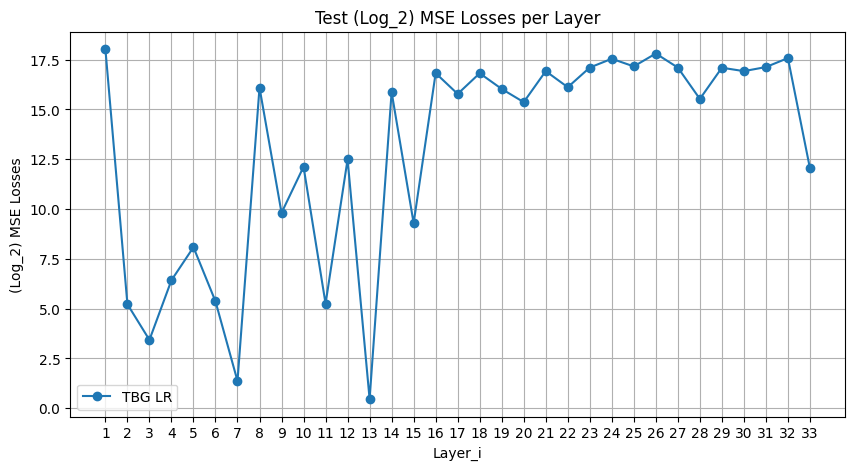

In [331]:
# Plot the 1-D pooled test losses
from datetime import datetime

def plot_1d_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name} per Layer')
    plt.xlabel('Layer_i')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices)  # Assuming all models have the same number of layers
    plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/test_{metric_name}_per_layer_for_{"_".join(model_names)}_{formatted_time}.jpg')
    plt.show()

plot_1d_metrics([lr_test_losses], ['TBG LR'], metric_name="(Log_2) MSE Losses", use_logarithm=True)

Training on Dataset 1/33
Epoch 1/50, Training Loss: 1.2584, Validation Loss: 0.9071
Epoch 10/50, Training Loss: 0.6096, Validation Loss: 0.9048
Epoch 20/50, Training Loss: 0.5330, Validation Loss: 0.8824
Epoch 30/50, Training Loss: 0.5209, Validation Loss: 0.9111
Epoch 40/50, Training Loss: 0.5114, Validation Loss: 0.9448
Epoch 50/50, Training Loss: 0.5246, Validation Loss: 0.9439


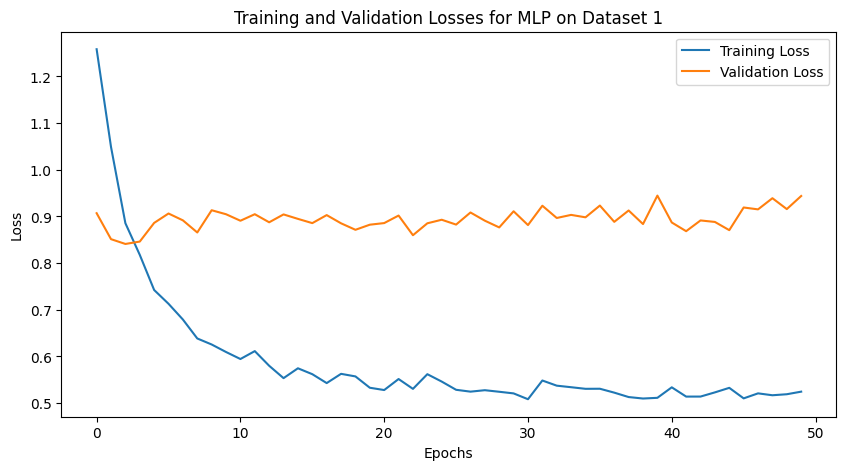

Test Loss: 1.1077
Training on Dataset 2/33
Epoch 1/50, Training Loss: 1.2191, Validation Loss: 0.7764
Epoch 10/50, Training Loss: 0.5712, Validation Loss: 0.8337
Epoch 20/50, Training Loss: 0.4862, Validation Loss: 0.8743
Epoch 30/50, Training Loss: 0.4708, Validation Loss: 0.8828
Epoch 40/50, Training Loss: 0.4483, Validation Loss: 0.8635
Epoch 50/50, Training Loss: 0.4417, Validation Loss: 0.8747


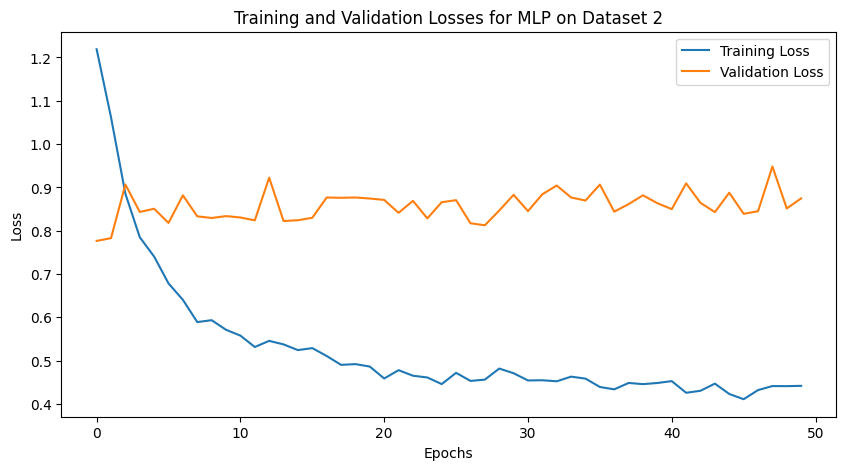

Test Loss: 0.8838
Training on Dataset 3/33
Epoch 1/50, Training Loss: 1.1539, Validation Loss: 0.9518
Epoch 10/50, Training Loss: 0.5712, Validation Loss: 0.8567
Epoch 20/50, Training Loss: 0.5022, Validation Loss: 0.8750
Epoch 30/50, Training Loss: 0.4657, Validation Loss: 0.8467
Epoch 40/50, Training Loss: 0.4342, Validation Loss: 0.8802
Epoch 50/50, Training Loss: 0.4507, Validation Loss: 0.8528


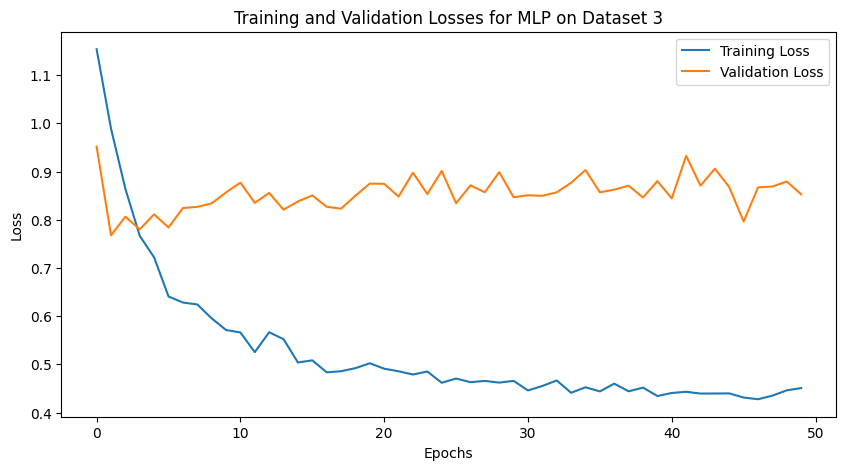

Test Loss: 0.8375
Training on Dataset 4/33
Epoch 1/50, Training Loss: 1.2244, Validation Loss: 0.7332
Epoch 10/50, Training Loss: 0.5512, Validation Loss: 0.8605
Epoch 20/50, Training Loss: 0.4715, Validation Loss: 0.9271
Epoch 30/50, Training Loss: 0.4618, Validation Loss: 0.8569
Epoch 40/50, Training Loss: 0.4394, Validation Loss: 0.8982
Epoch 50/50, Training Loss: 0.4539, Validation Loss: 0.8982


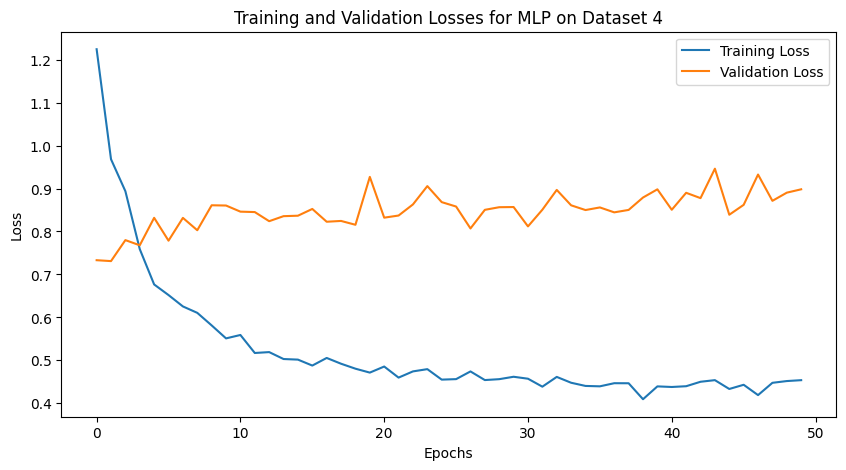

Test Loss: 0.8141
Training on Dataset 5/33
Epoch 1/50, Training Loss: 1.1126, Validation Loss: 0.8463
Epoch 10/50, Training Loss: 0.5255, Validation Loss: 0.8256
Epoch 20/50, Training Loss: 0.4474, Validation Loss: 0.8437
Epoch 30/50, Training Loss: 0.4468, Validation Loss: 0.8132
Epoch 40/50, Training Loss: 0.4199, Validation Loss: 0.8461
Epoch 50/50, Training Loss: 0.3881, Validation Loss: 0.8695


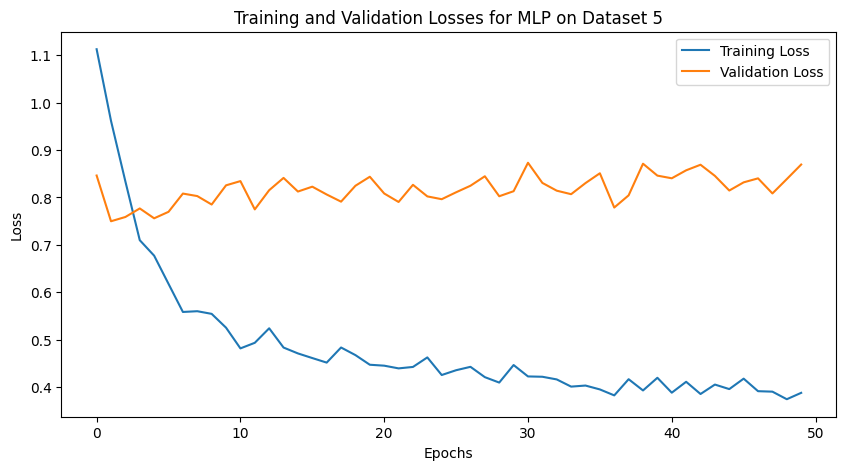

Test Loss: 0.9192
Training on Dataset 6/33
Epoch 1/50, Training Loss: 1.2164, Validation Loss: 0.8215
Epoch 10/50, Training Loss: 0.5348, Validation Loss: 0.7948
Epoch 20/50, Training Loss: 0.4538, Validation Loss: 0.8936
Epoch 30/50, Training Loss: 0.4148, Validation Loss: 0.7989
Epoch 40/50, Training Loss: 0.3757, Validation Loss: 0.7831
Epoch 50/50, Training Loss: 0.3573, Validation Loss: 0.8071


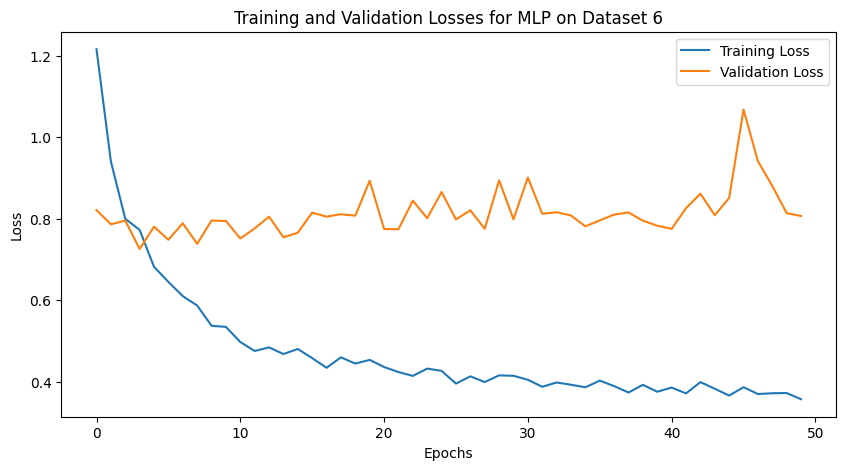

Test Loss: 0.8542
Training on Dataset 7/33
Epoch 1/50, Training Loss: 1.1812, Validation Loss: 0.8210
Epoch 10/50, Training Loss: 0.5019, Validation Loss: 0.7976
Epoch 20/50, Training Loss: 0.4061, Validation Loss: 0.8261
Epoch 30/50, Training Loss: 0.3784, Validation Loss: 0.8795
Epoch 40/50, Training Loss: 0.3486, Validation Loss: 0.7622
Epoch 50/50, Training Loss: 0.3429, Validation Loss: 0.7988


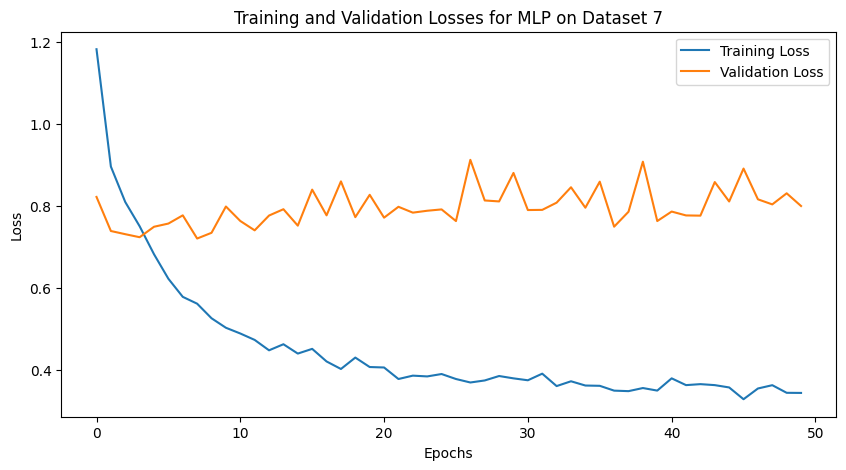

Test Loss: 0.8940
Training on Dataset 8/33
Epoch 1/50, Training Loss: 1.1640, Validation Loss: 1.1199
Epoch 10/50, Training Loss: 0.4373, Validation Loss: 0.7314
Epoch 20/50, Training Loss: 0.3512, Validation Loss: 0.7583
Epoch 30/50, Training Loss: 0.3077, Validation Loss: 0.7465
Epoch 40/50, Training Loss: 0.2763, Validation Loss: 0.7901
Epoch 50/50, Training Loss: 0.2577, Validation Loss: 0.8235


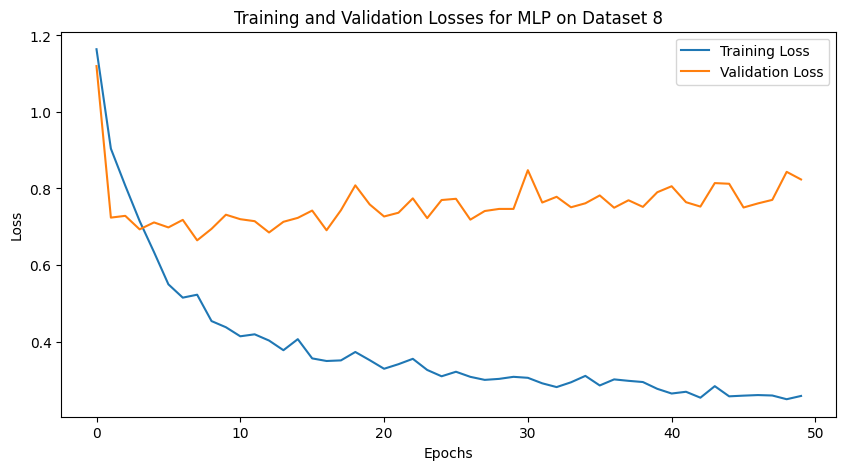

Test Loss: 0.7930
Training on Dataset 9/33
Epoch 1/50, Training Loss: 1.2320, Validation Loss: 0.7214
Epoch 10/50, Training Loss: 0.4305, Validation Loss: 0.7073
Epoch 20/50, Training Loss: 0.3162, Validation Loss: 0.7619
Epoch 30/50, Training Loss: 0.2682, Validation Loss: 0.7632
Epoch 40/50, Training Loss: 0.2700, Validation Loss: 0.7208
Epoch 50/50, Training Loss: 0.1940, Validation Loss: 0.7950


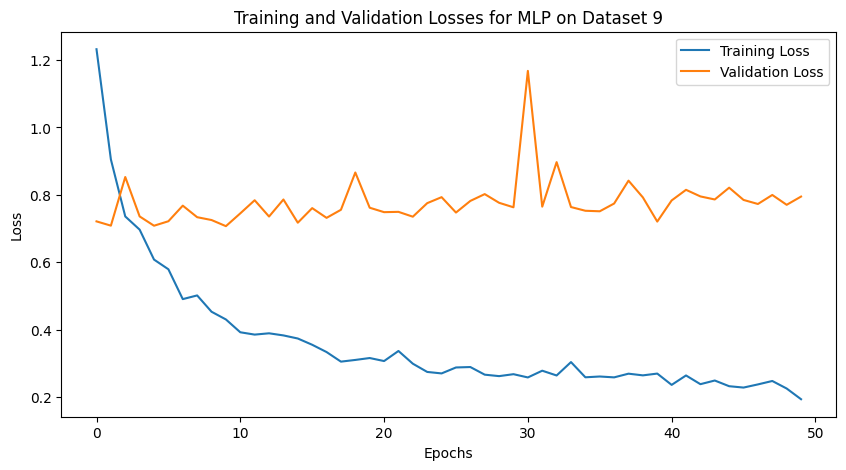

Test Loss: 0.7806
Training on Dataset 10/33
Epoch 1/50, Training Loss: 1.1319, Validation Loss: 0.7339
Epoch 10/50, Training Loss: 0.4021, Validation Loss: 0.7676
Epoch 20/50, Training Loss: 0.2901, Validation Loss: 0.8239
Epoch 30/50, Training Loss: 0.2388, Validation Loss: 0.7634
Epoch 40/50, Training Loss: 0.2196, Validation Loss: 0.8554
Epoch 50/50, Training Loss: 0.1709, Validation Loss: 0.7889


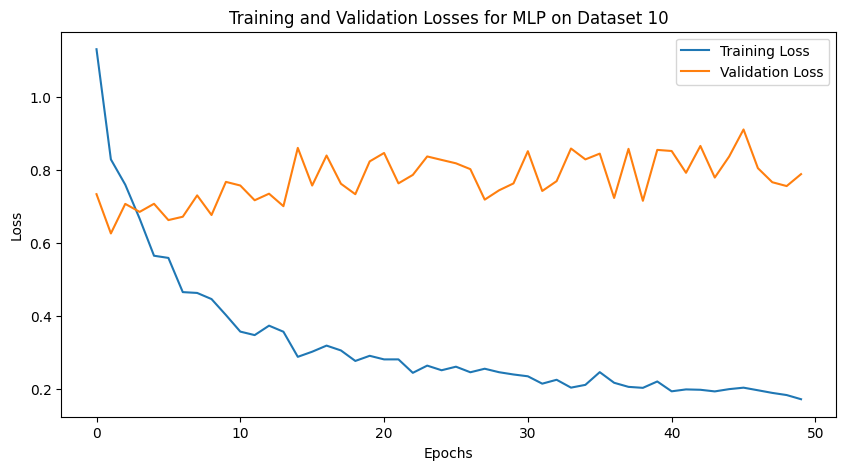

Test Loss: 0.7665
Training on Dataset 11/33
Epoch 1/50, Training Loss: 1.1708, Validation Loss: 0.6719
Epoch 10/50, Training Loss: 0.3731, Validation Loss: 0.6856
Epoch 20/50, Training Loss: 0.2504, Validation Loss: 0.7345
Epoch 30/50, Training Loss: 0.1962, Validation Loss: 0.7095
Epoch 40/50, Training Loss: 0.2114, Validation Loss: 0.8089
Epoch 50/50, Training Loss: 0.1874, Validation Loss: 0.7864


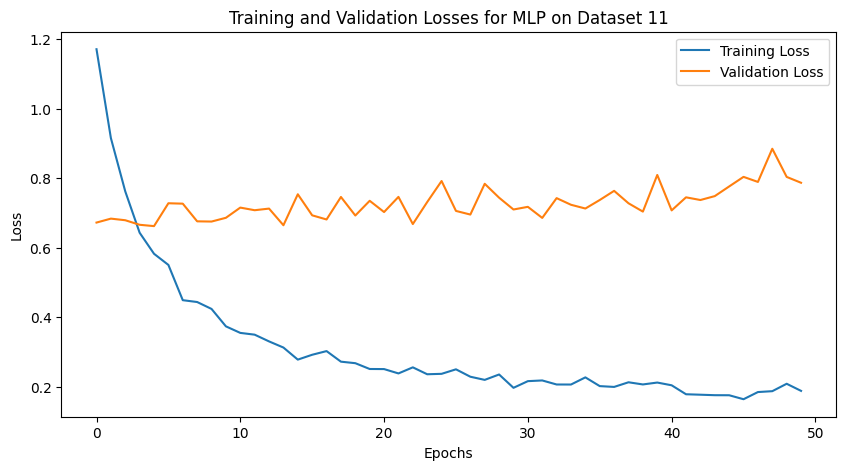

Test Loss: 0.7745
Training on Dataset 12/33
Epoch 1/50, Training Loss: 1.1965, Validation Loss: 0.6594
Epoch 10/50, Training Loss: 0.3237, Validation Loss: 0.6915
Epoch 20/50, Training Loss: 0.2160, Validation Loss: 0.7099
Epoch 30/50, Training Loss: 0.1892, Validation Loss: 0.8153
Epoch 40/50, Training Loss: 0.1539, Validation Loss: 0.7493
Epoch 50/50, Training Loss: 0.1464, Validation Loss: 0.7641


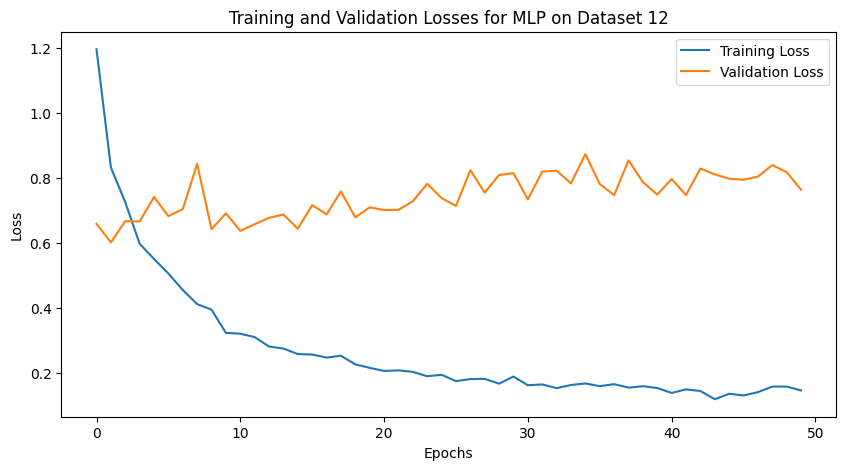

Test Loss: 0.7609
Training on Dataset 13/33
Epoch 1/50, Training Loss: 1.0925, Validation Loss: 0.6407
Epoch 10/50, Training Loss: 0.3228, Validation Loss: 0.6803
Epoch 20/50, Training Loss: 0.1887, Validation Loss: 0.7463
Epoch 30/50, Training Loss: 0.1467, Validation Loss: 0.6978
Epoch 40/50, Training Loss: 0.1287, Validation Loss: 0.6750
Epoch 50/50, Training Loss: 0.1349, Validation Loss: 0.7684


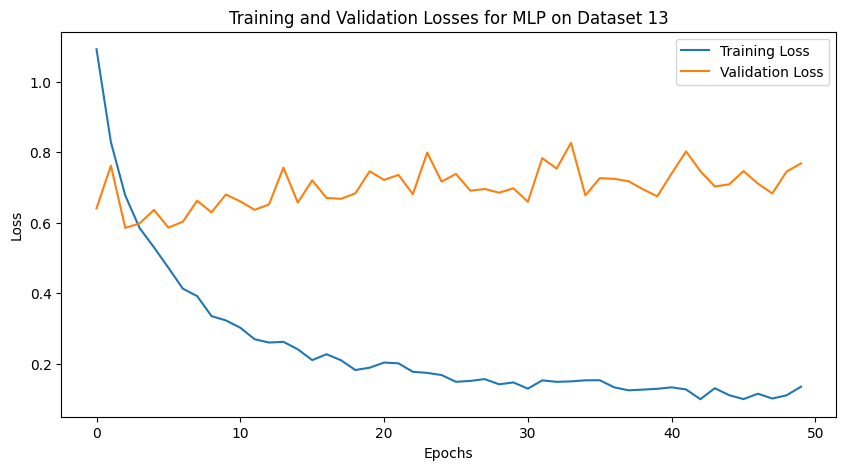

Test Loss: 0.6694
Training on Dataset 14/33
Epoch 1/50, Training Loss: 1.0412, Validation Loss: 0.7704
Epoch 10/50, Training Loss: 0.2832, Validation Loss: 0.6656
Epoch 20/50, Training Loss: 0.1567, Validation Loss: 0.7176
Epoch 30/50, Training Loss: 0.1256, Validation Loss: 0.7070
Epoch 40/50, Training Loss: 0.1004, Validation Loss: 0.7032
Epoch 50/50, Training Loss: 0.0905, Validation Loss: 0.6982


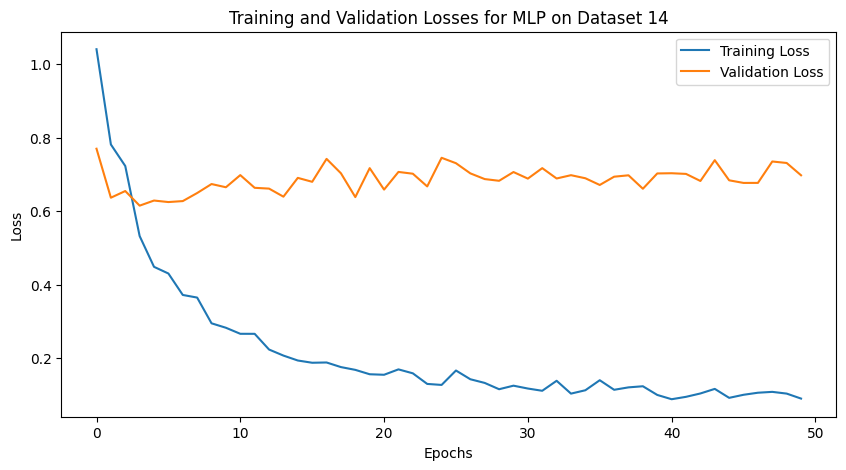

Test Loss: 0.5945
Training on Dataset 15/33
Epoch 1/50, Training Loss: 1.0417, Validation Loss: 0.6135
Epoch 10/50, Training Loss: 0.2234, Validation Loss: 0.6590
Epoch 20/50, Training Loss: 0.1284, Validation Loss: 0.6723
Epoch 30/50, Training Loss: 0.0991, Validation Loss: 0.6335
Epoch 40/50, Training Loss: 0.0943, Validation Loss: 0.6646
Epoch 50/50, Training Loss: 0.0868, Validation Loss: 0.6372


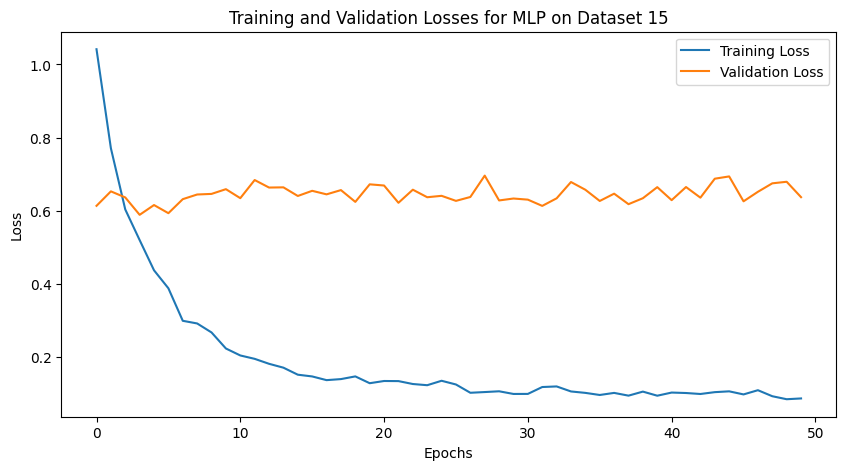

Test Loss: 0.5853
Training on Dataset 16/33
Epoch 1/50, Training Loss: 1.0844, Validation Loss: 0.5720
Epoch 10/50, Training Loss: 0.2088, Validation Loss: 0.6510
Epoch 20/50, Training Loss: 0.1343, Validation Loss: 0.6453
Epoch 30/50, Training Loss: 0.0999, Validation Loss: 0.6742
Epoch 40/50, Training Loss: 0.0940, Validation Loss: 0.6793
Epoch 50/50, Training Loss: 0.0910, Validation Loss: 0.6226


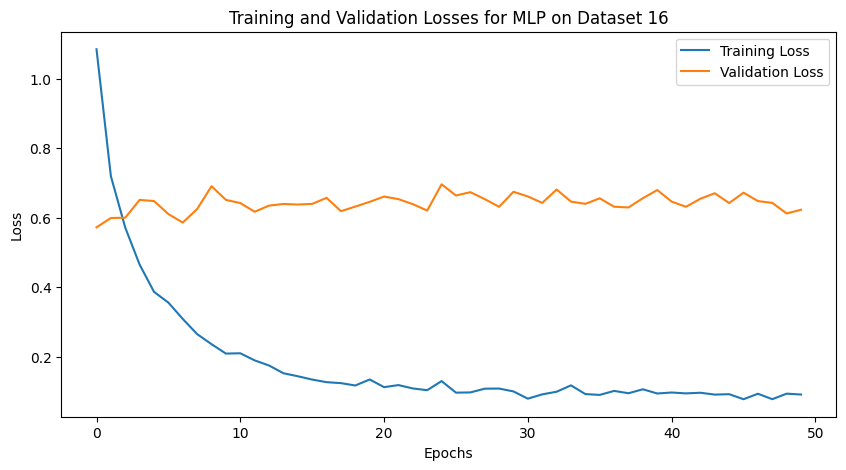

Test Loss: 0.5570
Training on Dataset 17/33
Epoch 1/50, Training Loss: 1.0415, Validation Loss: 0.5822
Epoch 10/50, Training Loss: 0.2101, Validation Loss: 0.6150
Epoch 20/50, Training Loss: 0.1058, Validation Loss: 0.6536
Epoch 30/50, Training Loss: 0.0975, Validation Loss: 0.6416
Epoch 40/50, Training Loss: 0.0862, Validation Loss: 0.6913
Epoch 50/50, Training Loss: 0.0993, Validation Loss: 0.6433


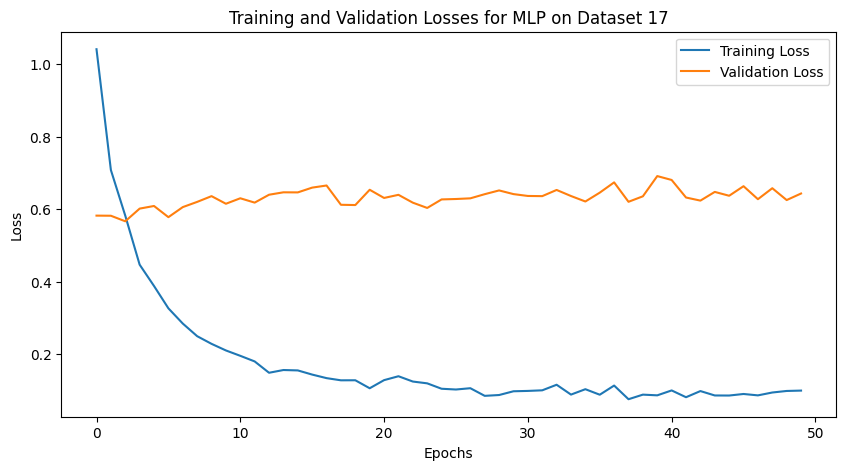

Test Loss: 0.4953
Training on Dataset 18/33
Epoch 1/50, Training Loss: 1.0257, Validation Loss: 0.6676
Epoch 10/50, Training Loss: 0.1930, Validation Loss: 0.6173
Epoch 20/50, Training Loss: 0.1229, Validation Loss: 0.6121
Epoch 30/50, Training Loss: 0.0938, Validation Loss: 0.6329
Epoch 40/50, Training Loss: 0.0898, Validation Loss: 0.6248
Epoch 50/50, Training Loss: 0.0854, Validation Loss: 0.6487


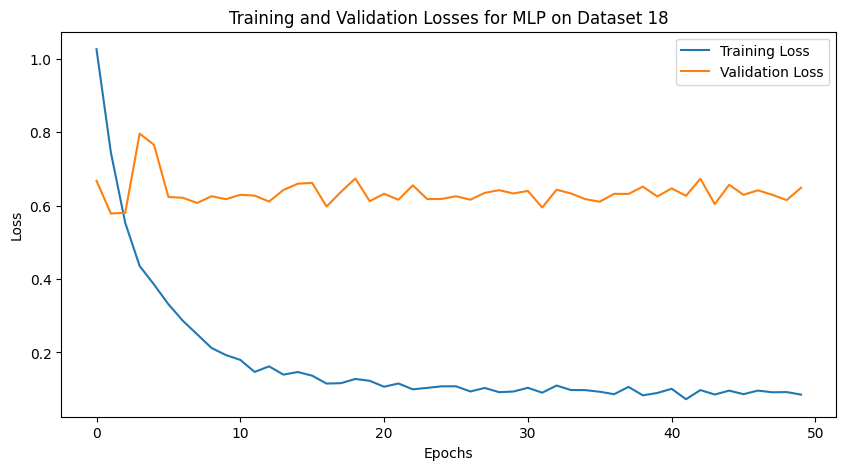

Test Loss: 0.4835
Training on Dataset 19/33
Epoch 1/50, Training Loss: 1.0141, Validation Loss: 0.6032
Epoch 10/50, Training Loss: 0.2005, Validation Loss: 0.5908
Epoch 20/50, Training Loss: 0.1046, Validation Loss: 0.5789
Epoch 30/50, Training Loss: 0.0898, Validation Loss: 0.6240
Epoch 40/50, Training Loss: 0.0866, Validation Loss: 0.5917
Epoch 50/50, Training Loss: 0.0914, Validation Loss: 0.5818


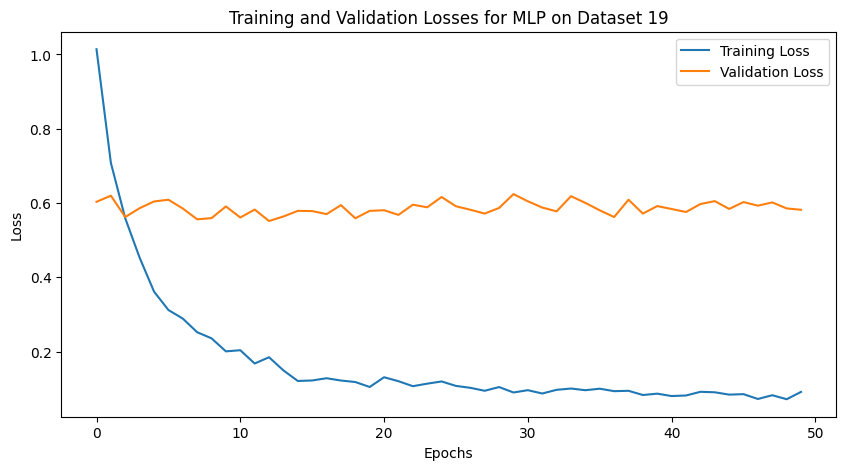

Test Loss: 0.5127
Training on Dataset 20/33
Epoch 1/50, Training Loss: 0.9851, Validation Loss: 0.7274
Epoch 10/50, Training Loss: 0.1773, Validation Loss: 0.5422
Epoch 20/50, Training Loss: 0.1037, Validation Loss: 0.5516
Epoch 30/50, Training Loss: 0.1015, Validation Loss: 0.5679
Epoch 40/50, Training Loss: 0.0878, Validation Loss: 0.5790
Epoch 50/50, Training Loss: 0.1009, Validation Loss: 0.5788


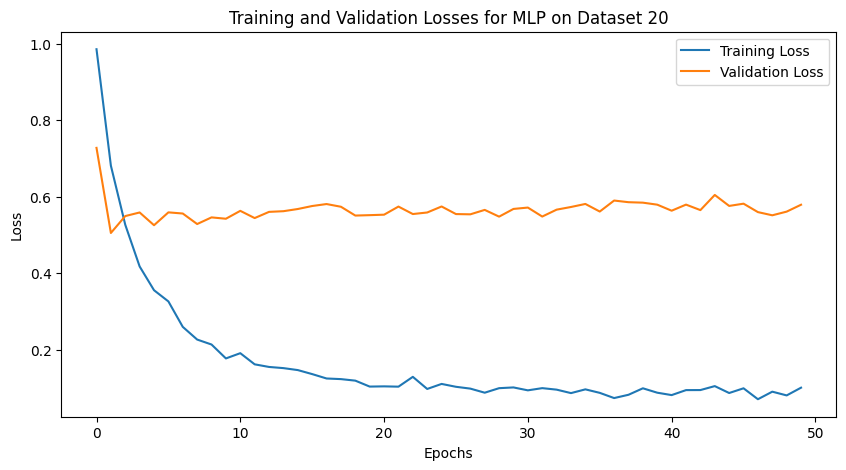

Test Loss: 0.5023
Training on Dataset 21/33
Epoch 1/50, Training Loss: 0.9764, Validation Loss: 0.7744
Epoch 10/50, Training Loss: 0.1643, Validation Loss: 0.5873
Epoch 20/50, Training Loss: 0.1175, Validation Loss: 0.5901
Epoch 30/50, Training Loss: 0.1194, Validation Loss: 0.5815
Epoch 40/50, Training Loss: 0.0911, Validation Loss: 0.5948
Epoch 50/50, Training Loss: 0.0765, Validation Loss: 0.5763


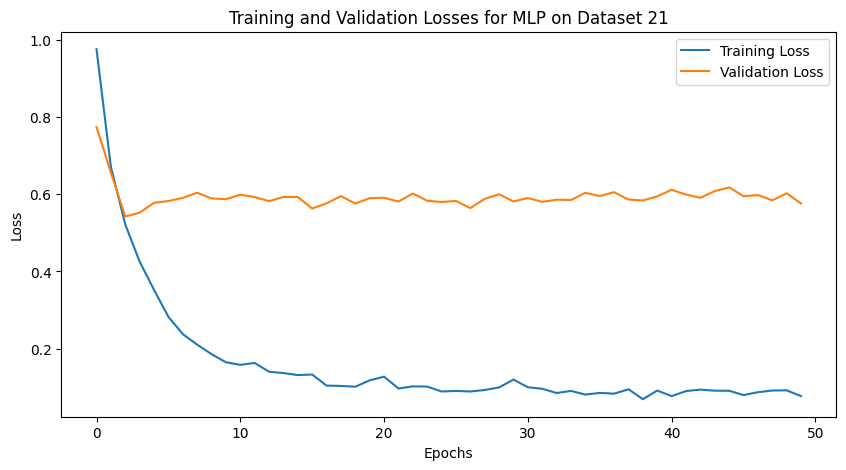

Test Loss: 0.5386
Training on Dataset 22/33
Epoch 1/50, Training Loss: 1.0495, Validation Loss: 0.7674
Epoch 10/50, Training Loss: 0.1786, Validation Loss: 0.5887
Epoch 20/50, Training Loss: 0.1141, Validation Loss: 0.5963
Epoch 30/50, Training Loss: 0.0987, Validation Loss: 0.5942
Epoch 40/50, Training Loss: 0.0966, Validation Loss: 0.5900
Epoch 50/50, Training Loss: 0.0867, Validation Loss: 0.5756


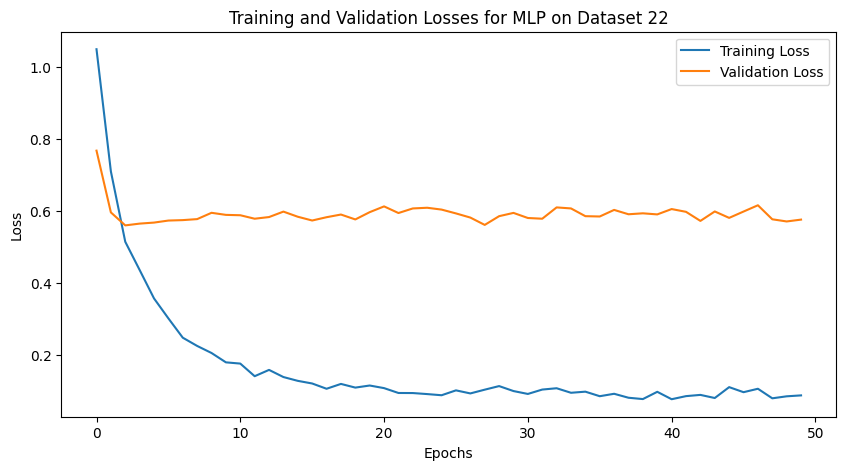

Test Loss: 0.5406
Training on Dataset 23/33
Epoch 1/50, Training Loss: 1.0212, Validation Loss: 0.6192
Epoch 10/50, Training Loss: 0.1652, Validation Loss: 0.5850
Epoch 20/50, Training Loss: 0.1047, Validation Loss: 0.5755
Epoch 30/50, Training Loss: 0.0999, Validation Loss: 0.5709
Epoch 40/50, Training Loss: 0.0847, Validation Loss: 0.5948
Epoch 50/50, Training Loss: 0.0900, Validation Loss: 0.5756


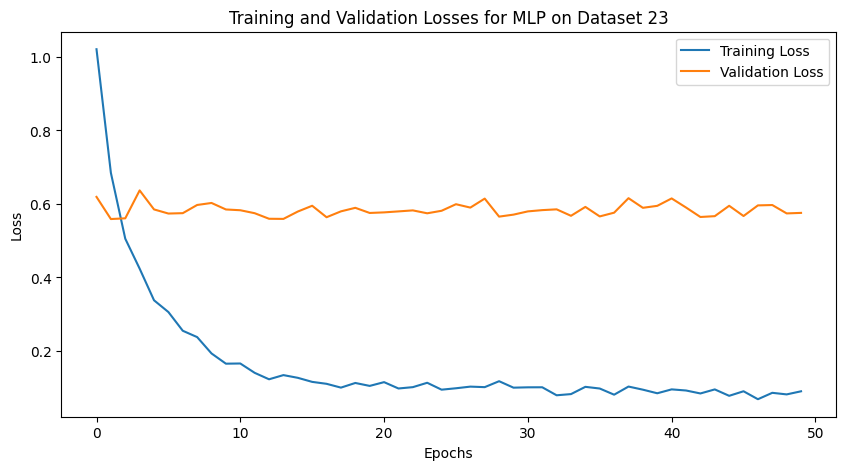

Test Loss: 0.5458
Training on Dataset 24/33
Epoch 1/50, Training Loss: 1.0093, Validation Loss: 0.6841
Epoch 10/50, Training Loss: 0.1721, Validation Loss: 0.5813
Epoch 20/50, Training Loss: 0.0999, Validation Loss: 0.5577
Epoch 30/50, Training Loss: 0.0923, Validation Loss: 0.5598
Epoch 40/50, Training Loss: 0.0885, Validation Loss: 0.5785
Epoch 50/50, Training Loss: 0.0784, Validation Loss: 0.5590


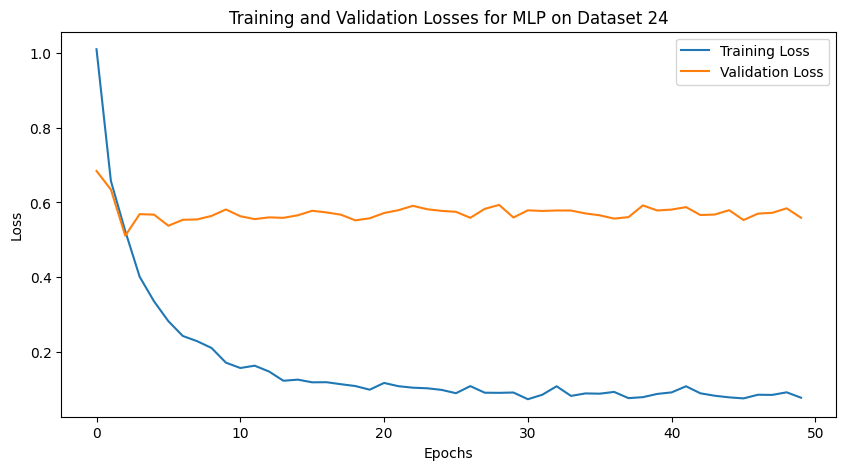

Test Loss: 0.5565
Training on Dataset 25/33
Epoch 1/50, Training Loss: 1.0169, Validation Loss: 0.6276
Epoch 10/50, Training Loss: 0.1868, Validation Loss: 0.5620
Epoch 20/50, Training Loss: 0.0991, Validation Loss: 0.5480
Epoch 30/50, Training Loss: 0.0784, Validation Loss: 0.5619
Epoch 40/50, Training Loss: 0.0861, Validation Loss: 0.5669
Epoch 50/50, Training Loss: 0.0729, Validation Loss: 0.5644


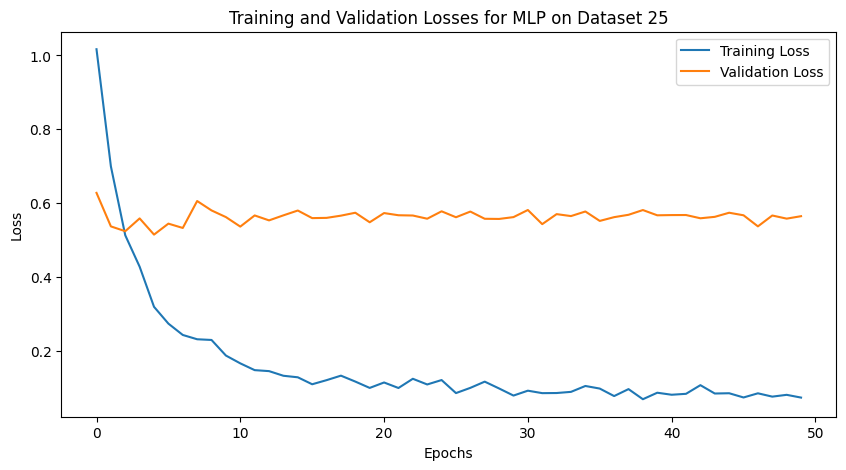

Test Loss: 0.5613
Training on Dataset 26/33
Epoch 1/50, Training Loss: 1.0290, Validation Loss: 0.6683
Epoch 10/50, Training Loss: 0.1788, Validation Loss: 0.5518
Epoch 20/50, Training Loss: 0.0991, Validation Loss: 0.5720
Epoch 30/50, Training Loss: 0.1115, Validation Loss: 0.5544
Epoch 40/50, Training Loss: 0.0859, Validation Loss: 0.5851
Epoch 50/50, Training Loss: 0.0716, Validation Loss: 0.5673


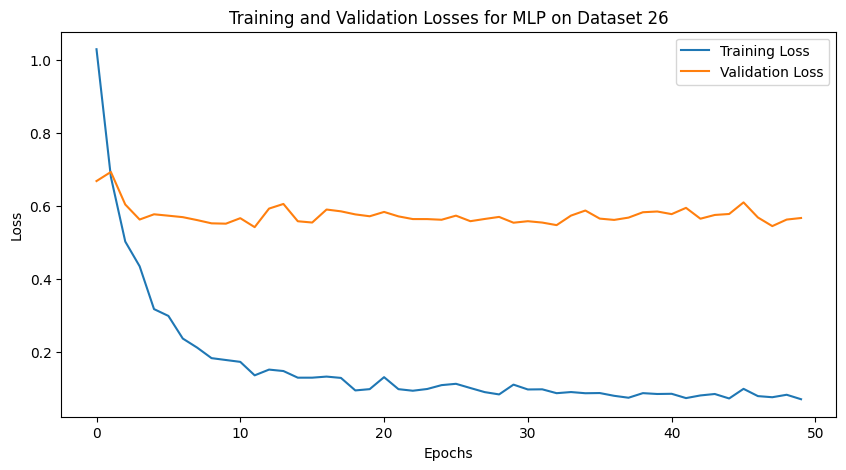

Test Loss: 0.5766
Training on Dataset 27/33
Epoch 1/50, Training Loss: 1.0079, Validation Loss: 0.6578
Epoch 10/50, Training Loss: 0.1537, Validation Loss: 0.5306
Epoch 20/50, Training Loss: 0.0992, Validation Loss: 0.5460
Epoch 30/50, Training Loss: 0.0913, Validation Loss: 0.5401
Epoch 40/50, Training Loss: 0.0858, Validation Loss: 0.5536
Epoch 50/50, Training Loss: 0.0920, Validation Loss: 0.5930


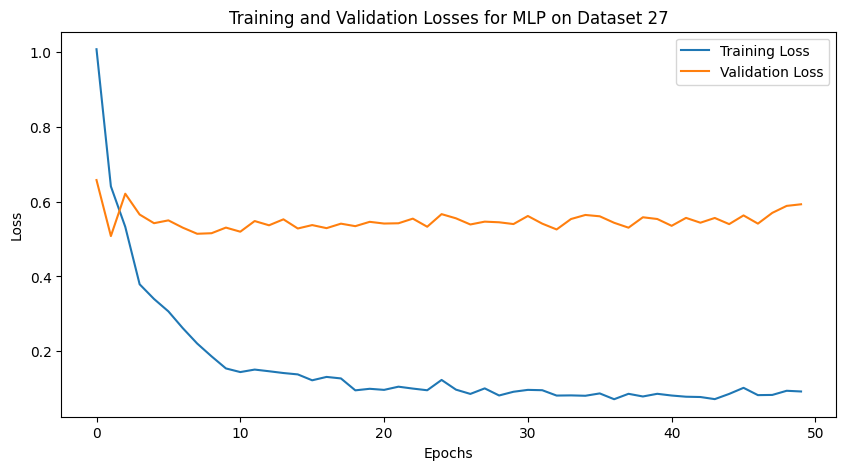

Test Loss: 0.6151
Training on Dataset 28/33
Epoch 1/50, Training Loss: 1.0146, Validation Loss: 0.6451
Epoch 10/50, Training Loss: 0.1563, Validation Loss: 0.5370
Epoch 20/50, Training Loss: 0.1044, Validation Loss: 0.5395
Epoch 30/50, Training Loss: 0.1183, Validation Loss: 0.5440
Epoch 40/50, Training Loss: 0.0869, Validation Loss: 0.5536
Epoch 50/50, Training Loss: 0.0747, Validation Loss: 0.5580


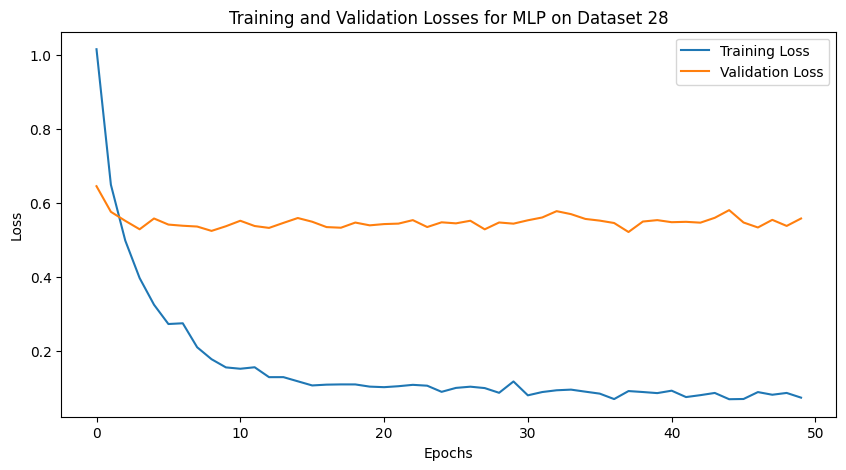

Test Loss: 0.6257
Training on Dataset 29/33
Epoch 1/50, Training Loss: 0.9856, Validation Loss: 0.6719
Epoch 10/50, Training Loss: 0.1771, Validation Loss: 0.5731
Epoch 20/50, Training Loss: 0.1003, Validation Loss: 0.5582
Epoch 30/50, Training Loss: 0.0821, Validation Loss: 0.5664
Epoch 40/50, Training Loss: 0.0805, Validation Loss: 0.5729
Epoch 50/50, Training Loss: 0.0919, Validation Loss: 0.5601


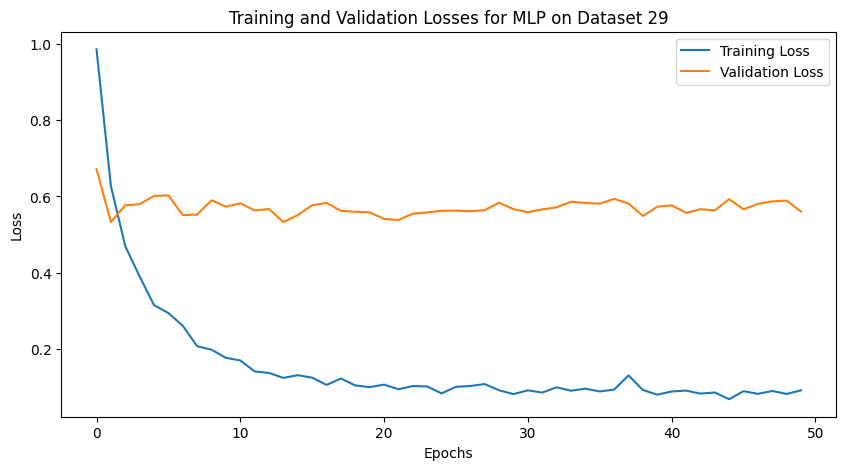

Test Loss: 0.6779
Training on Dataset 30/33
Epoch 1/50, Training Loss: 1.0082, Validation Loss: 0.5534
Epoch 10/50, Training Loss: 0.1756, Validation Loss: 0.5744
Epoch 20/50, Training Loss: 0.1005, Validation Loss: 0.5583
Epoch 30/50, Training Loss: 0.1032, Validation Loss: 0.5770
Epoch 40/50, Training Loss: 0.0896, Validation Loss: 0.5743
Epoch 50/50, Training Loss: 0.0754, Validation Loss: 0.5773


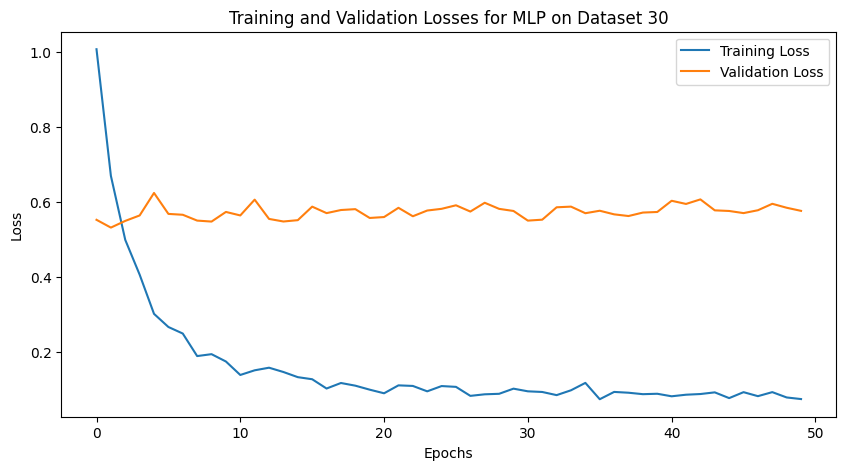

Test Loss: 0.6749
Training on Dataset 31/33
Epoch 1/50, Training Loss: 1.0554, Validation Loss: 0.7965
Epoch 10/50, Training Loss: 0.1807, Validation Loss: 0.5679
Epoch 20/50, Training Loss: 0.1141, Validation Loss: 0.5605
Epoch 30/50, Training Loss: 0.0992, Validation Loss: 0.5644
Epoch 40/50, Training Loss: 0.0822, Validation Loss: 0.5840
Epoch 50/50, Training Loss: 0.0832, Validation Loss: 0.5445


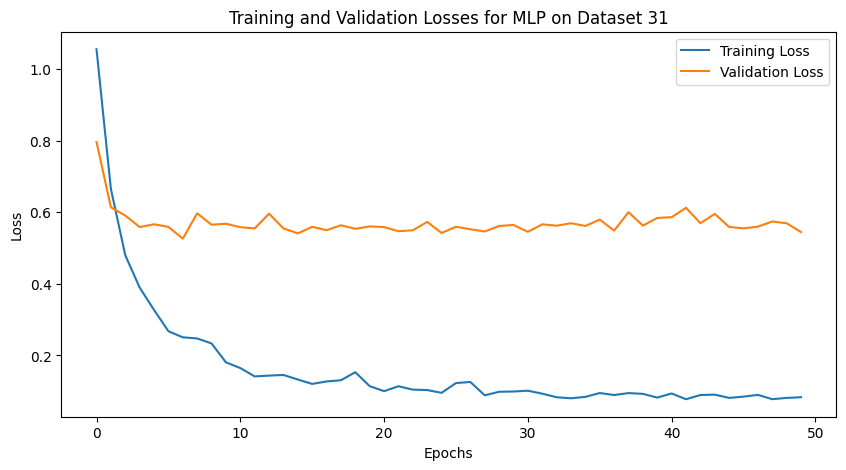

Test Loss: 0.6764
Training on Dataset 32/33
Epoch 1/50, Training Loss: 0.9892, Validation Loss: 0.6537
Epoch 10/50, Training Loss: 0.1647, Validation Loss: 0.5382
Epoch 20/50, Training Loss: 0.1182, Validation Loss: 0.5547
Epoch 30/50, Training Loss: 0.0997, Validation Loss: 0.5514
Epoch 40/50, Training Loss: 0.0705, Validation Loss: 0.5520
Epoch 50/50, Training Loss: 0.0799, Validation Loss: 0.5656


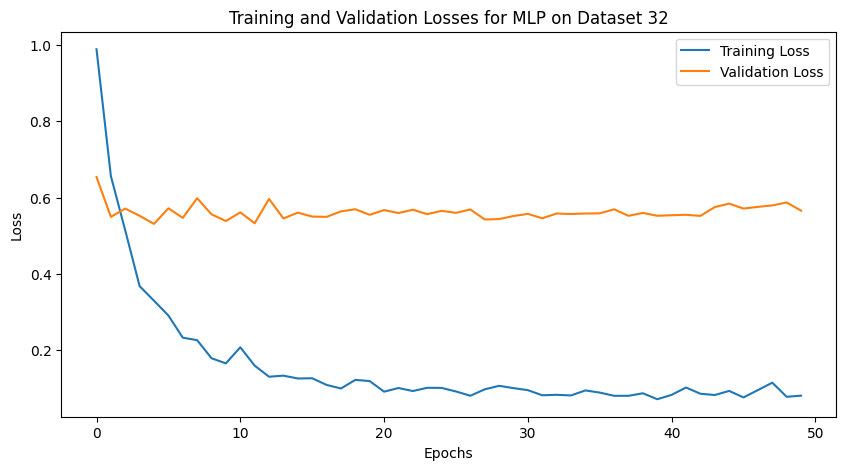

Test Loss: 0.7315
Training on Dataset 33/33
Epoch 1/50, Training Loss: 1.0222, Validation Loss: 0.7952
Epoch 10/50, Training Loss: 0.1681, Validation Loss: 0.6050
Epoch 20/50, Training Loss: 0.1122, Validation Loss: 0.5813
Epoch 30/50, Training Loss: 0.1116, Validation Loss: 0.6181
Epoch 40/50, Training Loss: 0.0784, Validation Loss: 0.6006
Epoch 50/50, Training Loss: 0.0733, Validation Loss: 0.6149


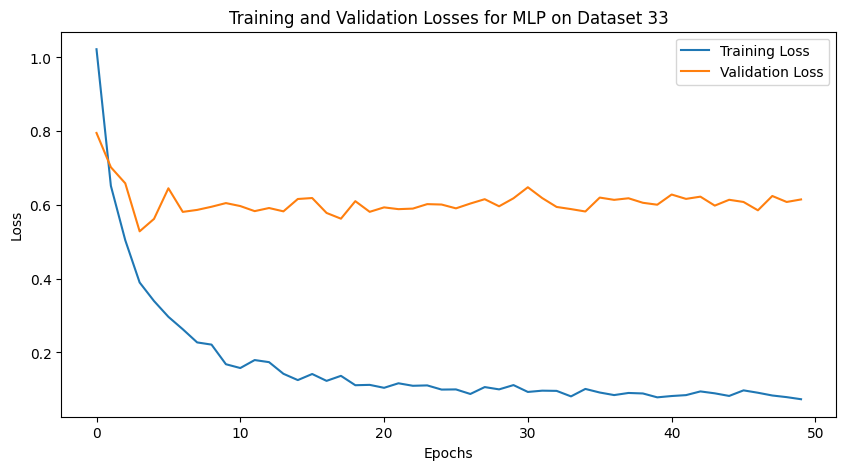

Test Loss: 0.7494


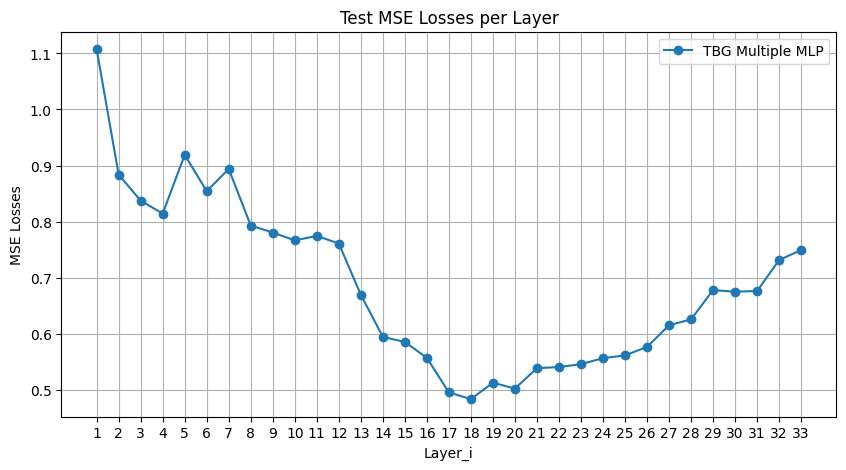

In [332]:
# Training Loops: MLP for each layer.
in_dim = 4544   # Token embedding dimensions (e.g. Llama-2-7B)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50
mlp_test_losses = []

for i, (train_loader, valid_loader, test_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders)):
    model = MLP(in_dim, hid_dims, out_dim, dropout) 
    print(f"Training on Dataset {i+1}/{len(tbg_train_dataloaders)}")
    train_and_evaluate(model, train_loader, valid_loader, device, epochs=epochs, title=f"MLP on Dataset {i+1}")
    test_loss = evaluate_on_test(model, test_loader, device)
    mlp_test_losses.append(test_loss)

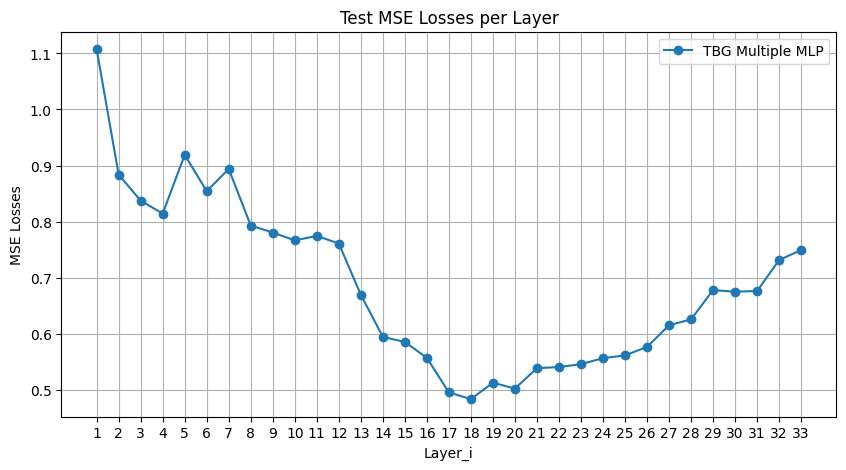

In [404]:
plot_1d_metrics([mlp_test_losses], ['TBG Multiple MLP'], 'MSE Losses')

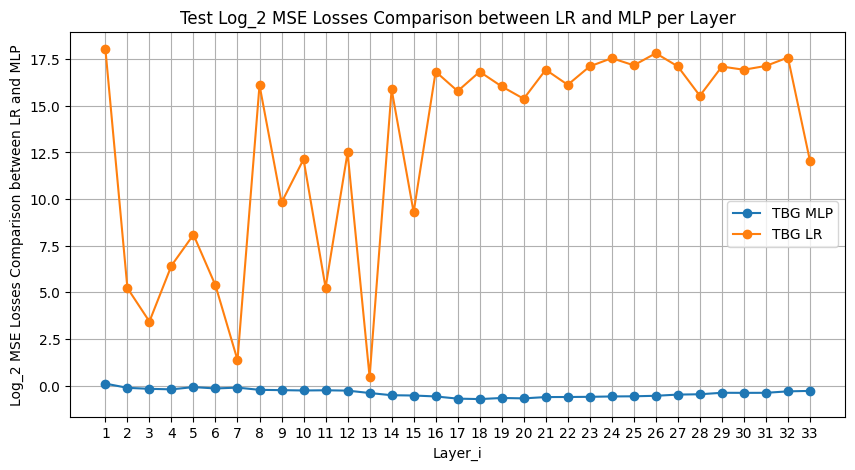

In [333]:
# Plot metrics (comparison between MLP and LR trained layer by layer, on pooled test set)
plot_1d_metrics([mlp_test_losses, lr_test_losses], ['TBG MLP', 'TBG LR'], "Log_2 MSE Losses Comparison between LR and MLP", use_logarithm=True)

#### Binarize Entropy and Predict with Logistic Regression

We try binarizing the entropy scores and use logistic regression as with the accuracy prediction.

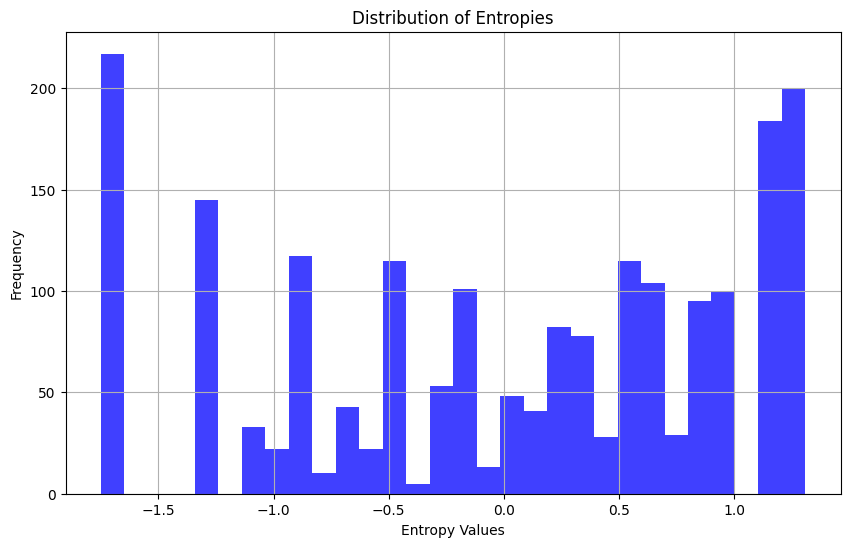

tensor(-1.7497) tensor(1.3102) tensor(1.0000) tensor(-1.3280e-07)


In [520]:
# Plot the entropy distribution
def plot_entropy_distribution(entropies):
    entropies_np = entropies.numpy()
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(entropies_np, bins=30, alpha=0.75, color='blue')
    plt.title('Distribution of Entropies')  # Title of the histogram
    plt.xlabel('Entropy Values')  # Label for the x-axis
    plt.ylabel('Frequency')  # Label for the y-axis
    plt.grid(True) 
    plt.show()

plot_entropy_distribution(ca_entropy)
print(ca_entropy.min(), ca_entropy.max(), ca_entropy.var(), ca_entropy.mean())

def binarize_entropy(entropies, thres=0.0):
    binary_entropies = torch.full_like(entropies, -1, dtype=torch.float)
    binary_entropies[entropies < thres] = 0
    binary_entropies[entropies > thres] = 1

    return binary_entropies

bca_entropy = binarize_entropy(ca_entropy, 0.0)

We observe bimodal distribution for the normalized entropy values. The distribution is slightly skewed. **We decide to bin at 0.0 for even splits for now.**

In [521]:
# Fractions of 1's for binarized entropy: ~55%
print(sum(bca_entropy)/len(bca_entropy))

tensor(0.5505)


In [522]:
# Train logistic regression model for binarized entropy (we will use sklearn logistic regression)
from sklearn.linear_model import LogisticRegression
class MLPClassifier(MLP):
    def __init__(self, in_dim, hid_dims, dropout):
        super().__init__(in_dim, hid_dims, out_dim=1, dropout=dropout)

    def forward(self, x):
        x = super().forward(x)
        x = torch.sigmoid(x) 
        return x

# Prepare new dataloaders for binarized case (NOTE: naming conflict)
tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders = create_dataloaders(tok_bef_gen_layered_datasets, bca_entropy, total_size, batch_size)
# Prepare new X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)

In [523]:
# Training with LogisticRegression.
tblr_test_accs = []
tblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tblr_test_accs.append(test_acc)
    tblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.5778, AUROC: 0.6430
Training Loss: 0.4256, Validation Loss: 0.6639
Test Loss: 0.6310, Test Accuracy: 0.6700, AUROC: 0.7161
Training on Dataset 2/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6472, AUROC: 0.6899
Training Loss: 0.2395, Validation Loss: 0.9775
Test Loss: 0.8292, Test Accuracy: 0.6900, AUROC: 0.7718
Training on Dataset 3/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6194, AUROC: 0.6821
Training Loss: 0.2172, Validation Loss: 1.0246
Test Loss: 0.9740, Test Accuracy: 0.7200, AUROC: 0.7647
Training on Dataset 4/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7111, AUROC: 0.7879
Training Loss: 0.0053, Validation Loss: 1.4614
Test Loss: 1.2043, Test Accuracy: 0.7900, AUROC: 0.8484
Training on Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7139, AUROC: 0.7748
Training Loss: 0.0053, Validation Loss: 1.5716
Test Loss: 1.2181, Test Accuracy: 0.8000, AUROC: 0.8478
Training on Dataset 33/33
Validation Accuracy: 0.7222, AUROC: 0.7727
Training Loss: 0.0132, Validation Loss: 1.3148
Test Loss: 1.0022, Test Accuracy: 0.7600, AUROC: 0.8489


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Training with MLPs.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544 # for falcon
# in_dim = 4096 # for llama-2 
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50
tbmlp_test_accs = []
tbmlp_test_aucs = []

for i, (train_loader, valid_loader, test_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders)):
    print(f"Training on Dataset {i+1}/{len(tbg_train_dataloaders)}")
    model = MLPClassifier(in_dim, hid_dims, dropout)
    train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(model, test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tbmlp_test_accs.append(test_acc)
    tbmlp_test_aucs.append(test_auc)

plot_1d_metrics([tbmlp_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([tbmlp_test_aucs], ['MLP Classifier'], 'AUROC')

Using device: cuda
Training on Dataset 1/33
Epoch 1/50, Training Loss: 61.3214, Validation Loss: 56.1014, Training Accuracy: 0.5965
Epoch 10/50, Training Loss: 59.0147, Validation Loss: 56.0359, Training Accuracy: 0.7701
Epoch 20/50, Training Loss: 58.8475, Validation Loss: 56.0139, Training Accuracy: 0.7785
Epoch 30/50, Training Loss: 58.8647, Validation Loss: 56.1712, Training Accuracy: 0.7708
Epoch 40/50, Training Loss: 58.8474, Validation Loss: 56.3219, Training Accuracy: 0.7792
Epoch 50/50, Training Loss: 58.8415, Validation Loss: 56.1751, Training Accuracy: 0.7806
Test Loss: 50.0616, Test Accuracy: 0.5900, AUROC: 0.6413
Training on Dataset 2/33
Epoch 1/50, Training Loss: 61.1743, Validation Loss: 56.2415, Training Accuracy: 0.6188
Epoch 10/50, Training Loss: 58.9276, Validation Loss: 55.7854, Training Accuracy: 0.7931
Epoch 20/50, Training Loss: 58.8018, Validation Loss: 55.5979, Training Accuracy: 0.7937
Epoch 30/50, Training Loss: 58.5436, Validation Loss: 56.0762, Training Acc

In [ ]:
plot_1d_metrics([tbmlp_test_accs, tblr_test_accs], ['MLP Classifier','LR Classifier'], 'Accuracy')
plot_1d_metrics([tbmlp_test_aucs, tblr_test_aucs], ['MLP Classifier','LR Classifier'], 'AUROC')

### Explore Second Last generated Token (SLT)


In [427]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([2000, 33, 4544])


In [428]:
sec_last_tok_dataset.transpose(0, 1).shape

torch.Size([33, 2000, 4544])

In [429]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 2000, 4544]) torch.float32


In [430]:
# We may want to drop the first layer due to its homogeneity in values.
# print(slt_layered_datasets[0], slt_layered_datasets[0].shape)
slt_layered_datasets = slt_layered_datasets[1:]

In [431]:
# Inherit from previous section
# Make batched inputs and dataloaders (one for each layer)
total_size = 2000
batch_size = 32
slt_train_dataloaders, slt_valid_dataloaders, slt_test_dataloaders = create_dataloaders(slt_layered_datasets, ca_entropy, total_size, batch_size)
# Prepare X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, ca_entropy, total_size)

In [432]:
# Training Loops: single LR.
from sklearn.linear_model import LinearRegression

slr_test_losses = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LinearRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, title=f"LR on SLT Dataset {i+1}")
    test_loss = sklearn_evaluate_on_test(model, X_test, y_test)
    slr_test_losses.append(test_loss)

Training on SLT Dataset 1/32
Training Loss: 0.0087, Validation Loss: 3.1271
Test Loss: 2.3167, Test R-squared: -1.1495
Training on SLT Dataset 2/32
Training Loss: 0.0087, Validation Loss: 145.9601
Test Loss: 121.7121, Test R-squared: -111.9303
Training on SLT Dataset 3/32
Training Loss: 0.1009, Validation Loss: 437910.1250
Test Loss: 362631.9062, Test R-squared: -336466.4894
Training on SLT Dataset 4/32
Training Loss: 0.0087, Validation Loss: 57.6728
Test Loss: 49.6402, Test R-squared: -45.0586
Training on SLT Dataset 5/32
Training Loss: 0.0088, Validation Loss: 1232.9620
Test Loss: 1053.9761, Test R-squared: -976.9302
Training on SLT Dataset 6/32
Training Loss: 0.0198, Validation Loss: 91189.3438
Test Loss: 104482.5781, Test R-squared: -96943.0003
Training on SLT Dataset 7/32
Training Loss: 0.0206, Validation Loss: 98981.1641
Test Loss: 95990.9375, Test R-squared: -89064.0499
Training on SLT Dataset 8/32
Training Loss: 0.0087, Validation Loss: 8.8137
Test Loss: 9.0137, Test R-squared:

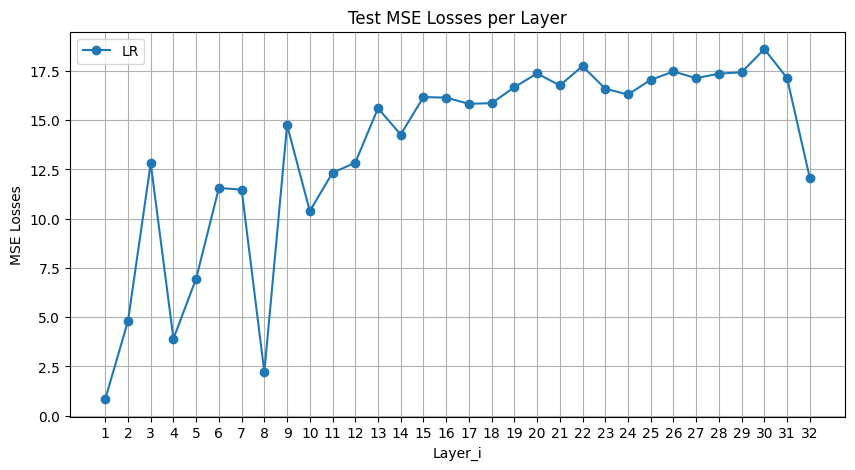

Min test loss: 2.3166647


In [433]:
plot_1d_metrics([slr_test_losses], ['LR'], 'MSE Losses', use_logarithm=True)
print("Min test loss:", min(slr_test_losses))

Using device: cuda
Training on SLT Dataset 1/32
Epoch 1/50, Training Loss: 1.2220, Validation Loss: 1.0210
Epoch 10/50, Training Loss: 0.6165, Validation Loss: 2.0489
Epoch 20/50, Training Loss: 0.3503, Validation Loss: 1.2313
Epoch 30/50, Training Loss: 0.2879, Validation Loss: 1.2801
Epoch 40/50, Training Loss: 0.2199, Validation Loss: 1.1089
Epoch 50/50, Training Loss: 0.2166, Validation Loss: 2.3863


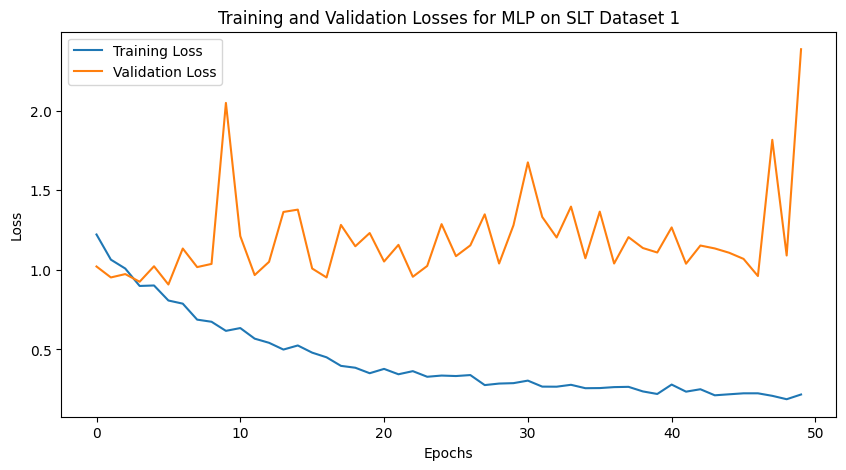

Test Loss: 2.2522
Training on SLT Dataset 2/32
Epoch 1/50, Training Loss: 1.2090, Validation Loss: 1.0308
Epoch 10/50, Training Loss: 0.6371, Validation Loss: 0.9752
Epoch 20/50, Training Loss: 0.3887, Validation Loss: 1.6978
Epoch 30/50, Training Loss: 0.2661, Validation Loss: 0.9831
Epoch 40/50, Training Loss: 0.2335, Validation Loss: 1.1051
Epoch 50/50, Training Loss: 0.1975, Validation Loss: 1.0413


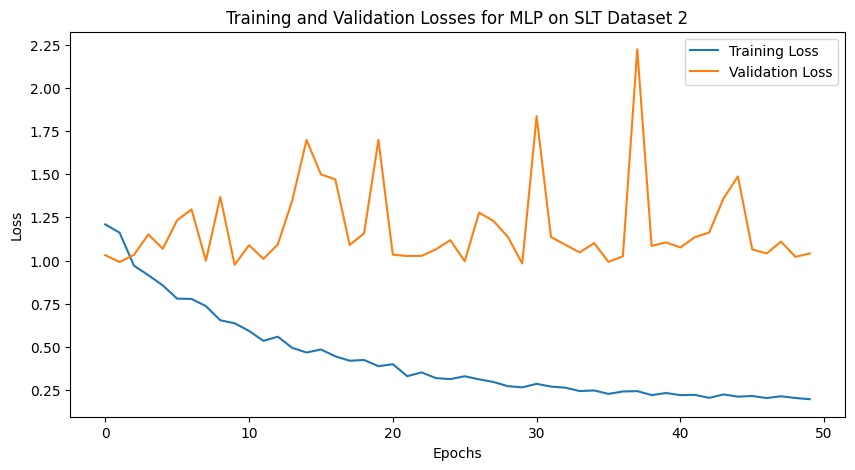

Test Loss: 1.1412
Training on SLT Dataset 3/32
Epoch 1/50, Training Loss: 1.3076, Validation Loss: 1.1897
Epoch 10/50, Training Loss: 0.5570, Validation Loss: 1.3903
Epoch 20/50, Training Loss: 0.3024, Validation Loss: 1.5101
Epoch 30/50, Training Loss: 0.2228, Validation Loss: 0.9508
Epoch 40/50, Training Loss: 0.1851, Validation Loss: 1.1306
Epoch 50/50, Training Loss: 0.1643, Validation Loss: 0.9446


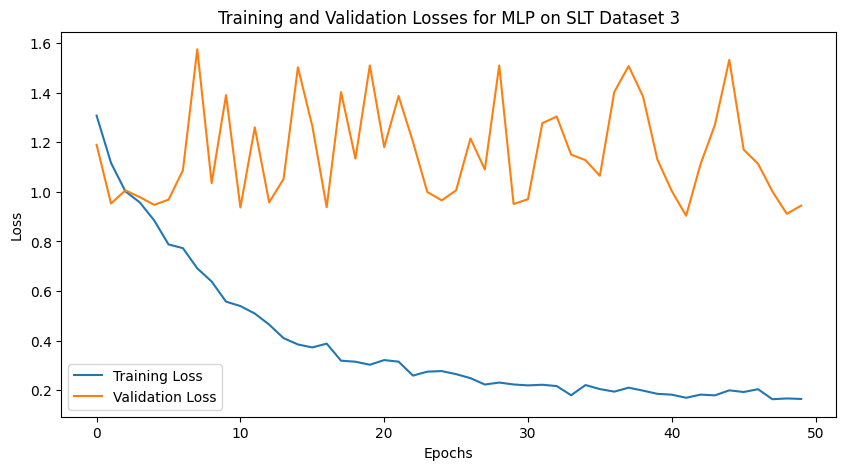

Test Loss: 1.0709
Training on SLT Dataset 4/32
Epoch 1/50, Training Loss: 1.2513, Validation Loss: 1.0468
Epoch 10/50, Training Loss: 0.5069, Validation Loss: 1.8030
Epoch 20/50, Training Loss: 0.2932, Validation Loss: 1.0204
Epoch 30/50, Training Loss: 0.2059, Validation Loss: 0.9058
Epoch 40/50, Training Loss: 0.1690, Validation Loss: 0.9271
Epoch 50/50, Training Loss: 0.1447, Validation Loss: 0.9772


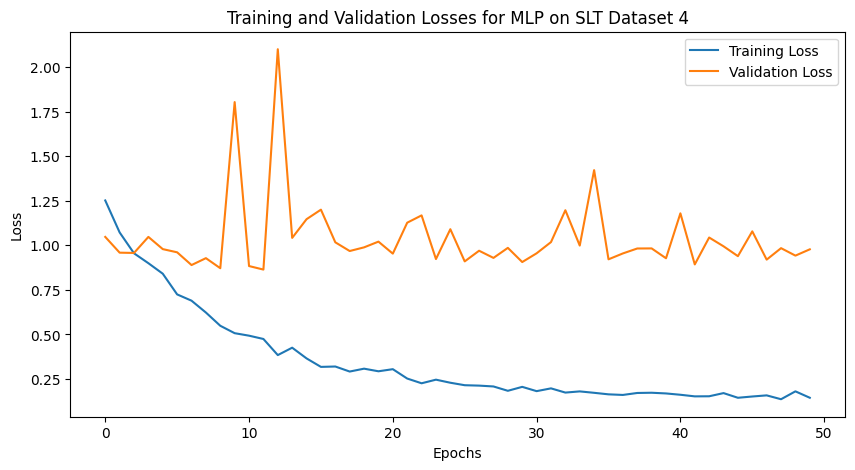

Test Loss: 1.0015
Training on SLT Dataset 5/32
Epoch 1/50, Training Loss: 1.2652, Validation Loss: 1.1798
Epoch 10/50, Training Loss: 0.5049, Validation Loss: 0.9504
Epoch 20/50, Training Loss: 0.2429, Validation Loss: 0.8622
Epoch 30/50, Training Loss: 0.1879, Validation Loss: 0.9014
Epoch 40/50, Training Loss: 0.1506, Validation Loss: 0.9451
Epoch 50/50, Training Loss: 0.1357, Validation Loss: 0.9103


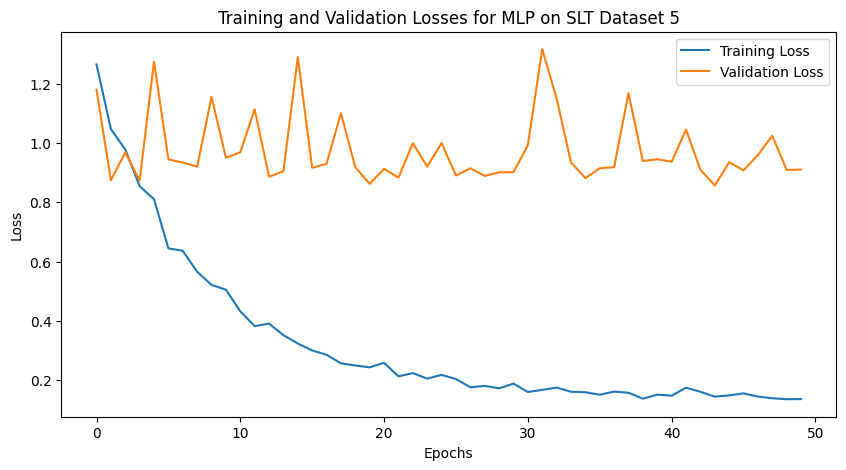

Test Loss: 0.9212
Training on SLT Dataset 6/32
Epoch 1/50, Training Loss: 1.2260, Validation Loss: 0.9695
Epoch 10/50, Training Loss: 0.4663, Validation Loss: 1.0726
Epoch 20/50, Training Loss: 0.2432, Validation Loss: 1.0213
Epoch 30/50, Training Loss: 0.1839, Validation Loss: 0.8770
Epoch 40/50, Training Loss: 0.1420, Validation Loss: 0.9878
Epoch 50/50, Training Loss: 0.1360, Validation Loss: 0.8519


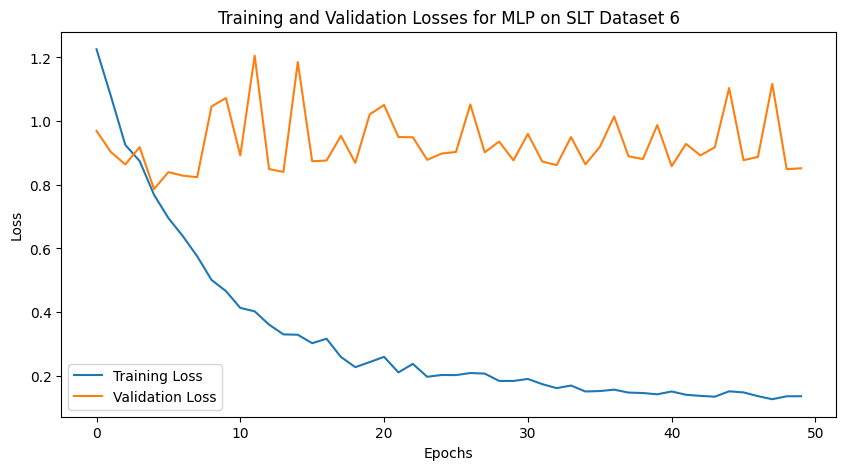

Test Loss: 0.8794
Training on SLT Dataset 7/32
Epoch 1/50, Training Loss: 1.2023, Validation Loss: 0.9118
Epoch 10/50, Training Loss: 0.4033, Validation Loss: 0.8337
Epoch 20/50, Training Loss: 0.2028, Validation Loss: 0.9130
Epoch 30/50, Training Loss: 0.1626, Validation Loss: 0.9677
Epoch 40/50, Training Loss: 0.1310, Validation Loss: 0.9340
Epoch 50/50, Training Loss: 0.1449, Validation Loss: 0.9233


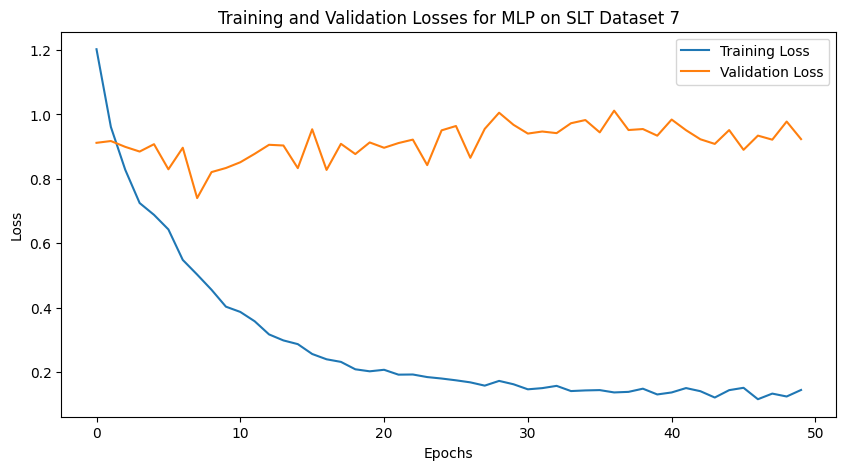

Test Loss: 0.8602
Training on SLT Dataset 8/32
Epoch 1/50, Training Loss: 1.1725, Validation Loss: 0.9714
Epoch 10/50, Training Loss: 0.4024, Validation Loss: 0.8682
Epoch 20/50, Training Loss: 0.1941, Validation Loss: 0.8862
Epoch 30/50, Training Loss: 0.1478, Validation Loss: 0.9321
Epoch 40/50, Training Loss: 0.1229, Validation Loss: 1.0375
Epoch 50/50, Training Loss: 0.1198, Validation Loss: 0.9506


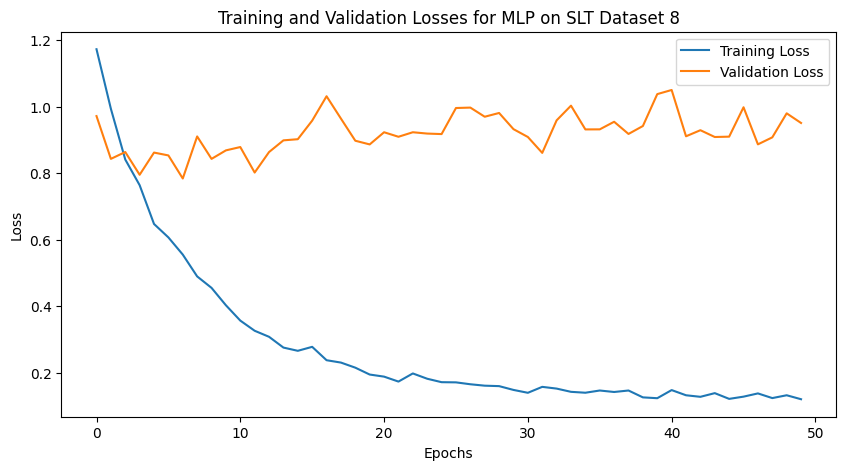

Test Loss: 0.9144
Training on SLT Dataset 9/32
Epoch 1/50, Training Loss: 1.2264, Validation Loss: 0.9349
Epoch 10/50, Training Loss: 0.3947, Validation Loss: 0.7913
Epoch 20/50, Training Loss: 0.2010, Validation Loss: 0.8548
Epoch 30/50, Training Loss: 0.1509, Validation Loss: 0.8450
Epoch 40/50, Training Loss: 0.1252, Validation Loss: 0.8702
Epoch 50/50, Training Loss: 0.1330, Validation Loss: 0.8531


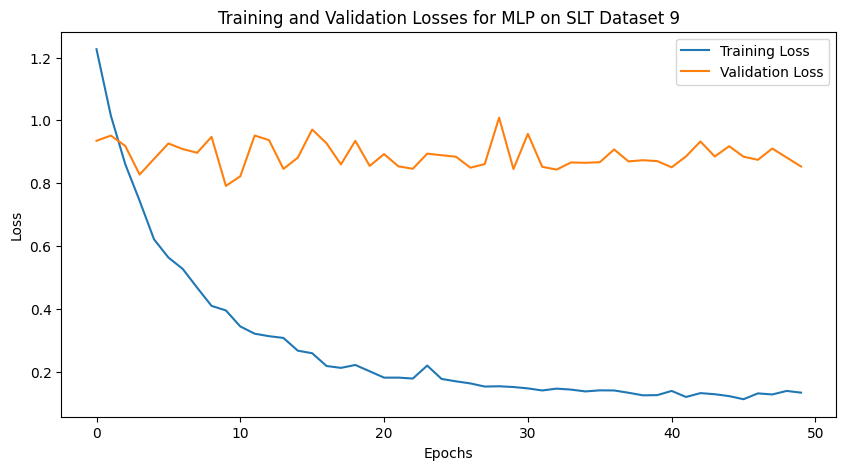

Test Loss: 0.8458
Training on SLT Dataset 10/32
Epoch 1/50, Training Loss: 1.1816, Validation Loss: 0.9134
Epoch 10/50, Training Loss: 0.3708, Validation Loss: 1.0417
Epoch 20/50, Training Loss: 0.1843, Validation Loss: 0.8196
Epoch 30/50, Training Loss: 0.1370, Validation Loss: 0.8722
Epoch 40/50, Training Loss: 0.1317, Validation Loss: 0.8150
Epoch 50/50, Training Loss: 0.1177, Validation Loss: 0.8606


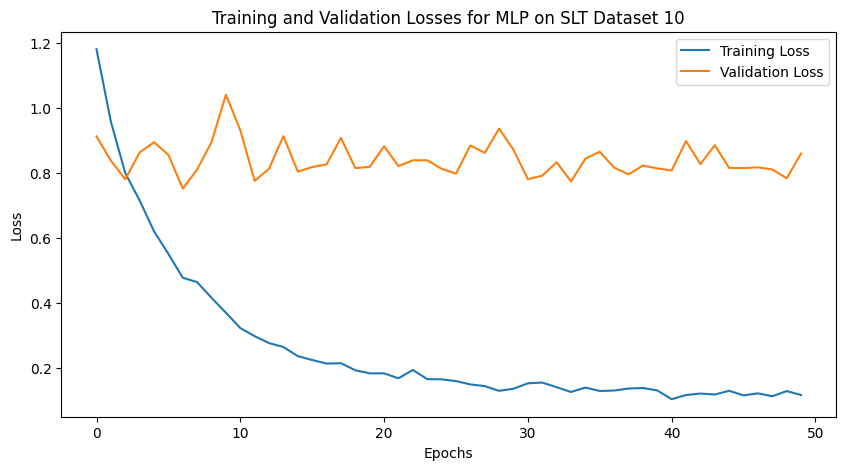

Test Loss: 0.7569
Training on SLT Dataset 11/32
Epoch 1/50, Training Loss: 1.2063, Validation Loss: 1.0294
Epoch 10/50, Training Loss: 0.3355, Validation Loss: 0.8107
Epoch 20/50, Training Loss: 0.1778, Validation Loss: 0.8218
Epoch 30/50, Training Loss: 0.1532, Validation Loss: 0.9037
Epoch 40/50, Training Loss: 0.1253, Validation Loss: 0.8494
Epoch 50/50, Training Loss: 0.1127, Validation Loss: 0.8308


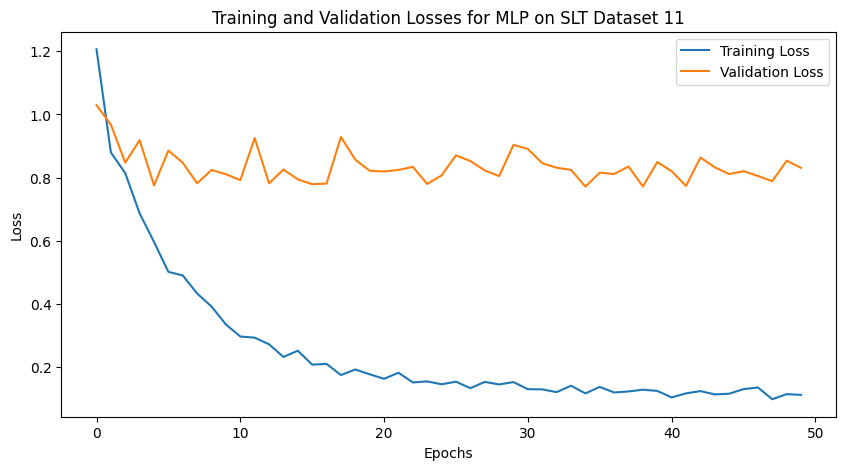

Test Loss: 0.7648
Training on SLT Dataset 12/32
Epoch 1/50, Training Loss: 1.1384, Validation Loss: 0.8814
Epoch 10/50, Training Loss: 0.3271, Validation Loss: 0.8206
Epoch 20/50, Training Loss: 0.1731, Validation Loss: 0.8273
Epoch 30/50, Training Loss: 0.1516, Validation Loss: 0.8072
Epoch 40/50, Training Loss: 0.1296, Validation Loss: 0.8446
Epoch 50/50, Training Loss: 0.1010, Validation Loss: 0.8394


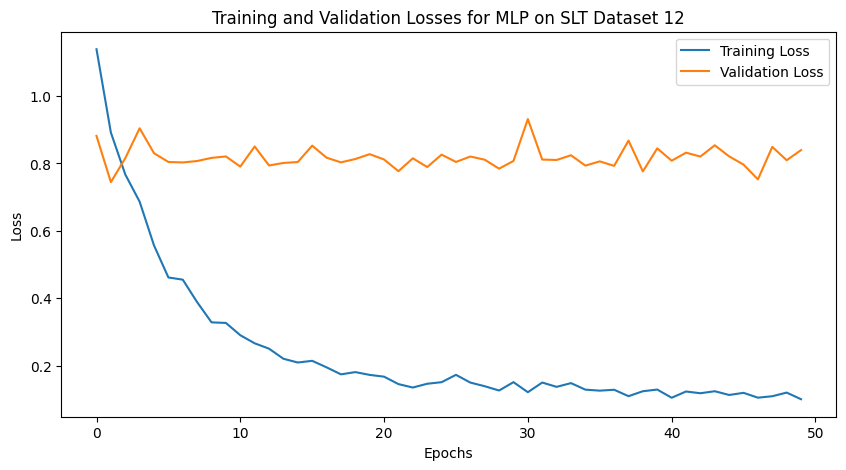

Test Loss: 0.8562
Training on SLT Dataset 13/32
Epoch 1/50, Training Loss: 1.0721, Validation Loss: 0.9995
Epoch 10/50, Training Loss: 0.3014, Validation Loss: 0.7417
Epoch 20/50, Training Loss: 0.1674, Validation Loss: 0.7220
Epoch 30/50, Training Loss: 0.1356, Validation Loss: 0.7423
Epoch 40/50, Training Loss: 0.1323, Validation Loss: 0.7827
Epoch 50/50, Training Loss: 0.0972, Validation Loss: 0.7882


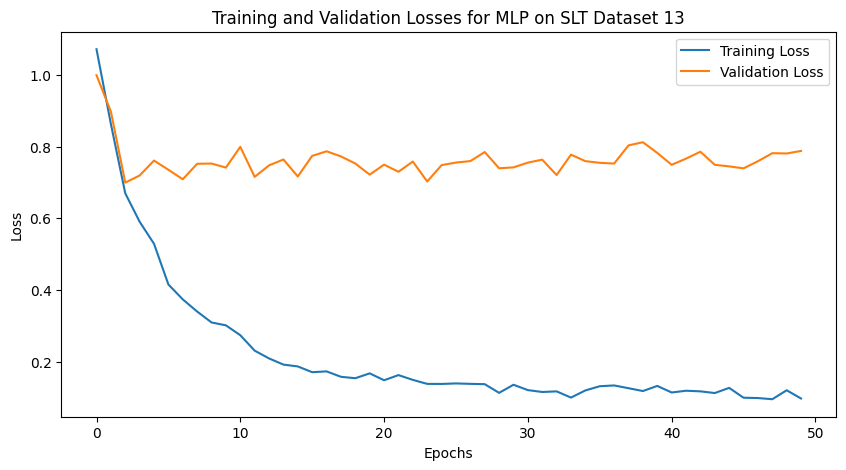

Test Loss: 0.7460
Training on SLT Dataset 14/32
Epoch 1/50, Training Loss: 1.1333, Validation Loss: 0.8739
Epoch 10/50, Training Loss: 0.2412, Validation Loss: 0.7304
Epoch 20/50, Training Loss: 0.1399, Validation Loss: 0.7501
Epoch 30/50, Training Loss: 0.1055, Validation Loss: 0.7255
Epoch 40/50, Training Loss: 0.1007, Validation Loss: 0.7713
Epoch 50/50, Training Loss: 0.0956, Validation Loss: 0.7857


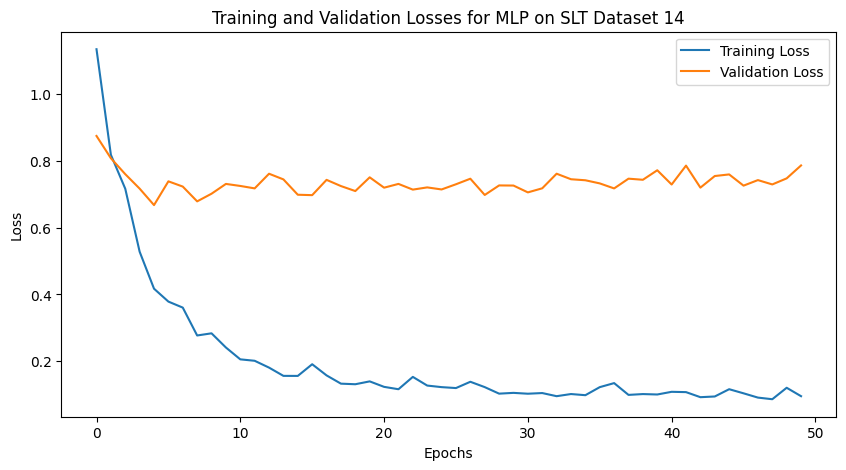

Test Loss: 0.7000
Training on SLT Dataset 15/32
Epoch 1/50, Training Loss: 1.0520, Validation Loss: 0.8964
Epoch 10/50, Training Loss: 0.2413, Validation Loss: 0.7469
Epoch 20/50, Training Loss: 0.1208, Validation Loss: 0.7093
Epoch 30/50, Training Loss: 0.1023, Validation Loss: 0.7381
Epoch 40/50, Training Loss: 0.1040, Validation Loss: 0.7674
Epoch 50/50, Training Loss: 0.1048, Validation Loss: 0.7294


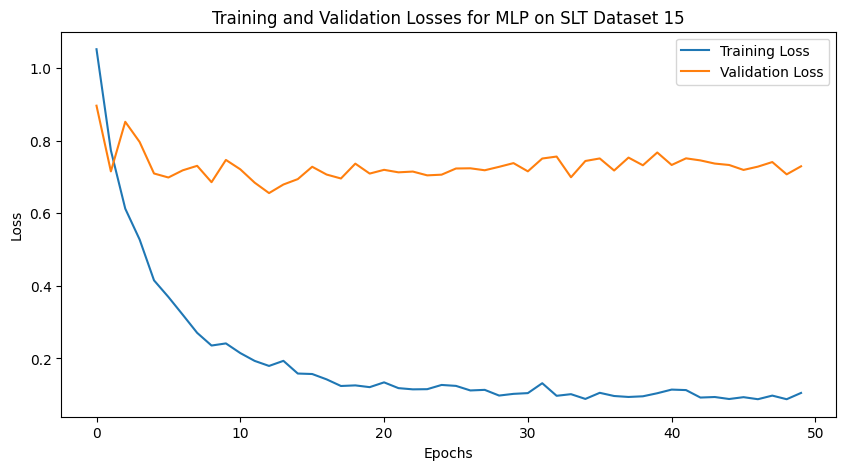

Test Loss: 0.6145
Training on SLT Dataset 16/32
Epoch 1/50, Training Loss: 1.0982, Validation Loss: 0.9762
Epoch 10/50, Training Loss: 0.2371, Validation Loss: 0.7114
Epoch 20/50, Training Loss: 0.1226, Validation Loss: 0.6868
Epoch 30/50, Training Loss: 0.1073, Validation Loss: 0.7094
Epoch 40/50, Training Loss: 0.0796, Validation Loss: 0.7321
Epoch 50/50, Training Loss: 0.0908, Validation Loss: 0.7030


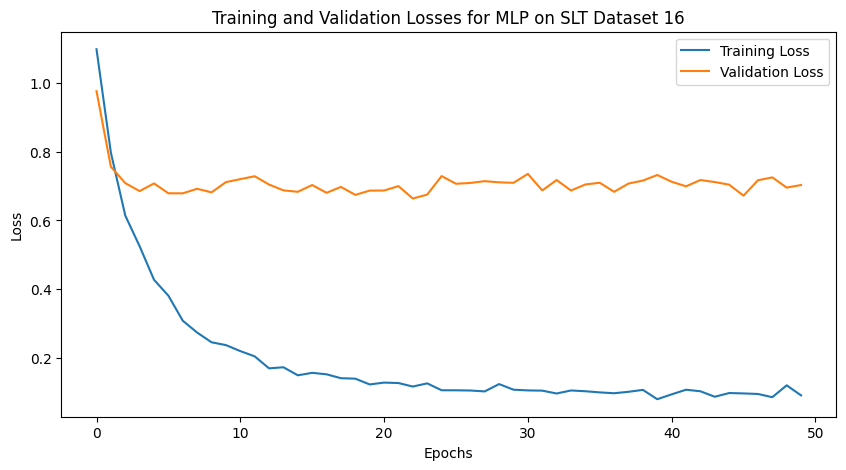

Test Loss: 0.6269
Training on SLT Dataset 17/32
Epoch 1/50, Training Loss: 1.0620, Validation Loss: 0.8253
Epoch 10/50, Training Loss: 0.2136, Validation Loss: 0.6558
Epoch 20/50, Training Loss: 0.1334, Validation Loss: 0.6895
Epoch 30/50, Training Loss: 0.0898, Validation Loss: 0.6571
Epoch 40/50, Training Loss: 0.1012, Validation Loss: 0.6680
Epoch 50/50, Training Loss: 0.0864, Validation Loss: 0.6778


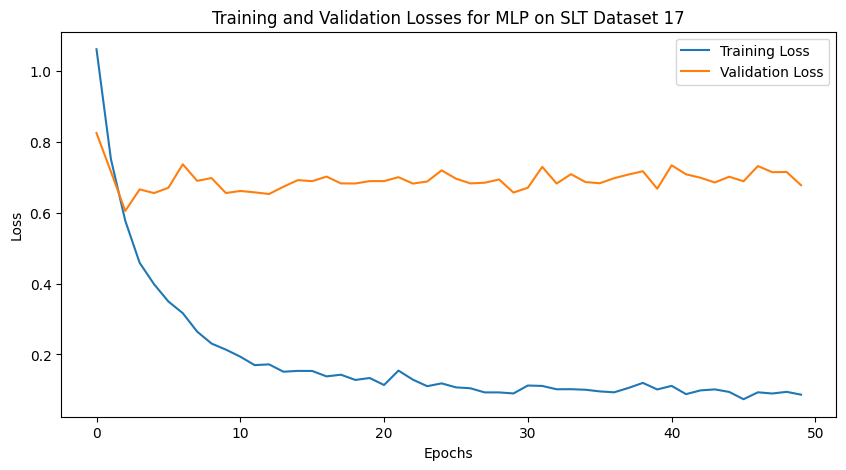

Test Loss: 0.5843
Training on SLT Dataset 18/32
Epoch 1/50, Training Loss: 1.0023, Validation Loss: 0.7962
Epoch 10/50, Training Loss: 0.1964, Validation Loss: 0.6939
Epoch 20/50, Training Loss: 0.1427, Validation Loss: 0.6870
Epoch 30/50, Training Loss: 0.1157, Validation Loss: 0.6513
Epoch 40/50, Training Loss: 0.1064, Validation Loss: 0.6505
Epoch 50/50, Training Loss: 0.0905, Validation Loss: 0.6618


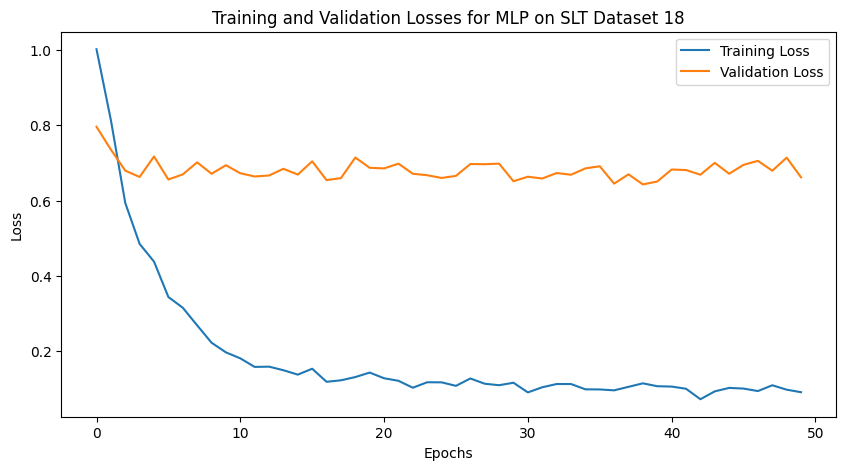

Test Loss: 0.6137
Training on SLT Dataset 19/32
Epoch 1/50, Training Loss: 1.0241, Validation Loss: 0.8701
Epoch 10/50, Training Loss: 0.1752, Validation Loss: 0.7155
Epoch 20/50, Training Loss: 0.1161, Validation Loss: 0.6992
Epoch 30/50, Training Loss: 0.1021, Validation Loss: 0.6556
Epoch 40/50, Training Loss: 0.0981, Validation Loss: 0.7496
Epoch 50/50, Training Loss: 0.1117, Validation Loss: 0.6638


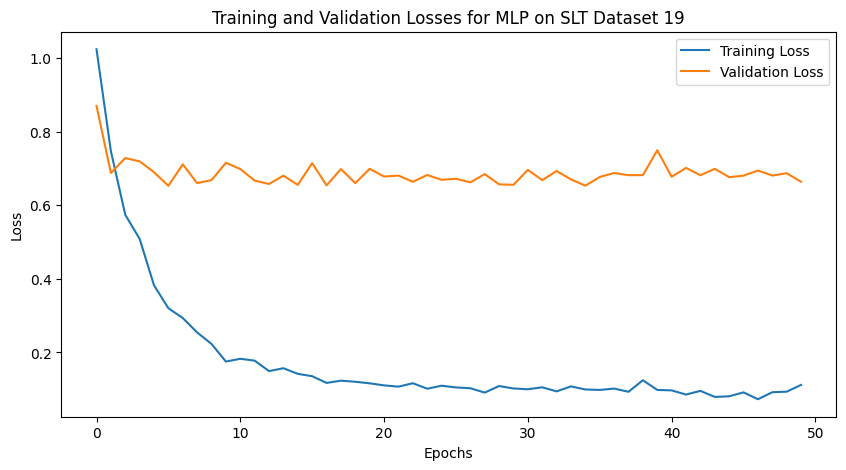

Test Loss: 0.5732
Training on SLT Dataset 20/32
Epoch 1/50, Training Loss: 0.9883, Validation Loss: 0.6703
Epoch 10/50, Training Loss: 0.1829, Validation Loss: 0.6896
Epoch 20/50, Training Loss: 0.1176, Validation Loss: 0.6807
Epoch 30/50, Training Loss: 0.0911, Validation Loss: 0.6728
Epoch 40/50, Training Loss: 0.0851, Validation Loss: 0.6770
Epoch 50/50, Training Loss: 0.1072, Validation Loss: 0.6823


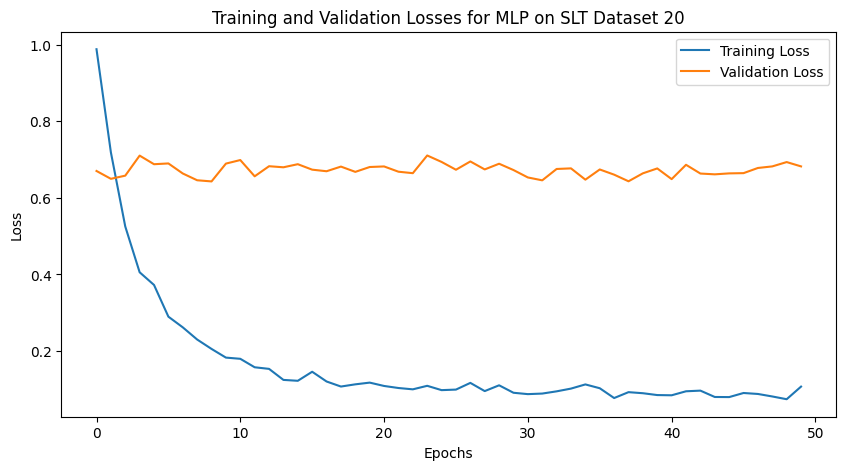

Test Loss: 0.5628
Training on SLT Dataset 21/32
Epoch 1/50, Training Loss: 1.0770, Validation Loss: 0.6193
Epoch 10/50, Training Loss: 0.2025, Validation Loss: 0.6434
Epoch 20/50, Training Loss: 0.1183, Validation Loss: 0.6358
Epoch 30/50, Training Loss: 0.0853, Validation Loss: 0.6749
Epoch 40/50, Training Loss: 0.0926, Validation Loss: 0.6604
Epoch 50/50, Training Loss: 0.0811, Validation Loss: 0.6732


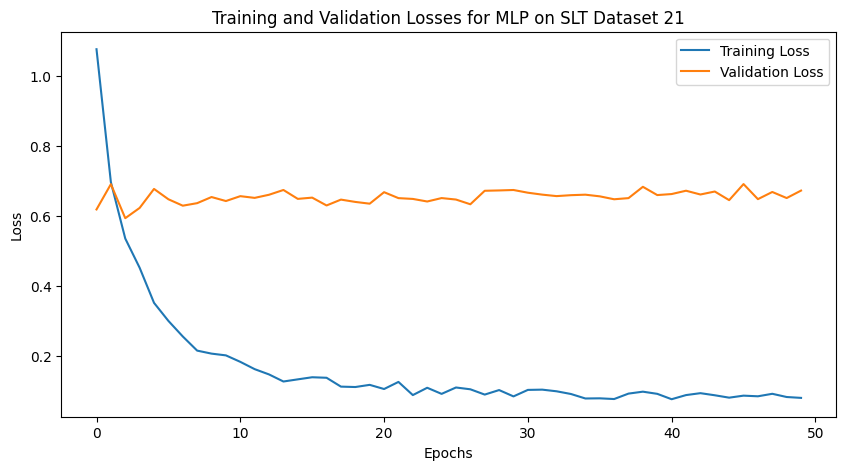

Test Loss: 0.5542
Training on SLT Dataset 22/32
Epoch 1/50, Training Loss: 1.0181, Validation Loss: 0.6813
Epoch 10/50, Training Loss: 0.1816, Validation Loss: 0.6177
Epoch 20/50, Training Loss: 0.0925, Validation Loss: 0.6545
Epoch 30/50, Training Loss: 0.1158, Validation Loss: 0.6406
Epoch 40/50, Training Loss: 0.0820, Validation Loss: 0.6283
Epoch 50/50, Training Loss: 0.0851, Validation Loss: 0.6511


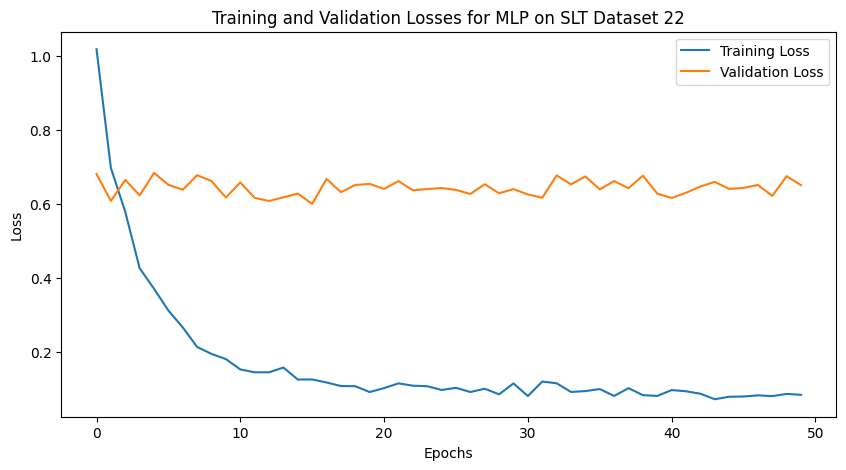

Test Loss: 0.5588
Training on SLT Dataset 23/32
Epoch 1/50, Training Loss: 0.9921, Validation Loss: 0.7880
Epoch 10/50, Training Loss: 0.1800, Validation Loss: 0.6353
Epoch 20/50, Training Loss: 0.1050, Validation Loss: 0.6255
Epoch 30/50, Training Loss: 0.0859, Validation Loss: 0.6349
Epoch 40/50, Training Loss: 0.0844, Validation Loss: 0.6401
Epoch 50/50, Training Loss: 0.0807, Validation Loss: 0.6205


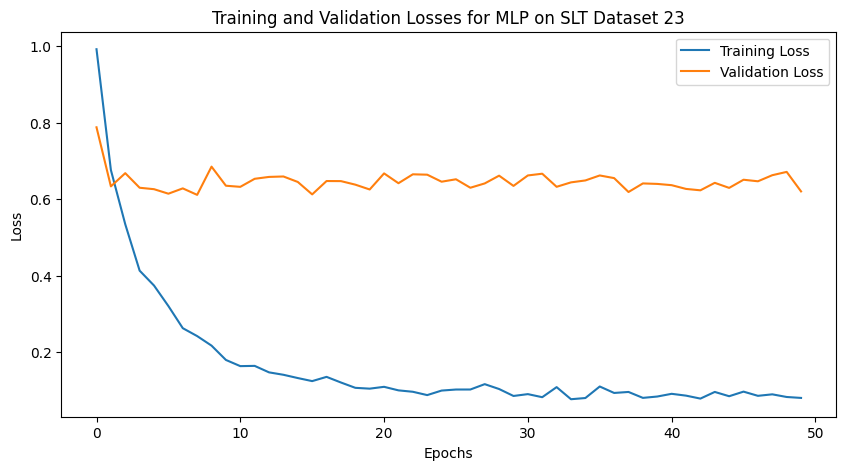

Test Loss: 0.5213
Training on SLT Dataset 24/32
Epoch 1/50, Training Loss: 1.0277, Validation Loss: 0.6704
Epoch 10/50, Training Loss: 0.1821, Validation Loss: 0.6423
Epoch 20/50, Training Loss: 0.1130, Validation Loss: 0.6363
Epoch 30/50, Training Loss: 0.0844, Validation Loss: 0.6501
Epoch 40/50, Training Loss: 0.0866, Validation Loss: 0.6636
Epoch 50/50, Training Loss: 0.0776, Validation Loss: 0.6894


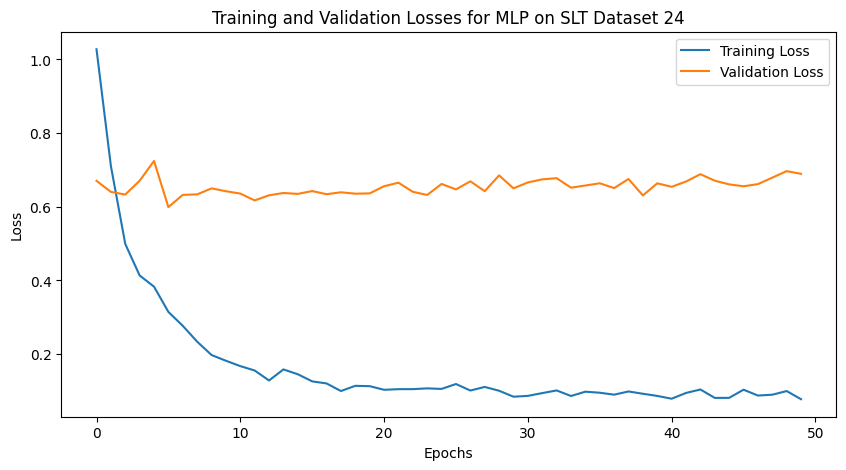

Test Loss: 0.5581
Training on SLT Dataset 25/32
Epoch 1/50, Training Loss: 0.9844, Validation Loss: 0.8437
Epoch 10/50, Training Loss: 0.1706, Validation Loss: 0.6504
Epoch 20/50, Training Loss: 0.1190, Validation Loss: 0.6260
Epoch 30/50, Training Loss: 0.0936, Validation Loss: 0.6346
Epoch 40/50, Training Loss: 0.1012, Validation Loss: 0.6568
Epoch 50/50, Training Loss: 0.0917, Validation Loss: 0.6835


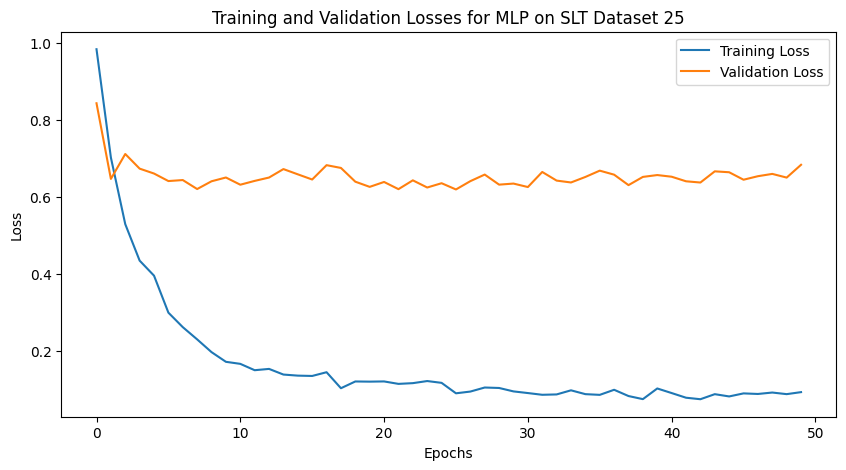

Test Loss: 0.6002
Training on SLT Dataset 26/32
Epoch 1/50, Training Loss: 0.9767, Validation Loss: 0.7360
Epoch 10/50, Training Loss: 0.1772, Validation Loss: 0.6568
Epoch 20/50, Training Loss: 0.0975, Validation Loss: 0.6317
Epoch 30/50, Training Loss: 0.0950, Validation Loss: 0.6158
Epoch 40/50, Training Loss: 0.0826, Validation Loss: 0.6173
Epoch 50/50, Training Loss: 0.1016, Validation Loss: 0.5826


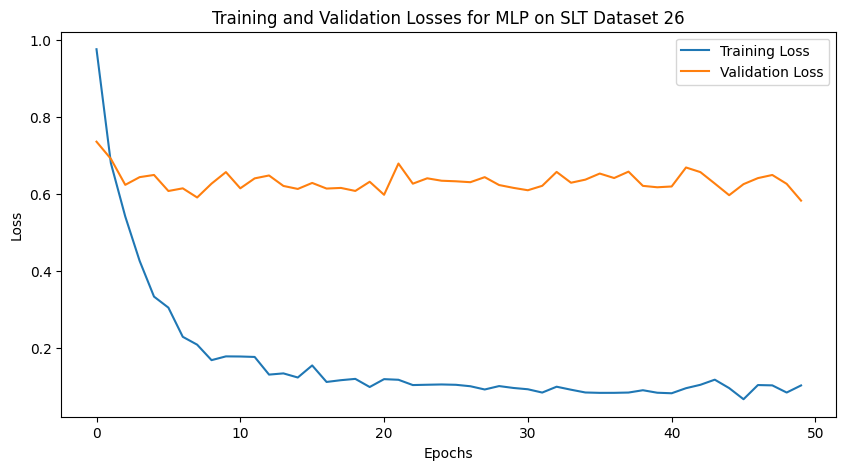

Test Loss: 0.5273
Training on SLT Dataset 27/32
Epoch 1/50, Training Loss: 1.0519, Validation Loss: 0.8050
Epoch 10/50, Training Loss: 0.1689, Validation Loss: 0.6092
Epoch 20/50, Training Loss: 0.1053, Validation Loss: 0.6110
Epoch 30/50, Training Loss: 0.0932, Validation Loss: 0.6003
Epoch 40/50, Training Loss: 0.0929, Validation Loss: 0.6109
Epoch 50/50, Training Loss: 0.1050, Validation Loss: 0.5845


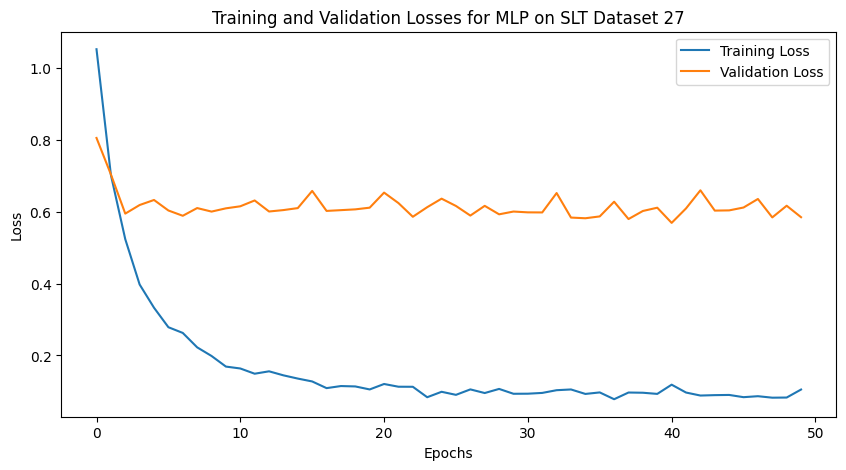

Test Loss: 0.5111
Training on SLT Dataset 28/32
Epoch 1/50, Training Loss: 1.0747, Validation Loss: 0.6768
Epoch 10/50, Training Loss: 0.1736, Validation Loss: 0.6160
Epoch 20/50, Training Loss: 0.1083, Validation Loss: 0.6268
Epoch 30/50, Training Loss: 0.1086, Validation Loss: 0.6099
Epoch 40/50, Training Loss: 0.0787, Validation Loss: 0.6225
Epoch 50/50, Training Loss: 0.0689, Validation Loss: 0.6315


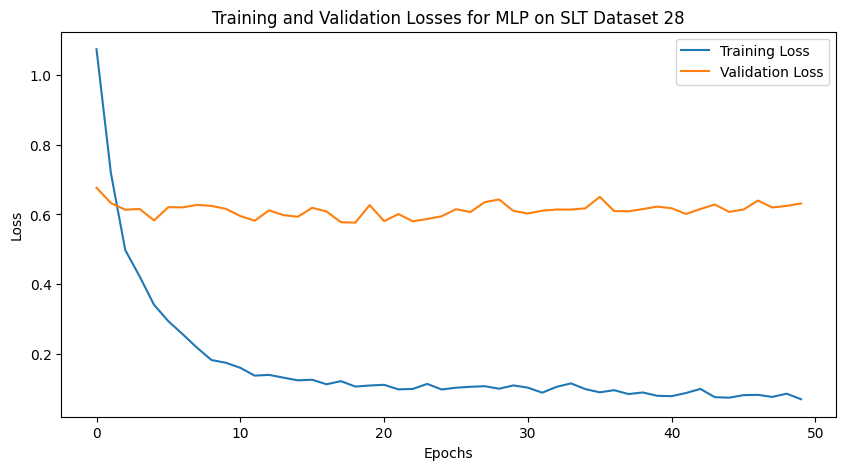

Test Loss: 0.5338
Training on SLT Dataset 29/32
Epoch 1/50, Training Loss: 1.0557, Validation Loss: 0.7372
Epoch 10/50, Training Loss: 0.1520, Validation Loss: 0.6061
Epoch 20/50, Training Loss: 0.1151, Validation Loss: 0.6353
Epoch 30/50, Training Loss: 0.0835, Validation Loss: 0.6225
Epoch 40/50, Training Loss: 0.1014, Validation Loss: 0.6217
Epoch 50/50, Training Loss: 0.0850, Validation Loss: 0.6282


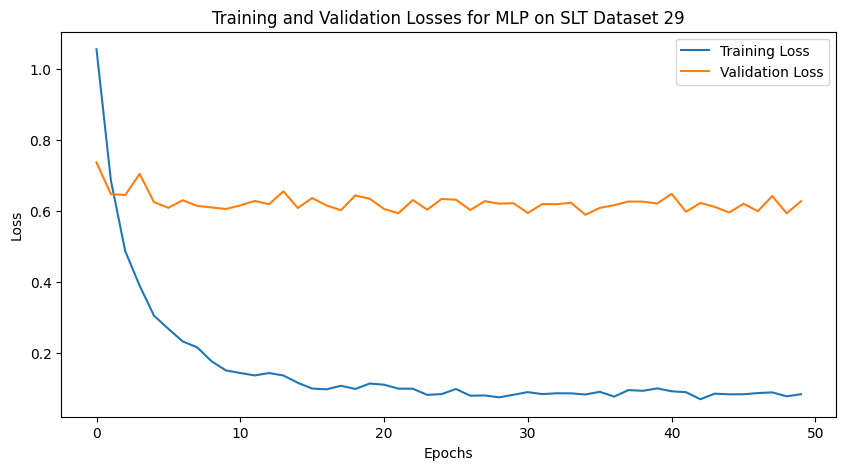

Test Loss: 0.5536
Training on SLT Dataset 30/32
Epoch 1/50, Training Loss: 1.0169, Validation Loss: 0.8205
Epoch 10/50, Training Loss: 0.1690, Validation Loss: 0.6179
Epoch 20/50, Training Loss: 0.1018, Validation Loss: 0.5681
Epoch 30/50, Training Loss: 0.0975, Validation Loss: 0.5700
Epoch 40/50, Training Loss: 0.0876, Validation Loss: 0.5774
Epoch 50/50, Training Loss: 0.0733, Validation Loss: 0.5602


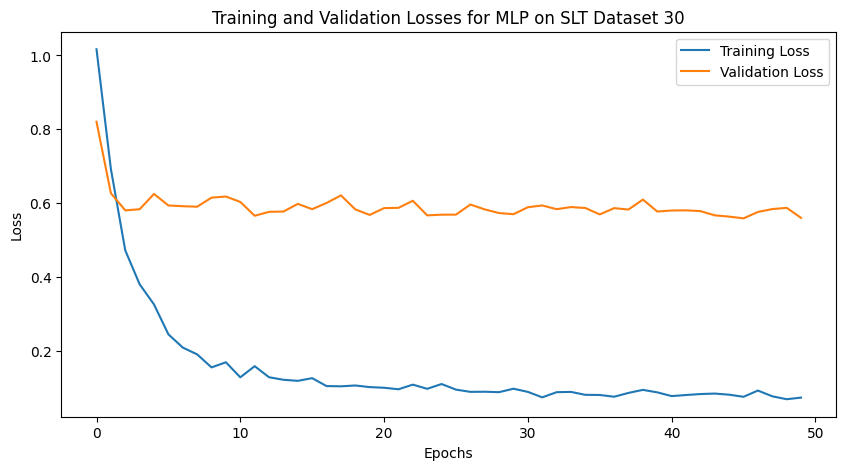

Test Loss: 0.5280
Training on SLT Dataset 31/32
Epoch 1/50, Training Loss: 1.0560, Validation Loss: 0.6606
Epoch 10/50, Training Loss: 0.1510, Validation Loss: 0.5815
Epoch 20/50, Training Loss: 0.0958, Validation Loss: 0.5857
Epoch 30/50, Training Loss: 0.0848, Validation Loss: 0.5911
Epoch 40/50, Training Loss: 0.0771, Validation Loss: 0.5905
Epoch 50/50, Training Loss: 0.0622, Validation Loss: 0.6064


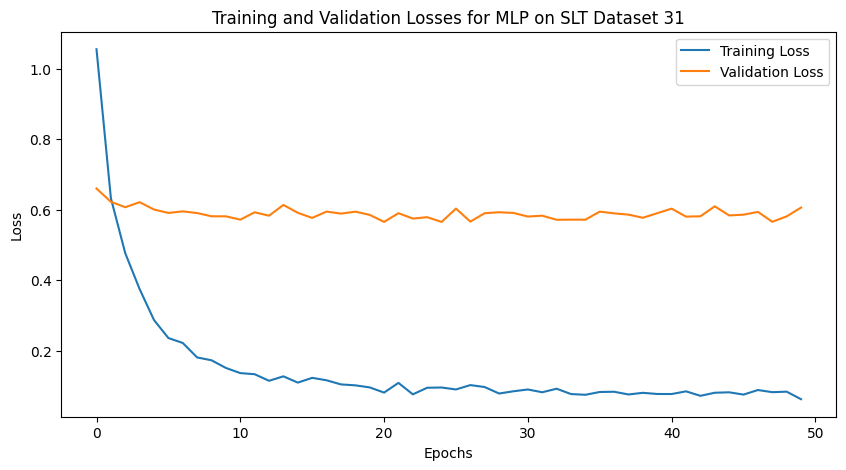

Test Loss: 0.5658
Training on SLT Dataset 32/32
Epoch 1/50, Training Loss: 0.9338, Validation Loss: 0.6652
Epoch 10/50, Training Loss: 0.1482, Validation Loss: 0.5814
Epoch 20/50, Training Loss: 0.0877, Validation Loss: 0.5909
Epoch 30/50, Training Loss: 0.0857, Validation Loss: 0.6039
Epoch 40/50, Training Loss: 0.0928, Validation Loss: 0.5939
Epoch 50/50, Training Loss: 0.0808, Validation Loss: 0.5864


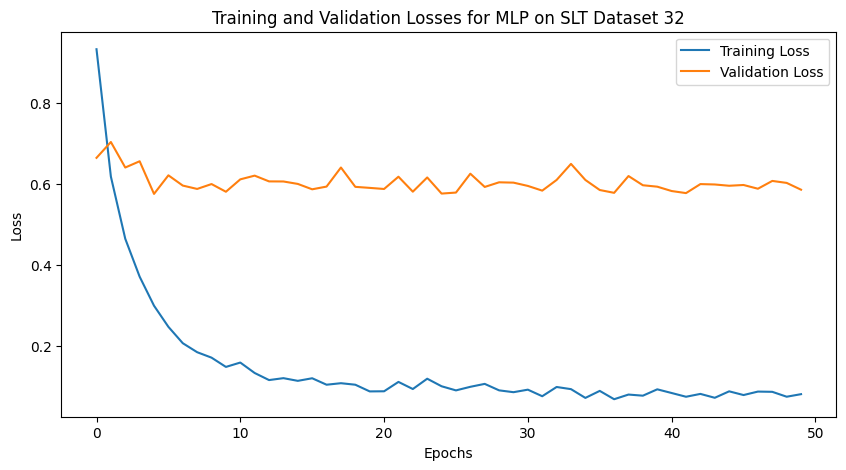

Test Loss: 0.5436


In [434]:
# Training Loops: single MLP.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions 
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50
smlp_test_losses = []

for i, (train_loader, valid_loader, test_loader) in enumerate(zip(slt_train_dataloaders, slt_valid_dataloaders, slt_test_dataloaders)):
    print(f"Training on SLT Dataset {i+1}/{len(slt_train_dataloaders)}")
    model = MLP(in_dim, hid_dims, out_dim, dropout)
    # model = EnsembleMLP(in_dim, hid_dims, out_dim, dropout)
    train_and_evaluate(model, train_loader, valid_loader, device, epochs=epochs, title=f"MLP on SLT Dataset {i+1}")
    test_loss = evaluate_on_test(model, test_loader, device)
    smlp_test_losses.append(test_loss)

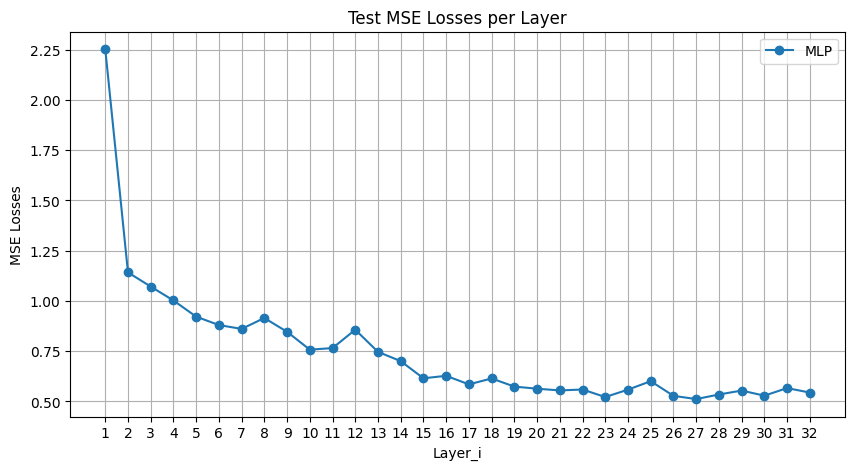

In [435]:
plot_1d_metrics([smlp_test_losses], ['MLP'], 'MSE Losses')

In [436]:
# Verify zero prediction loss is normalized SE's variance (~1.0)
print("Baseline loss:",np.mean(y_tests[0]**2))
print(f"MLP best loss: {min(smlp_test_losses):.7f}")

Baseline loss: 1.0855412
MLP best loss: 0.5111140


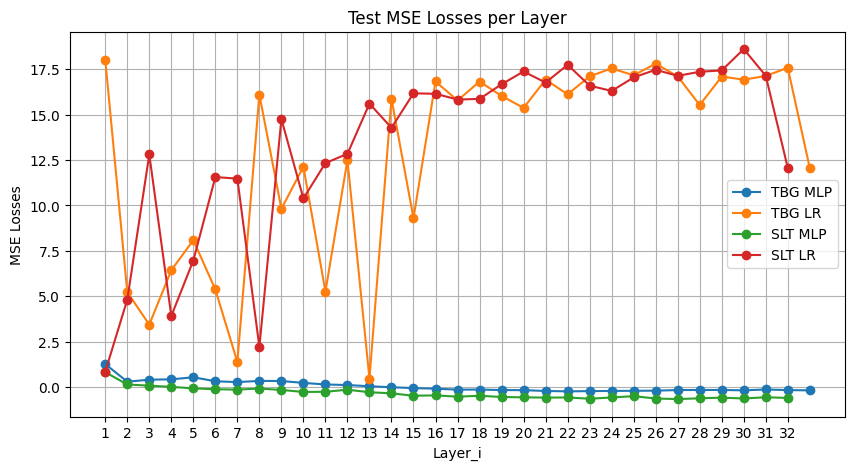

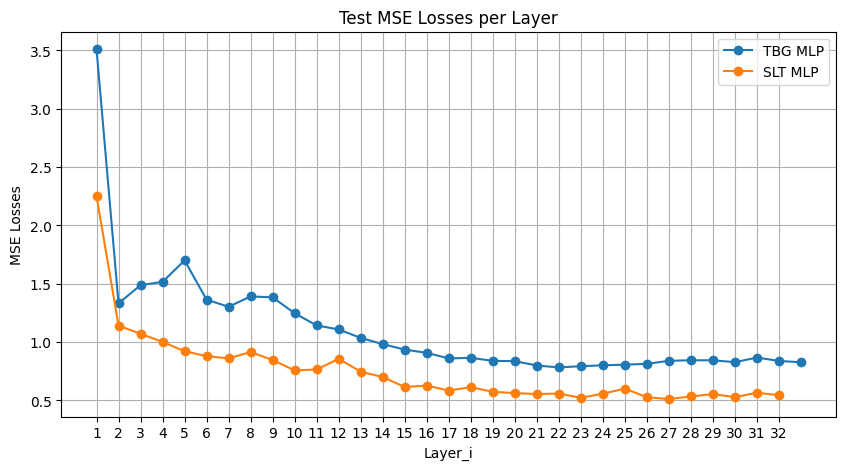

In [437]:
# Plot all MSE losses from MLP and LR on TBG and SLT.
plot_1d_metrics([tmlp_test_losses, lr_test_losses, smlp_test_losses, slr_test_losses], ['TBG MLP','TBG LR',
                                                                                     'SLT MLP','SLT LR'], 'MSE Losses',
               save_fig=True, use_logarithm=True)

plot_1d_metrics([tmlp_test_losses, smlp_test_losses], ['TBG MLP','SLT MLP'], 'MSE Losses',
               save_fig=True)

LR's are performing much worse than MLP's on regression tasks; MLP trained on TBG performs worse than that on SLT.

In [438]:
# Binarized entropy classification with SLT token.
slt_train_dataloaders, slt_valid_dataloaders, slt_test_dataloaders = create_dataloaders(slt_layered_datasets, bca_entropy, total_size, batch_size)
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)

In [439]:
# Training with a single LR on all datasets.
from sklearn.linear_model import LogisticRegression

sblr_test_accs = []
sblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"ogistic Regression on SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sblr_test_accs.append(test_acc)
    sblr_test_aucs.append(test_auc)

Training on SLT Dataset 1/32
Validation Accuracy: 0.6583, AUROC: 0.6963
Training Loss: 0.5433, Validation Loss: 0.6316
Test Loss: 0.6041, Test Accuracy: 0.6850, AUROC: 0.7343
Training on SLT Dataset 2/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6361, AUROC: 0.6910
Training Loss: 0.5057, Validation Loss: 0.6310
Test Loss: 0.5956, Test Accuracy: 0.6600, AUROC: 0.7394
Training on SLT Dataset 3/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6528, AUROC: 0.6751
Training Loss: 0.4349, Validation Loss: 0.6574
Test Loss: 0.5685, Test Accuracy: 0.6950, AUROC: 0.7686
Training on SLT Dataset 4/32


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6972, AUROC: 0.7807
Training Loss: 0.0062, Validation Loss: 1.6030
Test Loss: 0.8689, Test Accuracy: 0.8150, AUROC: 0.8939
Training on SLT Dataset 31/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7194, AUROC: 0.7833
Training Loss: 0.0063, Validation Loss: 1.5212
Test Loss: 0.7521, Test Accuracy: 0.7900, AUROC: 0.9012
Training on SLT Dataset 32/32
Validation Accuracy: 0.7139, AUROC: 0.7845
Training Loss: 0.0107, Validation Loss: 1.2852
Test Loss: 0.6693, Test Accuracy: 0.8050, AUROC: 0.8964


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


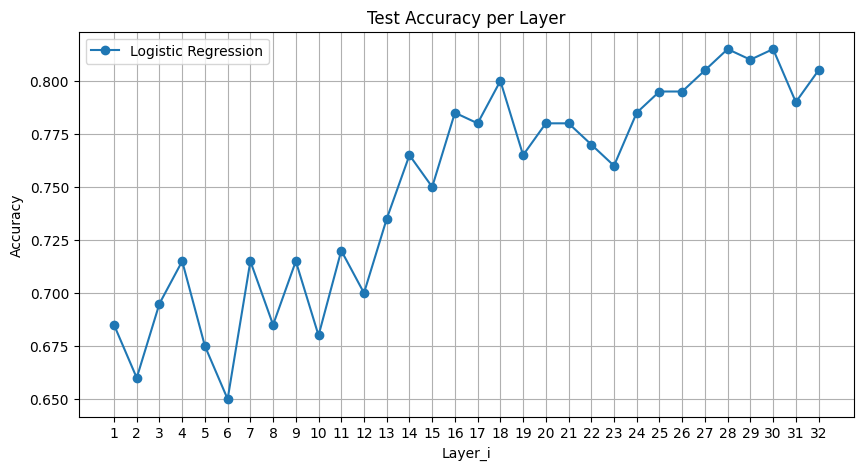

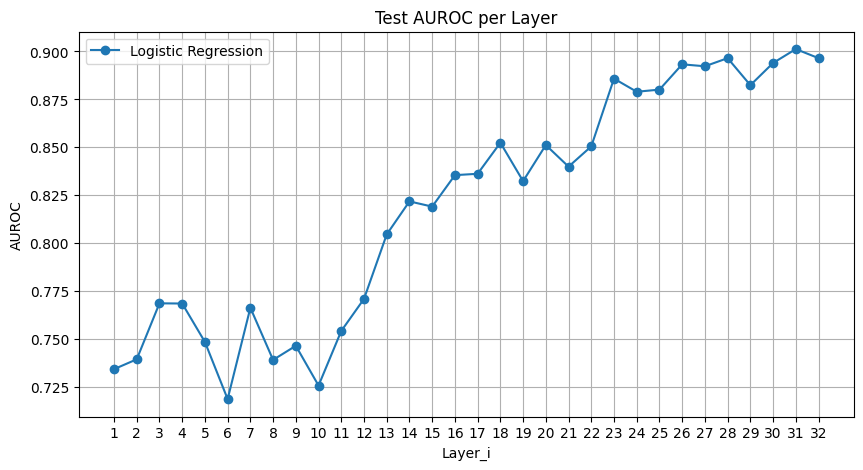

In [440]:
plot_1d_metrics([sblr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([sblr_test_aucs], ['Logistic Regression'], 'AUROC')

In [441]:
# Training with a single MLP on all datasets.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544 # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50
sbmlp_test_accs = []
sbmlp_test_aucs = []

for i, (train_loader, valid_loader, test_loader) in enumerate(zip(slt_train_dataloaders, slt_valid_dataloaders, slt_test_dataloaders)):
    print(f"Training on SLT Dataset {i+1}/{len(slt_train_dataloaders)}")
    model = MLPClassifier(in_dim, hid_dims, dropout)
    train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on SLT Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(model, test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    sbmlp_test_accs.append(test_acc)
    sbmlp_test_aucs.append(test_auc)

Using device: cuda
Training on SLT Dataset 1/32
Epoch 1/50, Training Loss: 61.4046, Validation Loss: 53.4588, Training Accuracy: 0.5681
Epoch 10/50, Training Loss: 59.0049, Validation Loss: 53.1408, Training Accuracy: 0.7917
Epoch 20/50, Training Loss: 58.1403, Validation Loss: 53.4940, Training Accuracy: 0.8507
Epoch 30/50, Training Loss: 57.7370, Validation Loss: 52.9761, Training Accuracy: 0.8764
Epoch 40/50, Training Loss: 57.6221, Validation Loss: 53.0561, Training Accuracy: 0.8819
Epoch 50/50, Training Loss: 57.2179, Validation Loss: 53.7495, Training Accuracy: 0.9035
Test Loss: 54.7099, Test Accuracy: 0.6100, AUROC: 0.7230
Training on SLT Dataset 2/32
Epoch 1/50, Training Loss: 61.5050, Validation Loss: 53.7013, Training Accuracy: 0.5764
Epoch 10/50, Training Loss: 59.1111, Validation Loss: 53.4375, Training Accuracy: 0.7799
Epoch 20/50, Training Loss: 58.2547, Validation Loss: 53.7150, Training Accuracy: 0.8444
Epoch 30/50, Training Loss: 57.8661, Validation Loss: 53.6408, Trai

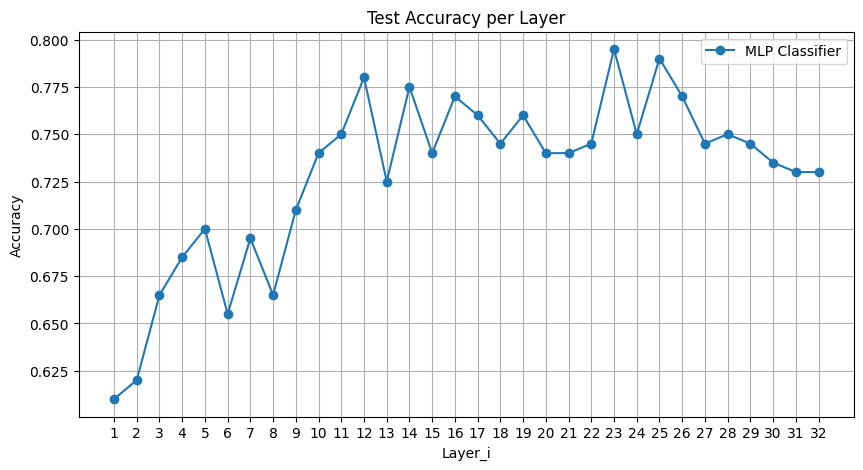

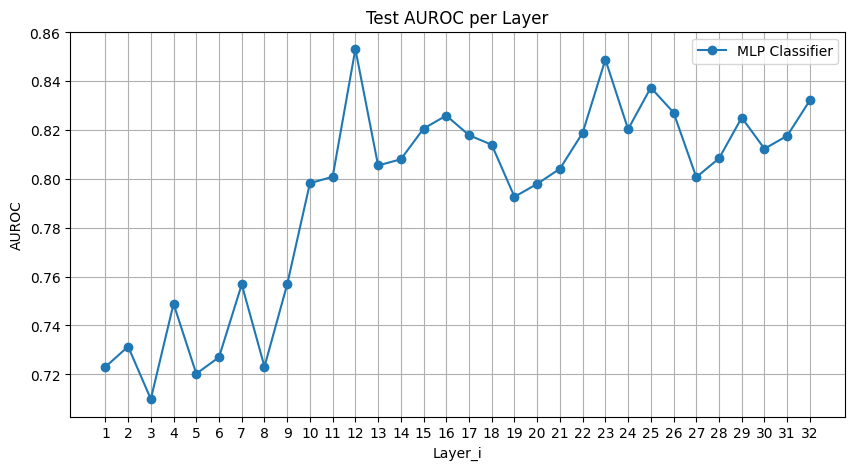

In [443]:
plot_1d_metrics([sbmlp_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([sbmlp_test_aucs], ['MLP Classifier'], 'AUROC')

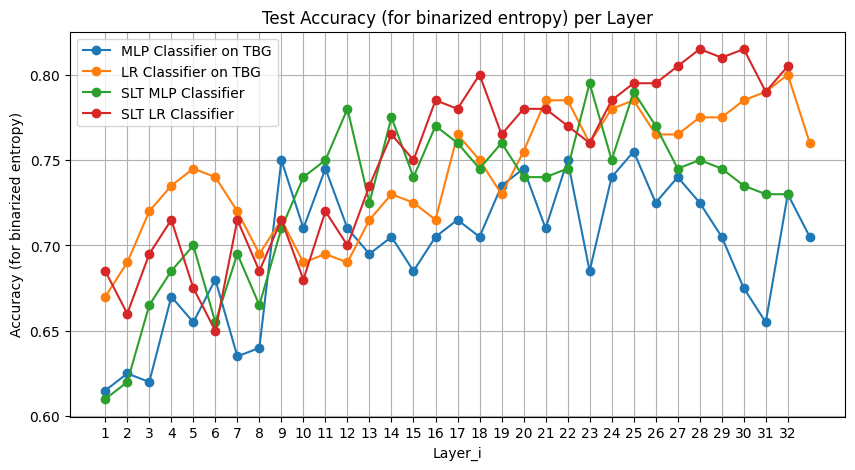

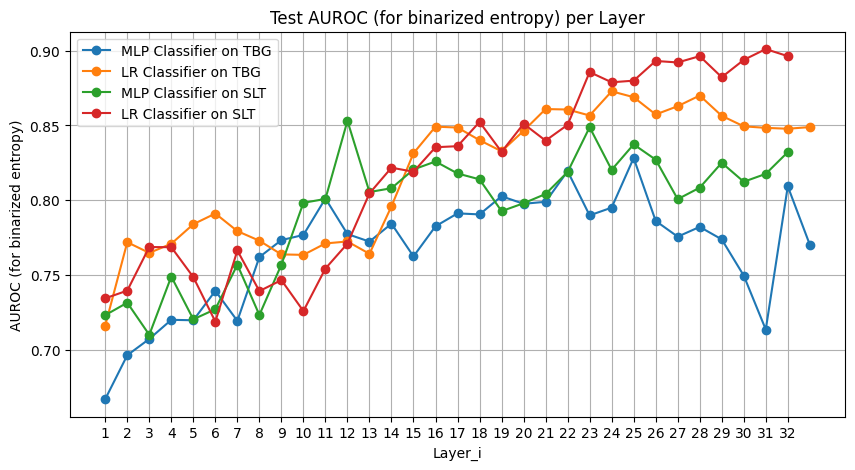

In [445]:
plot_1d_metrics([tbmlp_test_accs, tblr_test_accs, sbmlp_test_accs, sblr_test_accs], ['MLP Classifier on TBG','LR Classifier on TBG',
                                                                                     'SLT MLP Classifier','SLT LR Classifier'], 'Accuracy (for binarized entropy)',
               save_fig=True)

plot_1d_metrics([tbmlp_test_aucs, tblr_test_aucs, sbmlp_test_aucs, sblr_test_aucs], ['MLP Classifier on TBG','LR Classifier on TBG',
                                                                                     'MLP Classifier on SLT','LR Classifier on SLT'], 'AUROC (for binarized entropy)',
               save_fig=True)

We see that despite poor performances on regression tasks, LR overtook MLP on binary classification on later layers (from ~17th layer onwards). 

And in general, models trained on SLT achieved better test accuracy and AUROC scores than those on TBG.

## Use Linear Probe for Predicting Correctness of Generated Answers (or Accuracy)

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

We will use logistic regression for this task, as for the binarized entropy prediction task.

### Token Before first Generation (TBG)

In [446]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([2000]) tensor([1., 1., 1., 1., 0., 0., 0., 0., 0., 0.])


In [454]:
# Create data loaders from tbg embeddings
tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders = create_dataloaders(tok_bef_gen_layered_datasets, accuracies, total_size, batch_size)
# Prepare X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, accuracies, total_size)

In [451]:
# Dummy accuracy.
corrects = 0
total = 0
for _, labels in tbg_test_dataloaders[0]:  # any test loader is fine due to homogeneious splits.
    corrects += (labels > 0.0).int().sum()
    total += labels.size(0)
print(f"Dummy accuracy: {float(max(1-corrects/total,corrects/total)):.4f}")

Dummy accuracy: 0.5300


In [457]:
# Training Loops (LR)
talr_test_accs = []
talr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(tbg_train_dataloaders)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    talr_test_accs.append(test_acc)
    talr_test_aucs.append(test_auc)

Training on TBG-Acc Dataset 1/33
Validation Accuracy: 0.6306, AUROC: 0.5981
Training Loss: 0.4279, Validation Loss: 0.6865
Test Loss: 0.6879, Test Accuracy: 0.6450, AUROC: 0.6676
Training on TBG-Acc Dataset 2/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6194, AUROC: 0.6275
Training Loss: 0.2454, Validation Loss: 0.9984
Test Loss: 1.2171, Test Accuracy: 0.6550, AUROC: 0.6392
Training on TBG-Acc Dataset 3/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6083, AUROC: 0.6277
Training Loss: 0.2132, Validation Loss: 1.1432
Test Loss: 1.2611, Test Accuracy: 0.6600, AUROC: 0.6656
Training on TBG-Acc Dataset 4/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6222, AUROC: 0.6849
Training Loss: 0.0153, Validation Loss: 1.3039
Test Loss: 1.4696, Test Accuracy: 0.6150, AUROC: 0.6910
Training on TBG-Acc Dataset 14/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6806, AUROC: 0.7157
Training Loss: 0.0129, Validation Loss: 1.2147
Test Loss: 1.3897, Test Accuracy: 0.6400, AUROC: 0.7200
Training on TBG-Acc Dataset 15/33
Validation Accuracy: 0.7028, AUROC: 0.7261
Training Loss: 0.0081, Validation Loss: 1.2508
Test Loss: 1.2583, Test Accuracy: 0.6750, AUROC: 0.7554
Training on TBG-Acc Dataset 16/33
Validation Accuracy: 0.6889, AUROC: 0.7265
Training Loss: 0.0068, Validation Loss: 1.2392
Test Loss: 1.2641, Test Accuracy: 0.6850, AUROC: 0.7615
Training on TBG-Acc Dataset 17/33
Validation Accuracy: 0.6806, AUROC: 0.7238
Training Loss: 0.0057, Validation Loss: 1.2857
Test Loss: 1.3302, Test Accuracy: 0.6800, AUROC: 0.7642
Training on TBG-Acc Dataset 18/33
Validation Accuracy: 0.6833, AUROC: 0.7340
Training Loss: 0.0048, Validation Loss: 1.2870
Test Loss: 1.3554, Test Accuracy: 0.6850, AUROC: 0.7714
Training on TBG-Acc Dataset 19/33
Validation Accuracy: 0.6833, AUROC: 0.7264
Training Loss: 0.0041, Validation Loss: 1.4082
Test Loss:

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


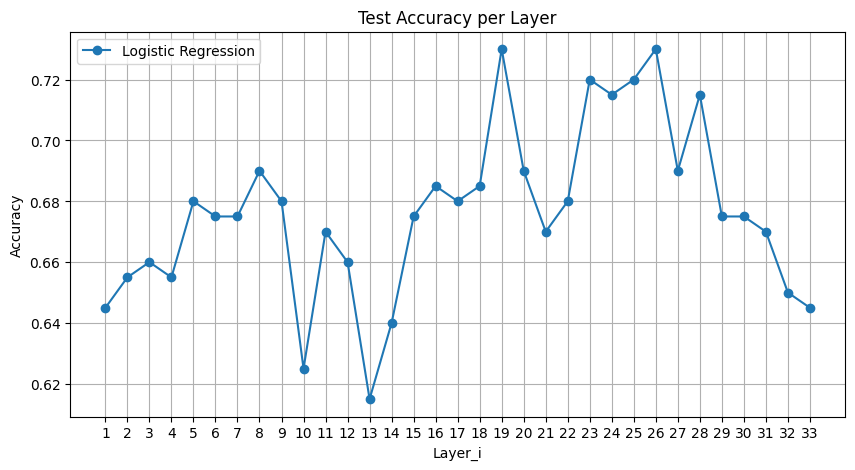

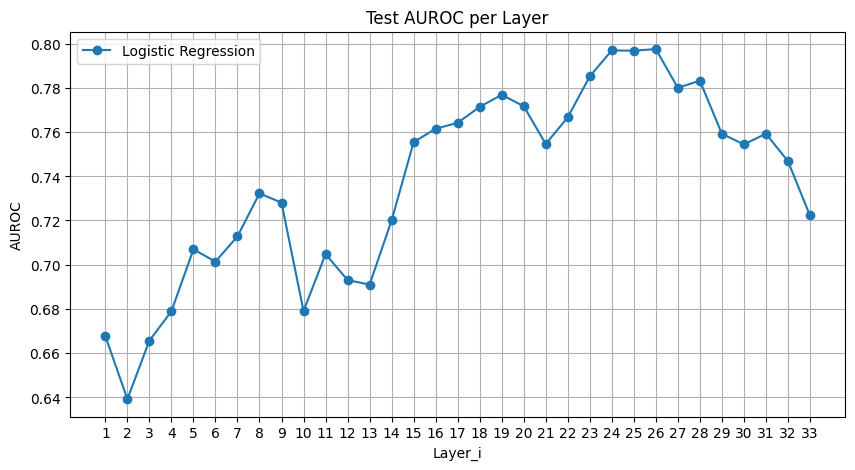

In [458]:
plot_1d_metrics([talr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([talr_test_aucs], ['Logistic Regression'], 'AUROC')

Using device: cuda
Training on TBG-Acc Dataset 1/33
Epoch 1/50, Training Loss: 46.8427, Validation Loss: 37.3835, Training Accuracy: 0.5410
Epoch 10/50, Training Loss: 44.3033, Validation Loss: 37.6839, Training Accuracy: 0.7250
Epoch 20/50, Training Loss: 44.1957, Validation Loss: 37.5855, Training Accuracy: 0.7319
Epoch 30/50, Training Loss: 44.0402, Validation Loss: 37.5735, Training Accuracy: 0.7424
Epoch 40/50, Training Loss: 43.9527, Validation Loss: 37.6951, Training Accuracy: 0.7486
Epoch 50/50, Training Loss: 43.9640, Validation Loss: 37.4190, Training Accuracy: 0.7590
Test Loss: 38.8767, Test Accuracy: 0.5350, AUROC: 0.6076
Training on TBG-Acc Dataset 2/33
Epoch 1/50, Training Loss: 46.6283, Validation Loss: 37.1358, Training Accuracy: 0.5563
Epoch 10/50, Training Loss: 43.9307, Validation Loss: 37.6170, Training Accuracy: 0.7681
Epoch 20/50, Training Loss: 43.6189, Validation Loss: 37.2922, Training Accuracy: 0.7910
Epoch 30/50, Training Loss: 43.7130, Validation Loss: 37.69

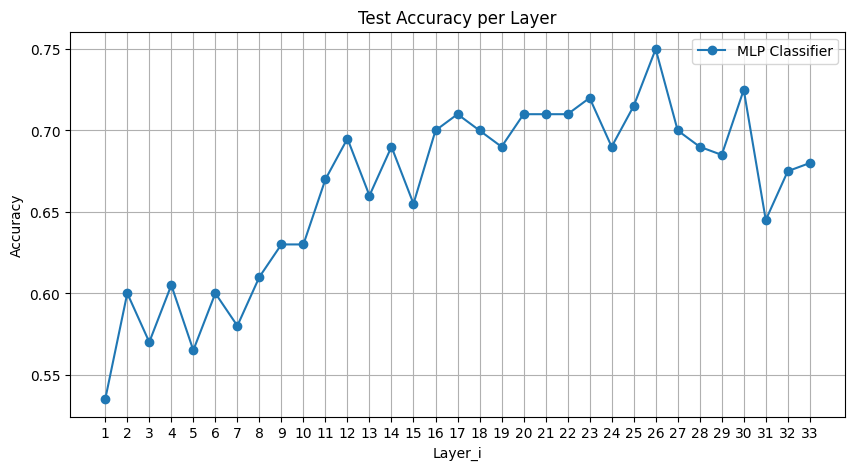

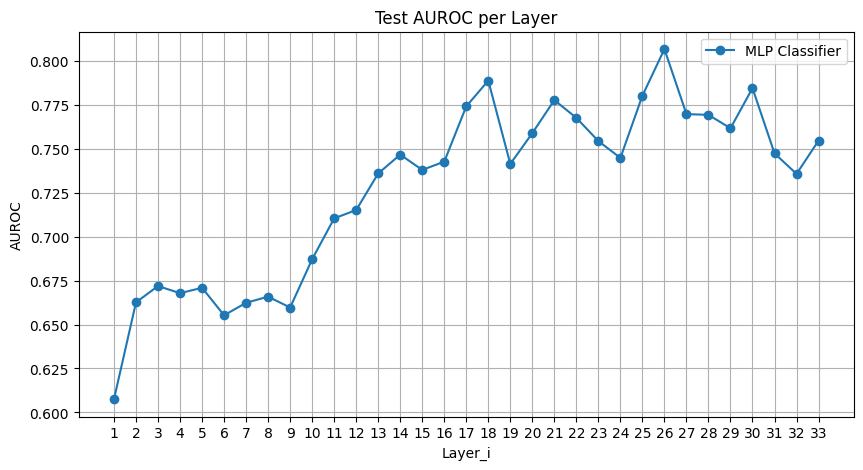

In [459]:
# Training with a single MLP.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50
tamlp_test_accs = []
tamlp_test_aucs = []

for i, (train_loader, valid_loader, test_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(tbg_train_dataloaders)}")
    model = MLPClassifier(in_dim, hid_dims, dropout)
    train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on TBG-Acc Dataset {i+1}", silent=False)
    test_loss, test_acc, test_auc = evaluate_on_test(model, test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tamlp_test_accs.append(test_acc)
    tamlp_test_aucs.append(test_auc)

plot_1d_metrics([tamlp_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([tamlp_test_aucs], ['MLP Classifier'], 'AUROC')

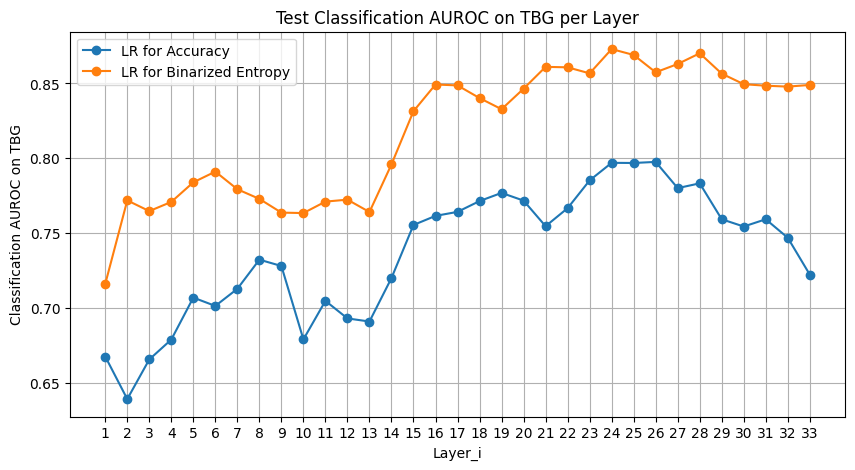

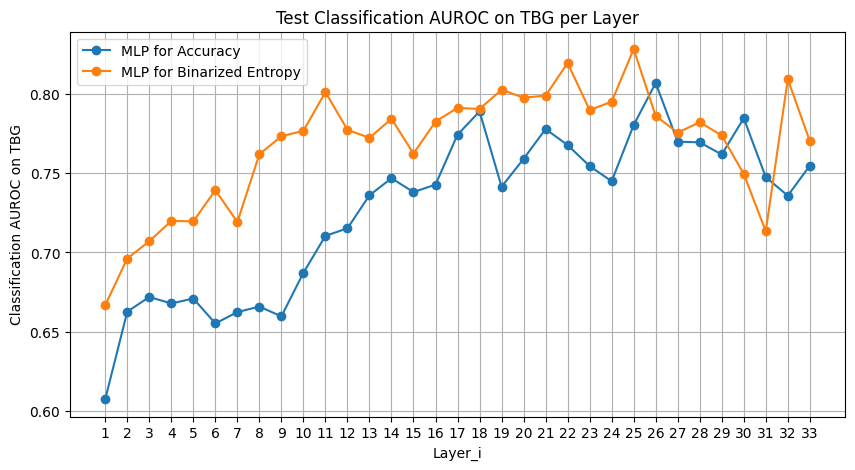

In [462]:
plot_1d_metrics([talr_test_aucs, tblr_test_aucs], ['LR for Accuracy','LR for Binarized Entropy'],
                'Classification AUROC on TBG',
                save_fig=True)

plot_1d_metrics([tamlp_test_aucs, tbmlp_test_aucs], ['MLP for Accuracy','MLP for Binarized Entropy'],
                'Classification AUROC on TBG',
                save_fig=True)

We observe that models achieved better AUROC for predicting binarized SE than for accuracy, with logistic regression performing the best for binary SE (reaching `0.85` AUROC).

### Second Last Generated Token (SLT)

In [463]:
slt_train_dataloaders, slt_valid_dataloaders, slt_test_dataloaders = create_dataloaders(slt_layered_datasets, accuracies, total_size, batch_size)
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, accuracies, total_size)

Training on SLT-Acc Dataset 1/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6528, AUROC: 0.6404
Training Loss: 0.5719, Validation Loss: 0.6449
Test Loss: 0.6461, Test Accuracy: 0.6150, AUROC: 0.6653
Training on SLT-Acc Dataset 2/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6444, AUROC: 0.6385
Training Loss: 0.5378, Validation Loss: 0.6454
Test Loss: 0.6343, Test Accuracy: 0.6400, AUROC: 0.6715
Training on SLT-Acc Dataset 3/32


...

Validation Accuracy: 0.6833, AUROC: 0.7221
Training Loss: 0.0029, Validation Loss: 1.8652
Test Loss: 1.5676, Test Accuracy: 0.6800, AUROC: 0.7572
Training on SLT-Acc Dataset 29/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6833, AUROC: 0.7235
Training Loss: 0.0027, Validation Loss: 1.8481
Test Loss: 1.5786, Test Accuracy: 0.6900, AUROC: 0.7575
Training on SLT-Acc Dataset 30/32
Validation Accuracy: 0.6833, AUROC: 0.7294
Training Loss: 0.0026, Validation Loss: 1.7339
Test Loss: 1.5487, Test Accuracy: 0.6500, AUROC: 0.7577
Training on SLT-Acc Dataset 31/32
Validation Accuracy: 0.6889, AUROC: 0.7260
Training Loss: 0.0026, Validation Loss: 1.7340
Test Loss: 1.4995, Test Accuracy: 0.6700, AUROC: 0.7615
Training on SLT-Acc Dataset 32/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6806, AUROC: 0.7106
Training Loss: 0.0107, Validation Loss: 1.6009
Test Loss: 1.3066, Test Accuracy: 0.7050, AUROC: 0.7599


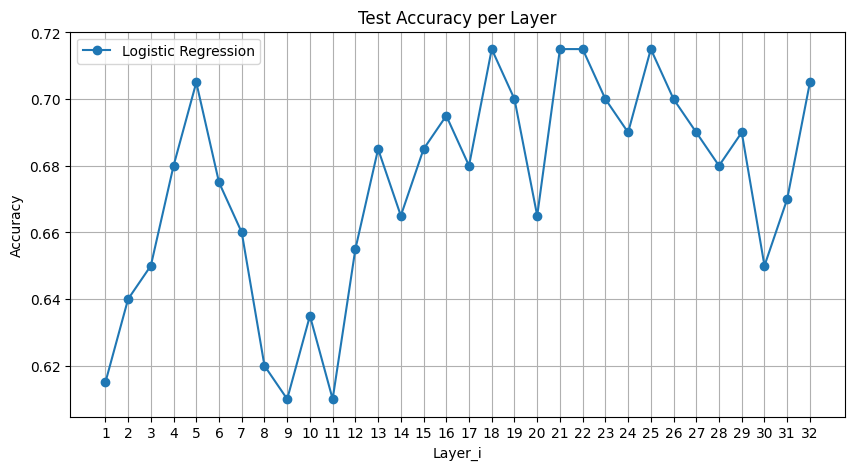

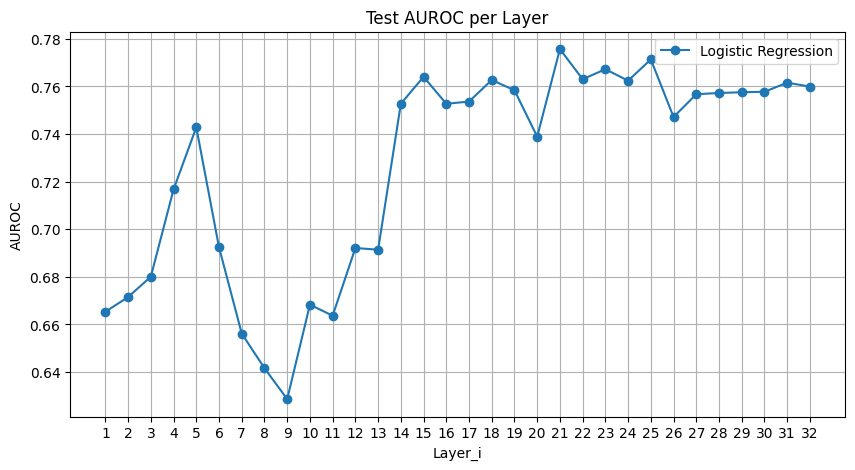

In [464]:
# Training with LR.
salr_test_accs = []
salr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    salr_test_accs.append(test_acc)
    salr_test_aucs.append(test_auc)

plot_1d_metrics([salr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([salr_test_aucs], ['Logistic Regression'], 'AUROC')

Using device: cuda
Training on SLT-Acc Dataset 1/32
Epoch 1/50, Training Loss: 45.9653, Validation Loss: 41.4854, Training Accuracy: 0.5542
Epoch 10/50, Training Loss: 43.6093, Validation Loss: 41.3719, Training Accuracy: 0.7410
Epoch 20/50, Training Loss: 42.5497, Validation Loss: 41.2243, Training Accuracy: 0.8215
Epoch 30/50, Training Loss: 42.1382, Validation Loss: 41.4390, Training Accuracy: 0.8569
Epoch 40/50, Training Loss: 41.7135, Validation Loss: 41.2938, Training Accuracy: 0.8875
Epoch 50/50, Training Loss: 41.4886, Validation Loss: 41.5113, Training Accuracy: 0.8986


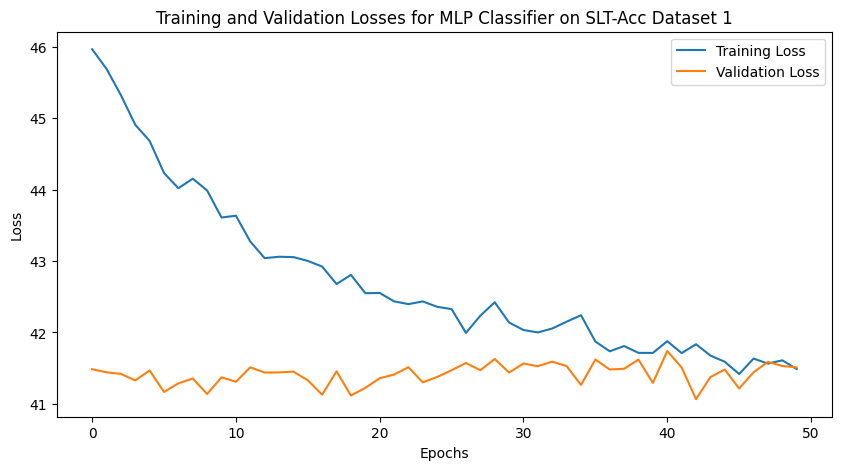

Test Loss: 37.8429, Test Accuracy: 0.6200, AUROC: 0.6733
Training on SLT-Acc Dataset 2/32
Epoch 1/50, Training Loss: 46.1340, Validation Loss: 41.4374, Training Accuracy: 0.5368
Epoch 10/50, Training Loss: 43.5878, Validation Loss: 41.5324, Training Accuracy: 0.7535
Epoch 20/50, Training Loss: 42.5740, Validation Loss: 41.4198, Training Accuracy: 0.8222
Epoch 30/50, Training Loss: 42.0585, Validation Loss: 41.4937, Training Accuracy: 0.8618
Epoch 40/50, Training Loss: 41.7574, Validation Loss: 41.5945, Training Accuracy: 0.8833
Epoch 50/50, Training Loss: 41.5914, Validation Loss: 41.9065, Training Accuracy: 0.8979


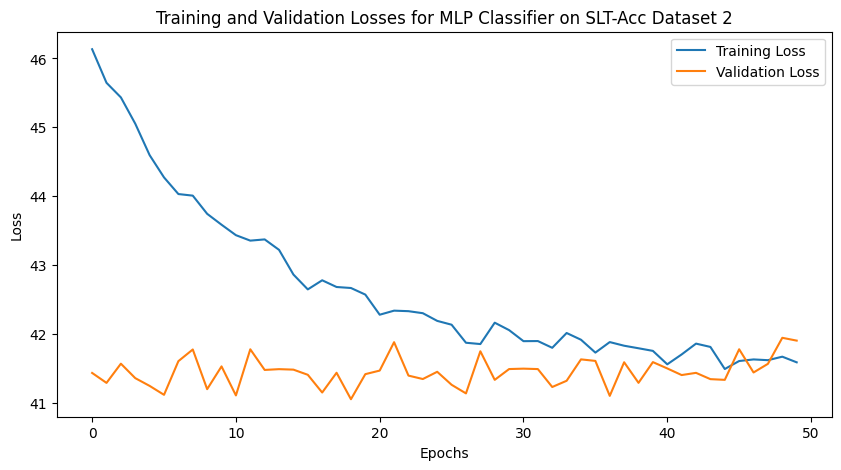

Test Loss: 37.3456, Test Accuracy: 0.6550, AUROC: 0.6897
Training on SLT-Acc Dataset 3/32
Epoch 1/50, Training Loss: 46.0633, Validation Loss: 41.4637, Training Accuracy: 0.5201
Epoch 10/50, Training Loss: 43.0815, Validation Loss: 41.5627, Training Accuracy: 0.7806
Epoch 20/50, Training Loss: 41.9905, Validation Loss: 41.5099, Training Accuracy: 0.8701
Epoch 30/50, Training Loss: 41.6054, Validation Loss: 41.8441, Training Accuracy: 0.8896
Epoch 40/50, Training Loss: 41.3227, Validation Loss: 41.5746, Training Accuracy: 0.9139
Epoch 50/50, Training Loss: 41.2912, Validation Loss: 41.4278, Training Accuracy: 0.9153


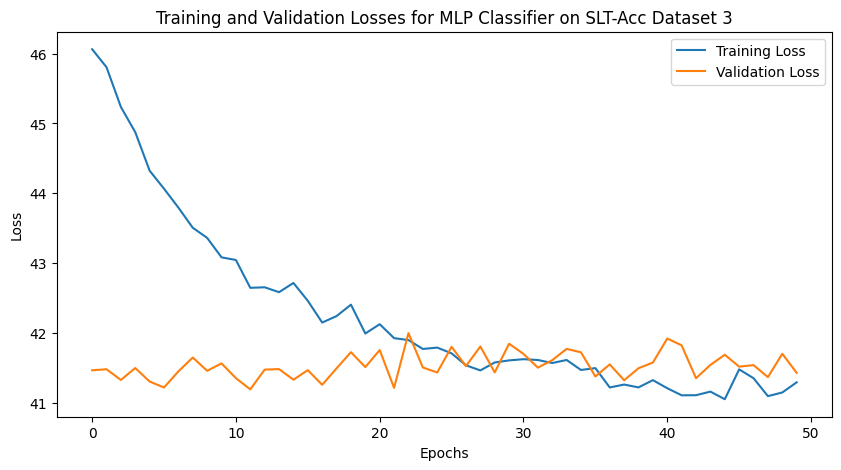

Test Loss: 37.5656, Test Accuracy: 0.5500, AUROC: 0.6781
Training on SLT-Acc Dataset 4/32
Epoch 1/50, Training Loss: 46.1189, Validation Loss: 41.4643, Training Accuracy: 0.5056
Epoch 10/50, Training Loss: 42.9548, Validation Loss: 41.4714, Training Accuracy: 0.7993
Epoch 20/50, Training Loss: 41.6330, Validation Loss: 41.2780, Training Accuracy: 0.8944
Epoch 30/50, Training Loss: 41.4468, Validation Loss: 41.5235, Training Accuracy: 0.9069
Epoch 40/50, Training Loss: 41.1211, Validation Loss: 41.5310, Training Accuracy: 0.9340
Epoch 50/50, Training Loss: 40.9655, Validation Loss: 41.2023, Training Accuracy: 0.9368


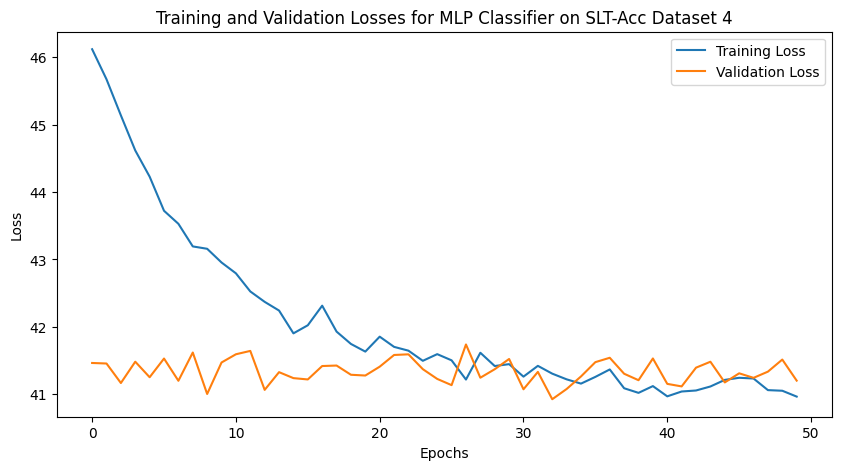

Test Loss: 37.5777, Test Accuracy: 0.6550, AUROC: 0.6577
Training on SLT-Acc Dataset 5/32
Epoch 1/50, Training Loss: 46.1364, Validation Loss: 41.3160, Training Accuracy: 0.5354
Epoch 10/50, Training Loss: 42.7340, Validation Loss: 40.7668, Training Accuracy: 0.8132
Epoch 20/50, Training Loss: 41.5270, Validation Loss: 40.6993, Training Accuracy: 0.8979
Epoch 30/50, Training Loss: 41.2078, Validation Loss: 41.3486, Training Accuracy: 0.9201
Epoch 40/50, Training Loss: 41.0085, Validation Loss: 40.7819, Training Accuracy: 0.9333
Epoch 50/50, Training Loss: 40.9533, Validation Loss: 40.9883, Training Accuracy: 0.9403


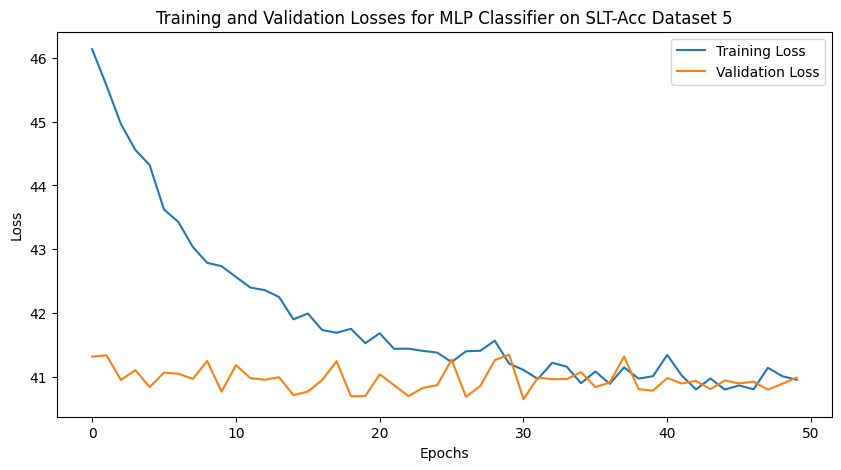

Test Loss: 37.6280, Test Accuracy: 0.5800, AUROC: 0.6618
Training on SLT-Acc Dataset 6/32
Epoch 1/50, Training Loss: 46.0936, Validation Loss: 41.6547, Training Accuracy: 0.5396
Epoch 10/50, Training Loss: 42.4941, Validation Loss: 41.0402, Training Accuracy: 0.8271
Epoch 20/50, Training Loss: 41.5790, Validation Loss: 41.2520, Training Accuracy: 0.8924
Epoch 30/50, Training Loss: 41.1758, Validation Loss: 40.9901, Training Accuracy: 0.9243
Epoch 40/50, Training Loss: 40.9379, Validation Loss: 40.9704, Training Accuracy: 0.9389
Epoch 50/50, Training Loss: 41.0183, Validation Loss: 41.0019, Training Accuracy: 0.9340


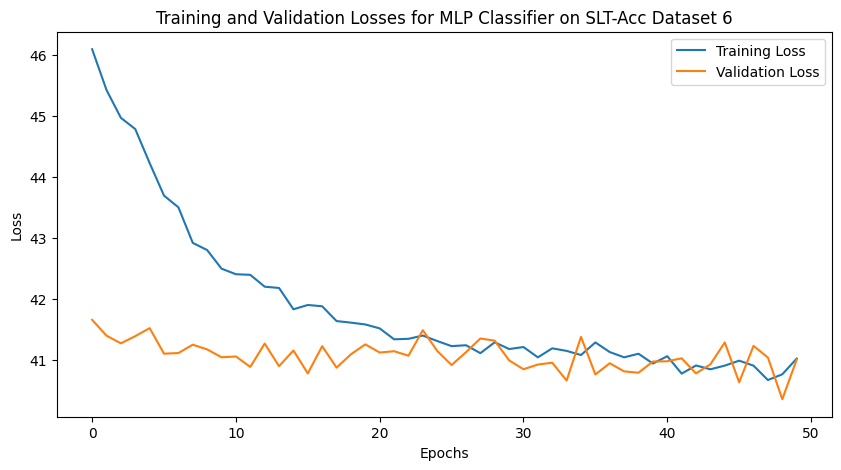

Test Loss: 36.9061, Test Accuracy: 0.6650, AUROC: 0.6989
Training on SLT-Acc Dataset 7/32
Epoch 1/50, Training Loss: 46.0698, Validation Loss: 41.1643, Training Accuracy: 0.5215
Epoch 10/50, Training Loss: 42.5312, Validation Loss: 40.5994, Training Accuracy: 0.8292
Epoch 20/50, Training Loss: 41.3166, Validation Loss: 40.8167, Training Accuracy: 0.9153
Epoch 30/50, Training Loss: 41.2224, Validation Loss: 40.5555, Training Accuracy: 0.9201
Epoch 40/50, Training Loss: 40.8255, Validation Loss: 40.6416, Training Accuracy: 0.9500
Epoch 50/50, Training Loss: 40.6987, Validation Loss: 40.9231, Training Accuracy: 0.9542


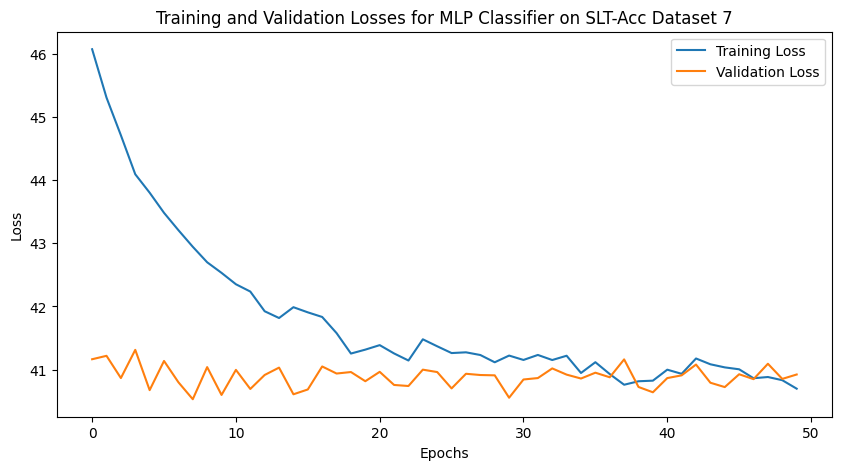

Test Loss: 37.7895, Test Accuracy: 0.6300, AUROC: 0.6695
Training on SLT-Acc Dataset 8/32
Epoch 1/50, Training Loss: 45.8989, Validation Loss: 41.1413, Training Accuracy: 0.5813
Epoch 10/50, Training Loss: 42.2454, Validation Loss: 41.0540, Training Accuracy: 0.8542
Epoch 20/50, Training Loss: 41.4205, Validation Loss: 41.0676, Training Accuracy: 0.9062
Epoch 30/50, Training Loss: 41.0528, Validation Loss: 40.8079, Training Accuracy: 0.9313
Epoch 40/50, Training Loss: 40.8800, Validation Loss: 40.9984, Training Accuracy: 0.9479
Epoch 50/50, Training Loss: 40.9608, Validation Loss: 40.7752, Training Accuracy: 0.9389


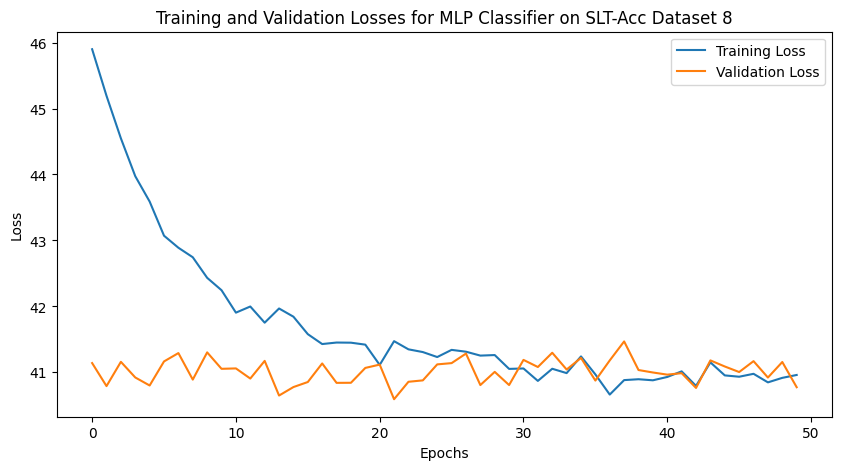

Test Loss: 37.8323, Test Accuracy: 0.6250, AUROC: 0.6208
Training on SLT-Acc Dataset 9/32
Epoch 1/50, Training Loss: 45.9675, Validation Loss: 41.4976, Training Accuracy: 0.5632
Epoch 10/50, Training Loss: 42.4721, Validation Loss: 41.0543, Training Accuracy: 0.8313
Epoch 20/50, Training Loss: 41.6813, Validation Loss: 41.3873, Training Accuracy: 0.8847
Epoch 30/50, Training Loss: 41.2131, Validation Loss: 41.3529, Training Accuracy: 0.9208
Epoch 40/50, Training Loss: 41.1012, Validation Loss: 41.0546, Training Accuracy: 0.9306
Epoch 50/50, Training Loss: 40.9154, Validation Loss: 40.9833, Training Accuracy: 0.9403


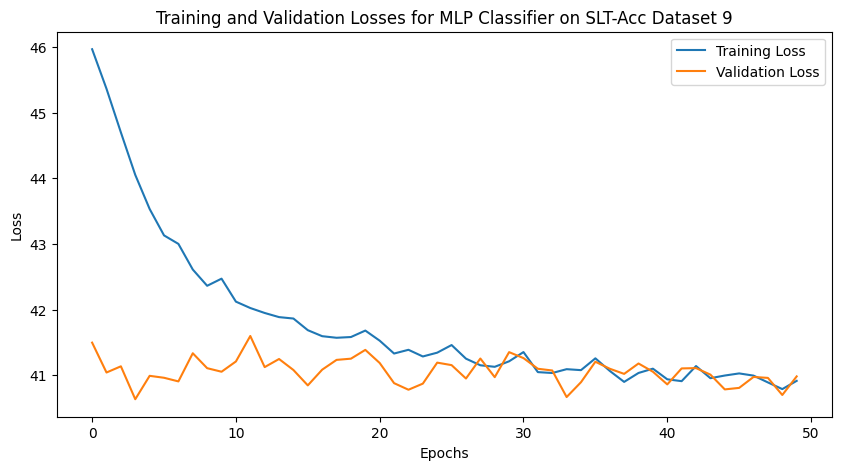

Test Loss: 37.2900, Test Accuracy: 0.6200, AUROC: 0.7048
Training on SLT-Acc Dataset 10/32
Epoch 1/50, Training Loss: 45.7907, Validation Loss: 40.9639, Training Accuracy: 0.5215
Epoch 10/50, Training Loss: 42.2734, Validation Loss: 40.8438, Training Accuracy: 0.8403
Epoch 20/50, Training Loss: 41.2440, Validation Loss: 41.3049, Training Accuracy: 0.9160
Epoch 30/50, Training Loss: 40.9301, Validation Loss: 40.7148, Training Accuracy: 0.9389
Epoch 40/50, Training Loss: 40.9710, Validation Loss: 41.0929, Training Accuracy: 0.9410
Epoch 50/50, Training Loss: 40.6789, Validation Loss: 41.0820, Training Accuracy: 0.9556


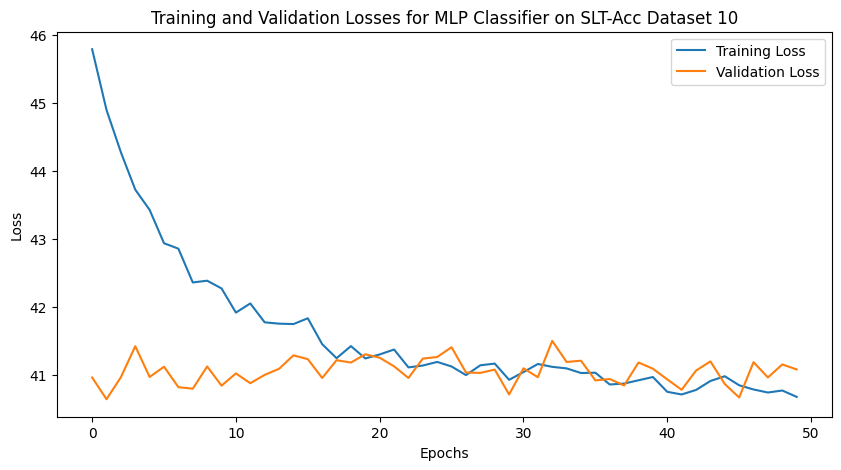

Test Loss: 37.2001, Test Accuracy: 0.6200, AUROC: 0.6925
Training on SLT-Acc Dataset 11/32
Epoch 1/50, Training Loss: 45.7672, Validation Loss: 40.9920, Training Accuracy: 0.5743
Epoch 10/50, Training Loss: 42.2476, Validation Loss: 41.2782, Training Accuracy: 0.8438
Epoch 20/50, Training Loss: 41.0218, Validation Loss: 40.9846, Training Accuracy: 0.9326
Epoch 30/50, Training Loss: 40.9486, Validation Loss: 41.0330, Training Accuracy: 0.9368
Epoch 40/50, Training Loss: 41.0433, Validation Loss: 40.5723, Training Accuracy: 0.9340
Epoch 50/50, Training Loss: 40.9052, Validation Loss: 41.2210, Training Accuracy: 0.9451


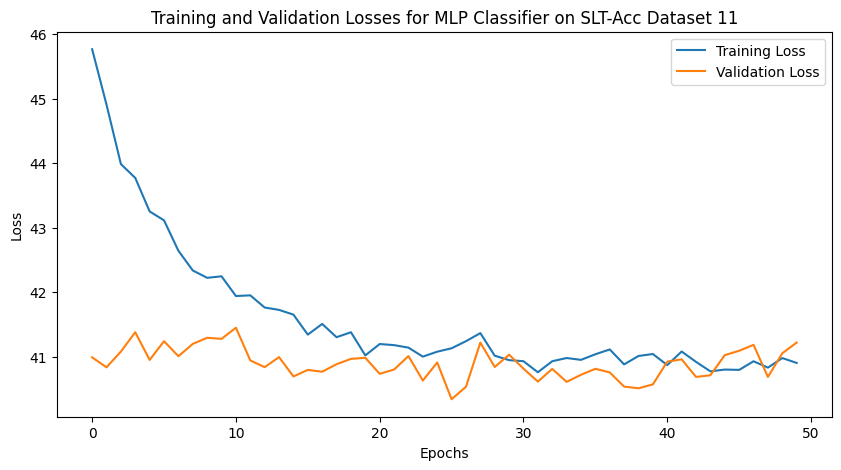

Test Loss: 37.1226, Test Accuracy: 0.6700, AUROC: 0.6969
Training on SLT-Acc Dataset 12/32
Epoch 1/50, Training Loss: 45.8245, Validation Loss: 40.7578, Training Accuracy: 0.5674
Epoch 10/50, Training Loss: 41.8864, Validation Loss: 40.7360, Training Accuracy: 0.8785
Epoch 20/50, Training Loss: 40.9899, Validation Loss: 41.2275, Training Accuracy: 0.9326
Epoch 30/50, Training Loss: 40.9417, Validation Loss: 40.9427, Training Accuracy: 0.9382
Epoch 40/50, Training Loss: 40.8106, Validation Loss: 41.1855, Training Accuracy: 0.9521
Epoch 50/50, Training Loss: 40.5990, Validation Loss: 40.7506, Training Accuracy: 0.9653


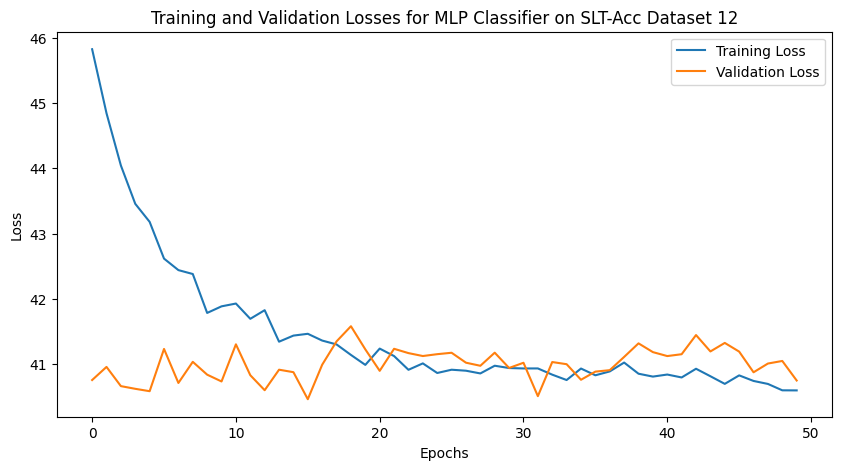

Test Loss: 37.6513, Test Accuracy: 0.6650, AUROC: 0.6649
Training on SLT-Acc Dataset 13/32
Epoch 1/50, Training Loss: 45.6364, Validation Loss: 40.5103, Training Accuracy: 0.5847
Epoch 10/50, Training Loss: 41.7502, Validation Loss: 40.4522, Training Accuracy: 0.8889
Epoch 20/50, Training Loss: 41.1703, Validation Loss: 40.8002, Training Accuracy: 0.9278
Epoch 30/50, Training Loss: 40.9283, Validation Loss: 40.7155, Training Accuracy: 0.9417
Epoch 40/50, Training Loss: 40.7657, Validation Loss: 40.8908, Training Accuracy: 0.9542
Epoch 50/50, Training Loss: 40.9141, Validation Loss: 40.5346, Training Accuracy: 0.9437


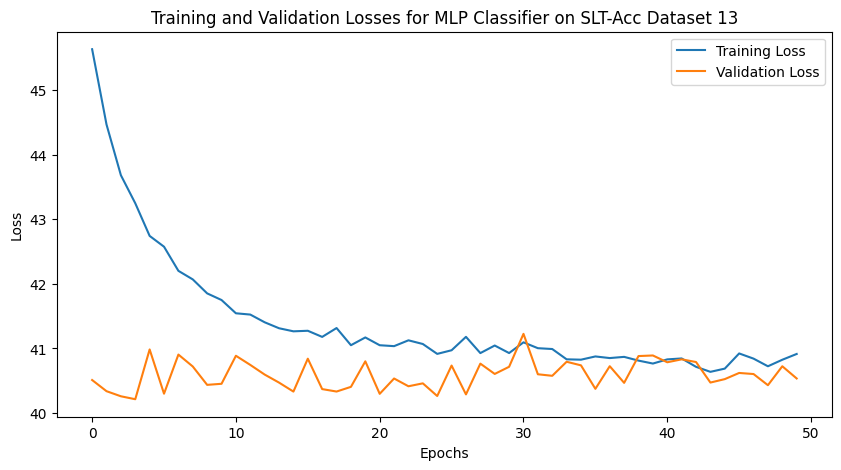

Test Loss: 37.0361, Test Accuracy: 0.6500, AUROC: 0.7059
Training on SLT-Acc Dataset 14/32
Epoch 1/50, Training Loss: 45.5638, Validation Loss: 40.2697, Training Accuracy: 0.5868
Epoch 10/50, Training Loss: 41.1822, Validation Loss: 40.6616, Training Accuracy: 0.9250
Epoch 20/50, Training Loss: 40.8938, Validation Loss: 40.8018, Training Accuracy: 0.9403
Epoch 30/50, Training Loss: 40.6961, Validation Loss: 40.5730, Training Accuracy: 0.9556
Epoch 40/50, Training Loss: 40.7032, Validation Loss: 40.9302, Training Accuracy: 0.9618
Epoch 50/50, Training Loss: 40.6421, Validation Loss: 40.9876, Training Accuracy: 0.9597


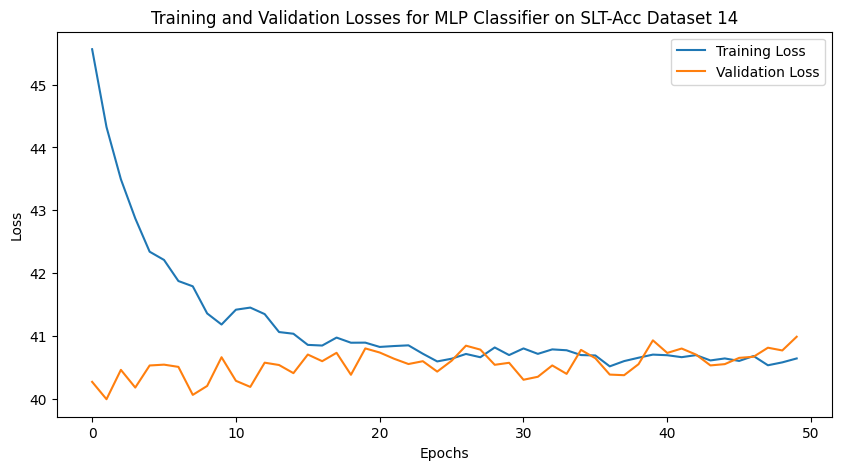

Test Loss: 37.1391, Test Accuracy: 0.6550, AUROC: 0.6906
Training on SLT-Acc Dataset 15/32
Epoch 1/50, Training Loss: 45.5149, Validation Loss: 40.0724, Training Accuracy: 0.5854
Epoch 10/50, Training Loss: 41.2863, Validation Loss: 40.7223, Training Accuracy: 0.9146
Epoch 20/50, Training Loss: 40.8595, Validation Loss: 40.3835, Training Accuracy: 0.9472
Epoch 30/50, Training Loss: 40.5946, Validation Loss: 39.9499, Training Accuracy: 0.9646
Epoch 40/50, Training Loss: 40.5083, Validation Loss: 40.4265, Training Accuracy: 0.9674
Epoch 50/50, Training Loss: 40.4897, Validation Loss: 40.6049, Training Accuracy: 0.9688


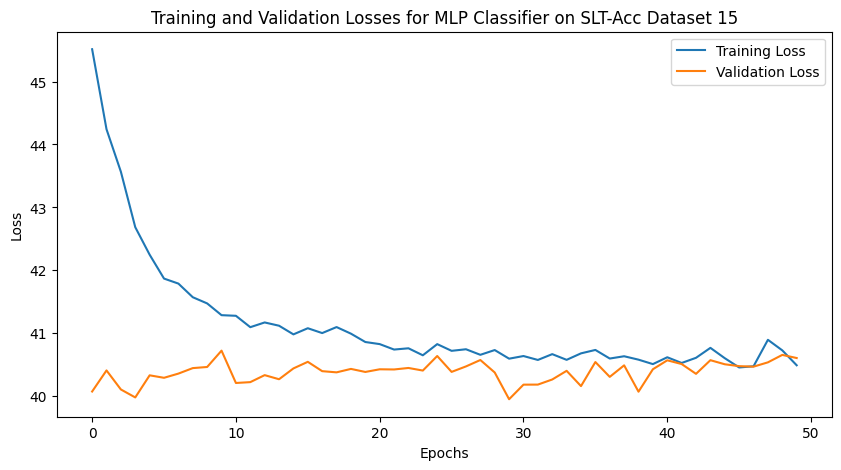

Test Loss: 37.0218, Test Accuracy: 0.6950, AUROC: 0.7191
Training on SLT-Acc Dataset 16/32
Epoch 1/50, Training Loss: 45.3070, Validation Loss: 40.0692, Training Accuracy: 0.6083
Epoch 10/50, Training Loss: 41.1831, Validation Loss: 40.4616, Training Accuracy: 0.9264
Epoch 20/50, Training Loss: 40.7643, Validation Loss: 40.4006, Training Accuracy: 0.9590
Epoch 30/50, Training Loss: 40.5584, Validation Loss: 40.5387, Training Accuracy: 0.9674
Epoch 40/50, Training Loss: 40.6265, Validation Loss: 40.4176, Training Accuracy: 0.9611
Epoch 50/50, Training Loss: 40.5519, Validation Loss: 40.3508, Training Accuracy: 0.9674


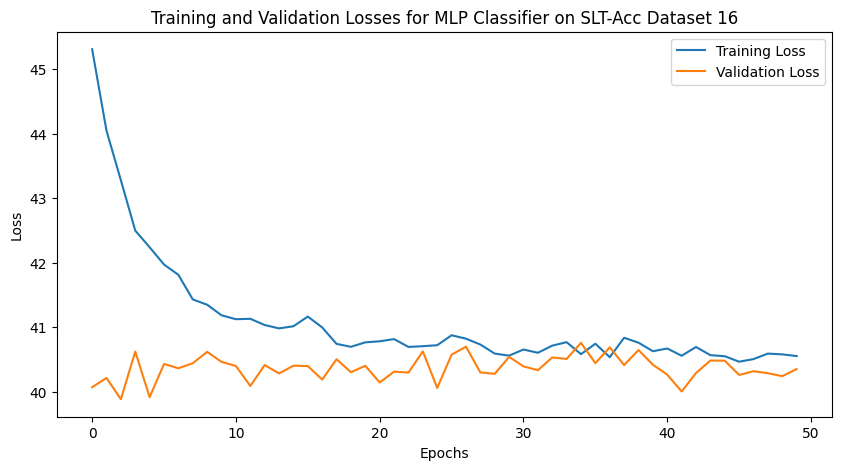

Test Loss: 36.8641, Test Accuracy: 0.6650, AUROC: 0.7359
Training on SLT-Acc Dataset 17/32
Epoch 1/50, Training Loss: 45.2862, Validation Loss: 40.2408, Training Accuracy: 0.5896
Epoch 10/50, Training Loss: 41.3322, Validation Loss: 39.9142, Training Accuracy: 0.9160
Epoch 20/50, Training Loss: 40.6915, Validation Loss: 39.9830, Training Accuracy: 0.9590
Epoch 30/50, Training Loss: 40.8478, Validation Loss: 39.9247, Training Accuracy: 0.9465
Epoch 40/50, Training Loss: 40.4907, Validation Loss: 40.2092, Training Accuracy: 0.9681
Epoch 50/50, Training Loss: 40.4034, Validation Loss: 40.1760, Training Accuracy: 0.9785


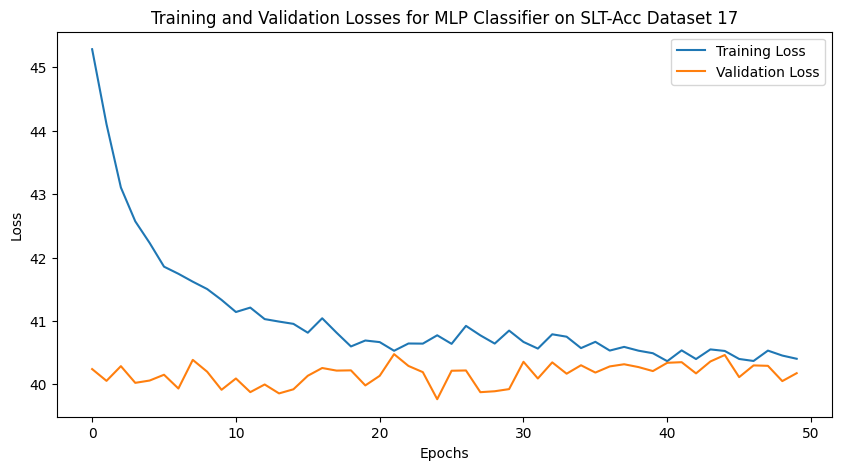

Test Loss: 36.7160, Test Accuracy: 0.7200, AUROC: 0.7136
Training on SLT-Acc Dataset 18/32
Epoch 1/50, Training Loss: 45.3335, Validation Loss: 40.1225, Training Accuracy: 0.6188
Epoch 10/50, Training Loss: 41.0029, Validation Loss: 40.4019, Training Accuracy: 0.9375
Epoch 20/50, Training Loss: 40.7341, Validation Loss: 40.5018, Training Accuracy: 0.9611
Epoch 30/50, Training Loss: 40.4930, Validation Loss: 40.4098, Training Accuracy: 0.9701
Epoch 40/50, Training Loss: 40.4552, Validation Loss: 40.5269, Training Accuracy: 0.9729
Epoch 50/50, Training Loss: 40.3644, Validation Loss: 40.4585, Training Accuracy: 0.9778


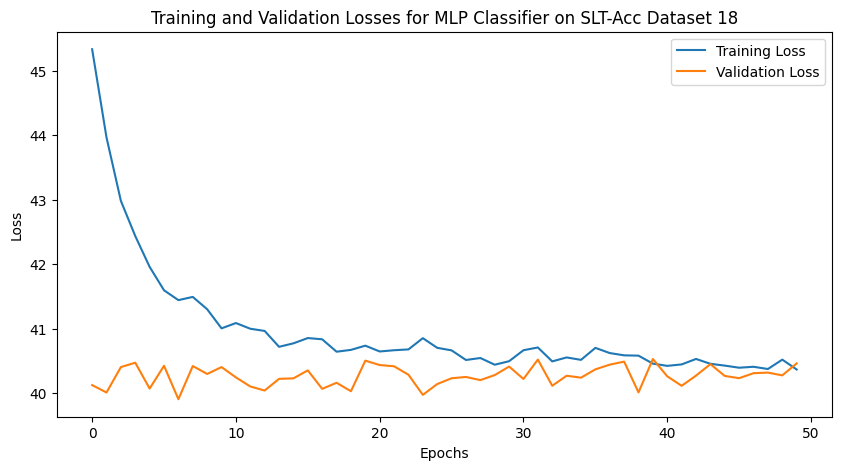

Test Loss: 37.1389, Test Accuracy: 0.6700, AUROC: 0.6867
Training on SLT-Acc Dataset 19/32
Epoch 1/50, Training Loss: 45.2611, Validation Loss: 39.8569, Training Accuracy: 0.6160
Epoch 10/50, Training Loss: 40.8646, Validation Loss: 40.2575, Training Accuracy: 0.9493
Epoch 20/50, Training Loss: 40.6819, Validation Loss: 40.6103, Training Accuracy: 0.9549
Epoch 30/50, Training Loss: 40.6419, Validation Loss: 39.7935, Training Accuracy: 0.9660
Epoch 40/50, Training Loss: 40.3733, Validation Loss: 40.2028, Training Accuracy: 0.9792
Epoch 50/50, Training Loss: 40.4535, Validation Loss: 40.1756, Training Accuracy: 0.9743


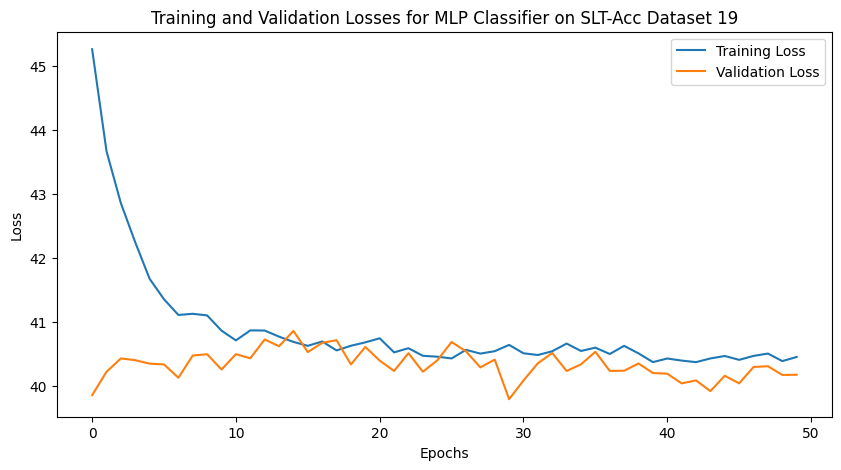

Test Loss: 36.9371, Test Accuracy: 0.6750, AUROC: 0.7312
Training on SLT-Acc Dataset 20/32
Epoch 1/50, Training Loss: 45.3803, Validation Loss: 40.3032, Training Accuracy: 0.5819
Epoch 10/50, Training Loss: 40.8503, Validation Loss: 40.3959, Training Accuracy: 0.9507
Epoch 20/50, Training Loss: 40.6556, Validation Loss: 40.3779, Training Accuracy: 0.9604
Epoch 30/50, Training Loss: 40.4291, Validation Loss: 40.3398, Training Accuracy: 0.9764
Epoch 40/50, Training Loss: 40.4214, Validation Loss: 40.4923, Training Accuracy: 0.9792
Epoch 50/50, Training Loss: 40.5090, Validation Loss: 40.3007, Training Accuracy: 0.9701


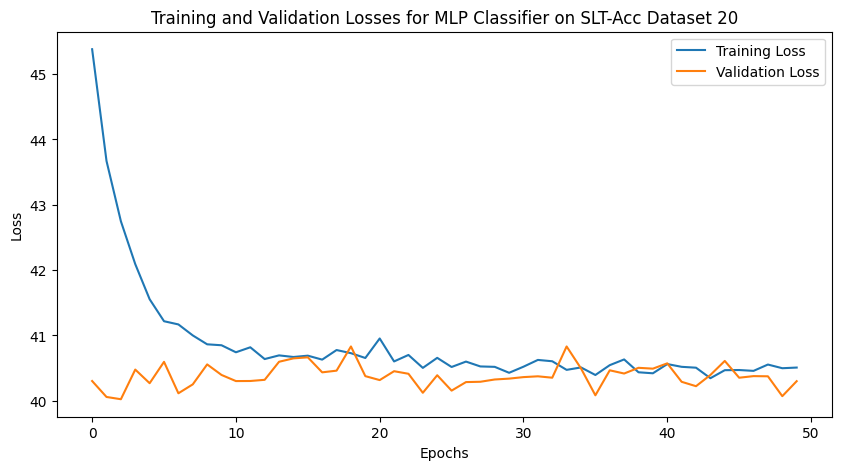

Test Loss: 37.3765, Test Accuracy: 0.6400, AUROC: 0.7144
Training on SLT-Acc Dataset 21/32
Epoch 1/50, Training Loss: 45.2424, Validation Loss: 39.9908, Training Accuracy: 0.6285
Epoch 10/50, Training Loss: 40.9579, Validation Loss: 40.4680, Training Accuracy: 0.9424
Epoch 20/50, Training Loss: 40.6816, Validation Loss: 40.0998, Training Accuracy: 0.9563
Epoch 30/50, Training Loss: 40.4754, Validation Loss: 40.5516, Training Accuracy: 0.9708
Epoch 40/50, Training Loss: 40.5110, Validation Loss: 40.3200, Training Accuracy: 0.9750
Epoch 50/50, Training Loss: 40.4314, Validation Loss: 40.3182, Training Accuracy: 0.9771


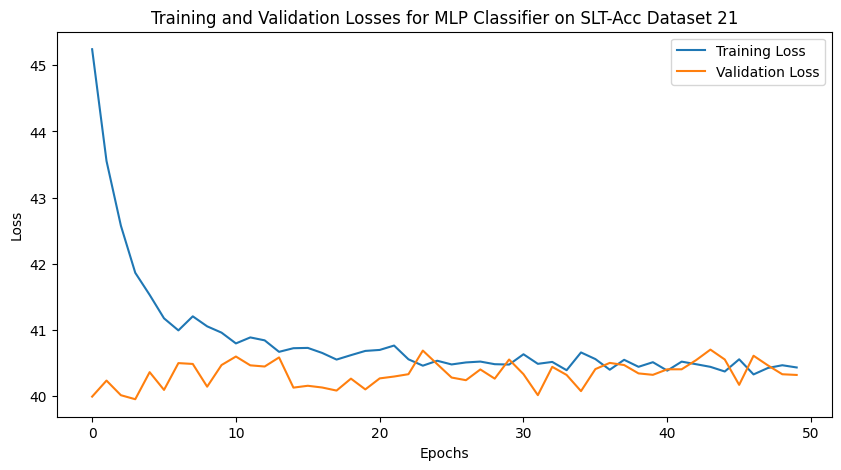

Test Loss: 36.9737, Test Accuracy: 0.6750, AUROC: 0.7345
Training on SLT-Acc Dataset 22/32
Epoch 1/50, Training Loss: 45.3608, Validation Loss: 40.1405, Training Accuracy: 0.6021
Epoch 10/50, Training Loss: 40.8981, Validation Loss: 40.4008, Training Accuracy: 0.9486
Epoch 20/50, Training Loss: 40.6514, Validation Loss: 39.9146, Training Accuracy: 0.9604
Epoch 30/50, Training Loss: 40.4501, Validation Loss: 40.4342, Training Accuracy: 0.9736
Epoch 40/50, Training Loss: 40.4947, Validation Loss: 40.2508, Training Accuracy: 0.9715
Epoch 50/50, Training Loss: 40.5221, Validation Loss: 40.3867, Training Accuracy: 0.9681


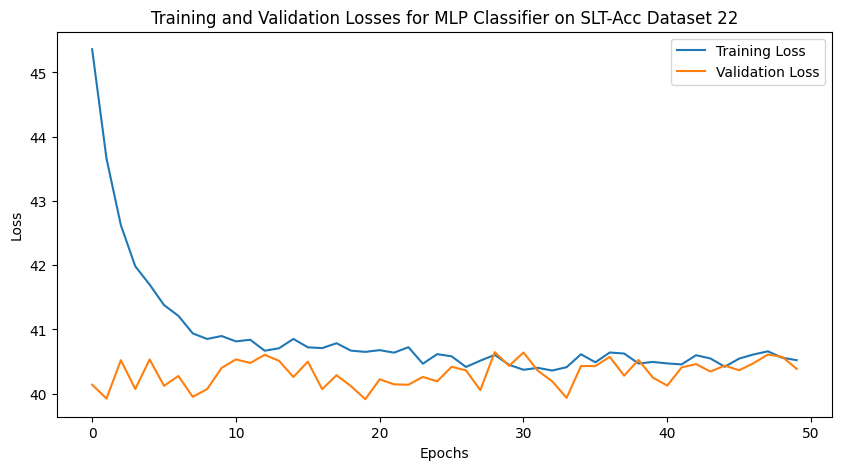

Test Loss: 36.3337, Test Accuracy: 0.7300, AUROC: 0.7622
Training on SLT-Acc Dataset 23/32
Epoch 1/50, Training Loss: 45.3018, Validation Loss: 40.0156, Training Accuracy: 0.6271
Epoch 10/50, Training Loss: 40.8531, Validation Loss: 40.0612, Training Accuracy: 0.9500
Epoch 20/50, Training Loss: 40.6796, Validation Loss: 40.2941, Training Accuracy: 0.9618
Epoch 30/50, Training Loss: 40.6222, Validation Loss: 40.1475, Training Accuracy: 0.9639
Epoch 40/50, Training Loss: 40.6123, Validation Loss: 40.3032, Training Accuracy: 0.9653
Epoch 50/50, Training Loss: 40.4350, Validation Loss: 40.3461, Training Accuracy: 0.9729


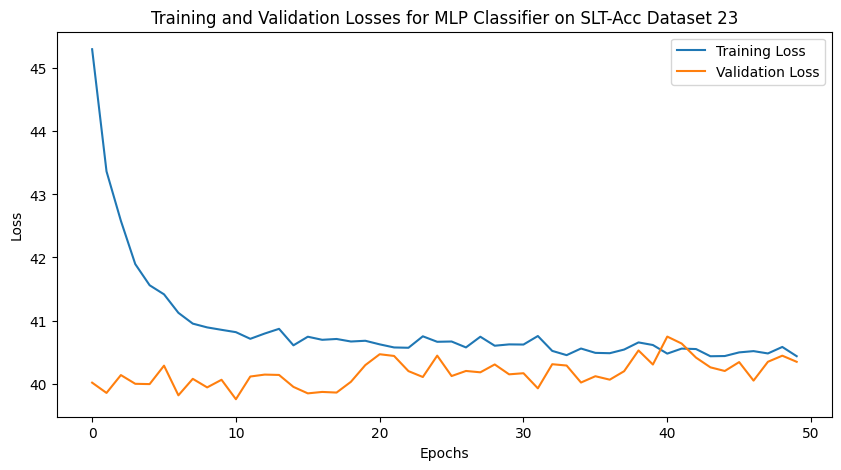

Test Loss: 36.8939, Test Accuracy: 0.6700, AUROC: 0.7291
Training on SLT-Acc Dataset 24/32
Epoch 1/50, Training Loss: 45.1272, Validation Loss: 40.1173, Training Accuracy: 0.6417
Epoch 10/50, Training Loss: 40.9918, Validation Loss: 39.8826, Training Accuracy: 0.9417
Epoch 20/50, Training Loss: 40.7821, Validation Loss: 40.4002, Training Accuracy: 0.9542
Epoch 30/50, Training Loss: 40.5244, Validation Loss: 40.5841, Training Accuracy: 0.9736
Epoch 40/50, Training Loss: 40.4907, Validation Loss: 40.6458, Training Accuracy: 0.9729
Epoch 50/50, Training Loss: 40.5565, Validation Loss: 40.5822, Training Accuracy: 0.9688


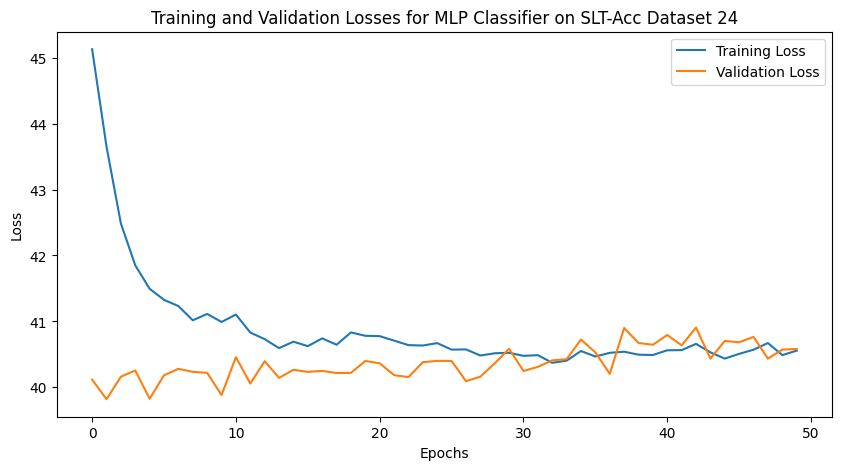

Test Loss: 36.7162, Test Accuracy: 0.7150, AUROC: 0.7478
Training on SLT-Acc Dataset 25/32
Epoch 1/50, Training Loss: 45.3584, Validation Loss: 40.1654, Training Accuracy: 0.5986
Epoch 10/50, Training Loss: 40.9744, Validation Loss: 40.3063, Training Accuracy: 0.9382
Epoch 20/50, Training Loss: 40.6383, Validation Loss: 40.2809, Training Accuracy: 0.9611
Epoch 30/50, Training Loss: 40.5531, Validation Loss: 40.3887, Training Accuracy: 0.9674
Epoch 40/50, Training Loss: 40.6009, Validation Loss: 40.6423, Training Accuracy: 0.9639
Epoch 50/50, Training Loss: 40.4717, Validation Loss: 40.2352, Training Accuracy: 0.9778


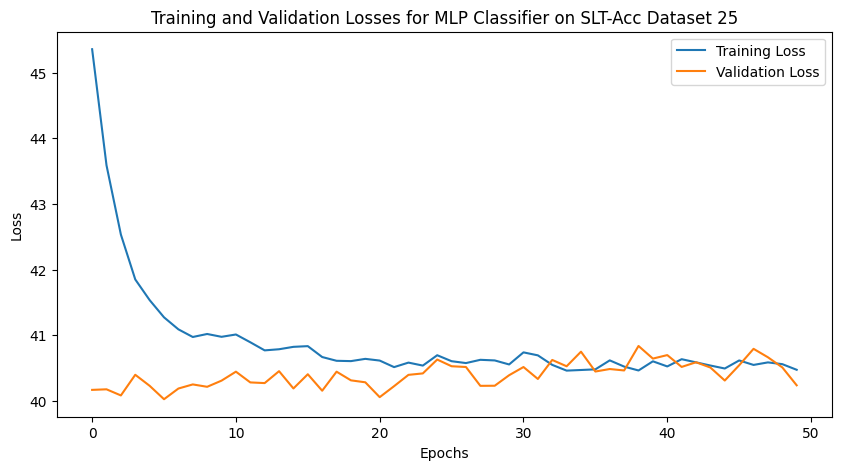

Test Loss: 36.7920, Test Accuracy: 0.6800, AUROC: 0.7514
Training on SLT-Acc Dataset 26/32
Epoch 1/50, Training Loss: 45.2972, Validation Loss: 40.2006, Training Accuracy: 0.6181
Epoch 10/50, Training Loss: 40.9423, Validation Loss: 40.4495, Training Accuracy: 0.9424
Epoch 20/50, Training Loss: 40.5594, Validation Loss: 40.2130, Training Accuracy: 0.9660
Epoch 30/50, Training Loss: 40.4459, Validation Loss: 40.7453, Training Accuracy: 0.9743
Epoch 40/50, Training Loss: 40.4374, Validation Loss: 40.4426, Training Accuracy: 0.9736
Epoch 50/50, Training Loss: 40.3910, Validation Loss: 40.4853, Training Accuracy: 0.9792


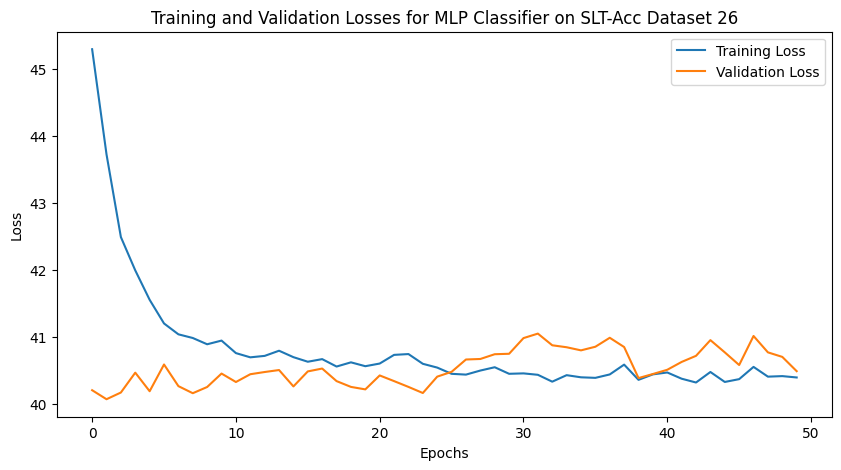

Test Loss: 36.6855, Test Accuracy: 0.6800, AUROC: 0.7292
Training on SLT-Acc Dataset 27/32
Epoch 1/50, Training Loss: 45.2681, Validation Loss: 40.4001, Training Accuracy: 0.6083
Epoch 10/50, Training Loss: 40.8939, Validation Loss: 40.6450, Training Accuracy: 0.9500
Epoch 20/50, Training Loss: 40.5089, Validation Loss: 40.4641, Training Accuracy: 0.9708
Epoch 30/50, Training Loss: 40.4419, Validation Loss: 40.5437, Training Accuracy: 0.9778
Epoch 40/50, Training Loss: 40.4253, Validation Loss: 40.2979, Training Accuracy: 0.9750
Epoch 50/50, Training Loss: 40.4126, Validation Loss: 40.6485, Training Accuracy: 0.9764


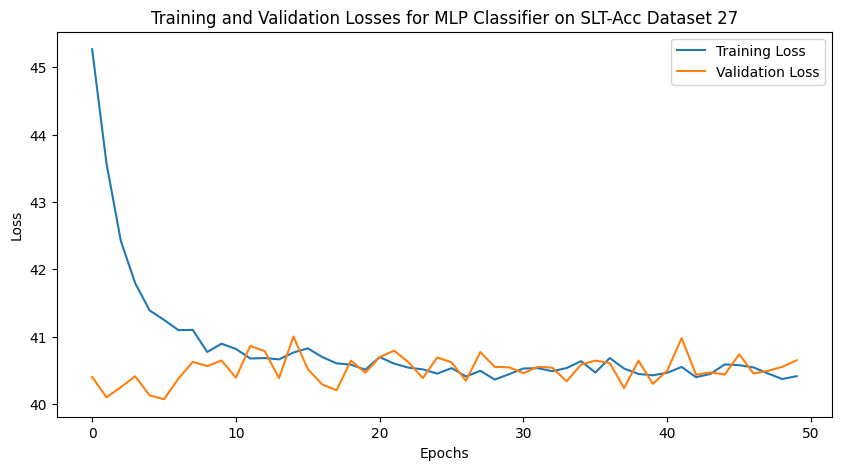

Test Loss: 37.2897, Test Accuracy: 0.6450, AUROC: 0.7149
Training on SLT-Acc Dataset 28/32
Epoch 1/50, Training Loss: 45.4009, Validation Loss: 40.4468, Training Accuracy: 0.5965
Epoch 10/50, Training Loss: 40.6834, Validation Loss: 40.8723, Training Accuracy: 0.9625
Epoch 20/50, Training Loss: 40.5505, Validation Loss: 40.6095, Training Accuracy: 0.9681
Epoch 30/50, Training Loss: 40.4558, Validation Loss: 40.7773, Training Accuracy: 0.9722
Epoch 40/50, Training Loss: 40.4939, Validation Loss: 40.2906, Training Accuracy: 0.9688
Epoch 50/50, Training Loss: 40.4914, Validation Loss: 40.9945, Training Accuracy: 0.9778


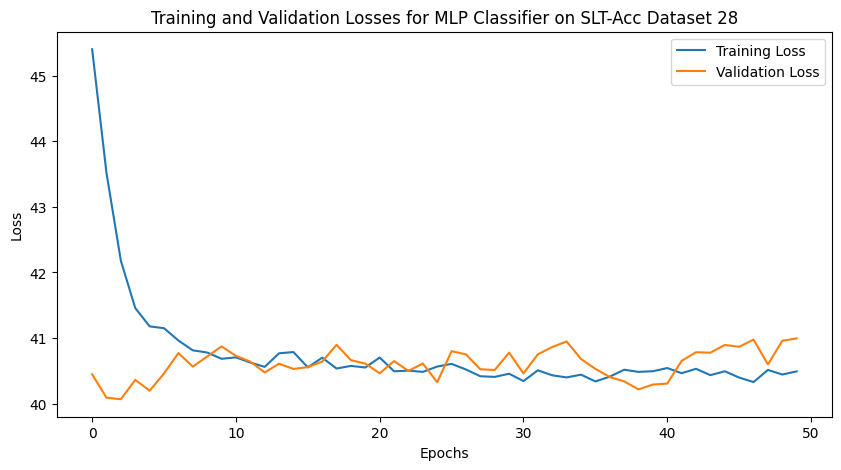

Test Loss: 37.1694, Test Accuracy: 0.6550, AUROC: 0.7414
Training on SLT-Acc Dataset 29/32
Epoch 1/50, Training Loss: 45.2776, Validation Loss: 40.0741, Training Accuracy: 0.6250
Epoch 10/50, Training Loss: 40.8328, Validation Loss: 40.4105, Training Accuracy: 0.9500
Epoch 20/50, Training Loss: 40.4854, Validation Loss: 40.7032, Training Accuracy: 0.9688
Epoch 30/50, Training Loss: 40.4739, Validation Loss: 40.8512, Training Accuracy: 0.9785
Epoch 40/50, Training Loss: 40.4290, Validation Loss: 40.5831, Training Accuracy: 0.9771
Epoch 50/50, Training Loss: 40.3672, Validation Loss: 40.5533, Training Accuracy: 0.9785


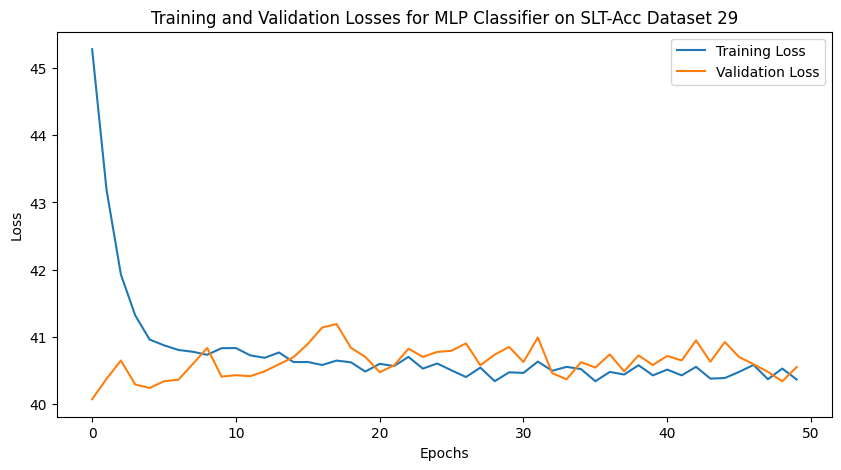

Test Loss: 36.9429, Test Accuracy: 0.6800, AUROC: 0.7408
Training on SLT-Acc Dataset 30/32
Epoch 1/50, Training Loss: 45.3498, Validation Loss: 40.2951, Training Accuracy: 0.6056
Epoch 10/50, Training Loss: 40.6639, Validation Loss: 40.4669, Training Accuracy: 0.9611
Epoch 20/50, Training Loss: 40.5659, Validation Loss: 40.6178, Training Accuracy: 0.9688
Epoch 30/50, Training Loss: 40.5223, Validation Loss: 40.8080, Training Accuracy: 0.9736
Epoch 40/50, Training Loss: 40.3242, Validation Loss: 40.6449, Training Accuracy: 0.9826
Epoch 50/50, Training Loss: 40.3117, Validation Loss: 40.8205, Training Accuracy: 0.9806


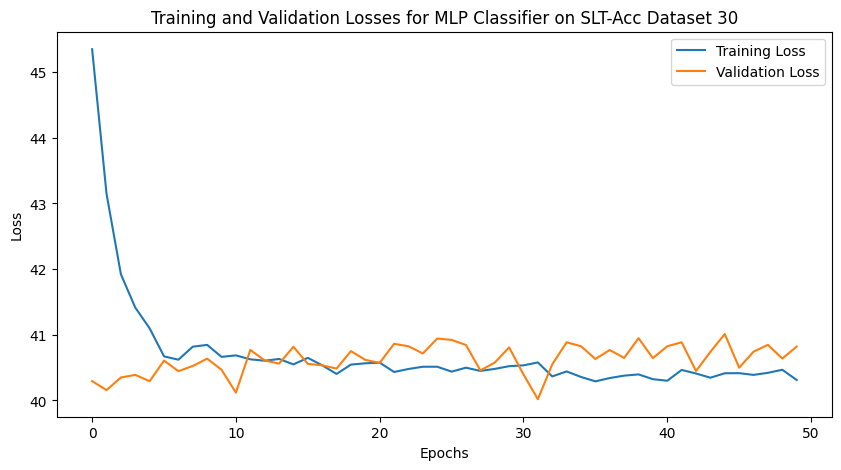

Test Loss: 36.9938, Test Accuracy: 0.6550, AUROC: 0.7276
Training on SLT-Acc Dataset 31/32
Epoch 1/50, Training Loss: 45.1417, Validation Loss: 40.0211, Training Accuracy: 0.6139
Epoch 10/50, Training Loss: 40.5996, Validation Loss: 40.0994, Training Accuracy: 0.9653
Epoch 20/50, Training Loss: 40.5491, Validation Loss: 40.6582, Training Accuracy: 0.9694
Epoch 30/50, Training Loss: 40.3577, Validation Loss: 40.3939, Training Accuracy: 0.9799
Epoch 40/50, Training Loss: 40.4112, Validation Loss: 40.4595, Training Accuracy: 0.9771
Epoch 50/50, Training Loss: 40.3236, Validation Loss: 40.6980, Training Accuracy: 0.9840


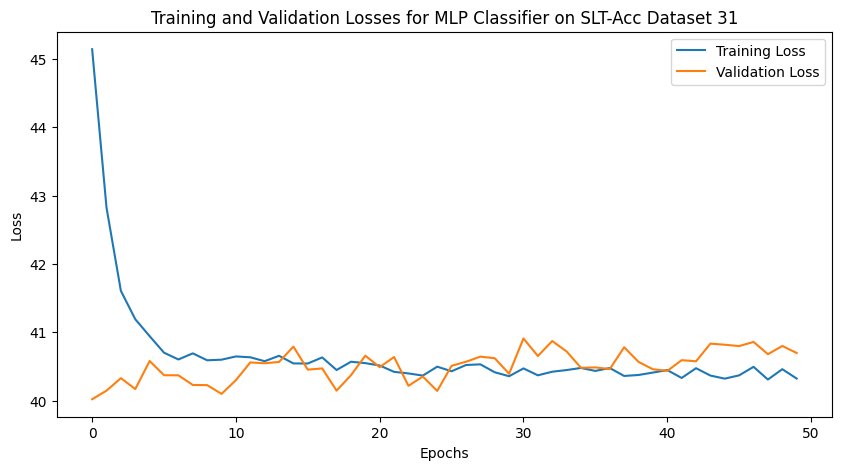

Test Loss: 37.2739, Test Accuracy: 0.6450, AUROC: 0.7248
Training on SLT-Acc Dataset 32/32
Epoch 1/50, Training Loss: 45.1339, Validation Loss: 40.2442, Training Accuracy: 0.6382
Epoch 10/50, Training Loss: 40.7268, Validation Loss: 40.1901, Training Accuracy: 0.9556
Epoch 20/50, Training Loss: 40.5195, Validation Loss: 40.6736, Training Accuracy: 0.9729
Epoch 30/50, Training Loss: 40.3013, Validation Loss: 40.3150, Training Accuracy: 0.9833
Epoch 40/50, Training Loss: 40.3086, Validation Loss: 40.7358, Training Accuracy: 0.9840
Epoch 50/50, Training Loss: 40.3736, Validation Loss: 40.6570, Training Accuracy: 0.9785


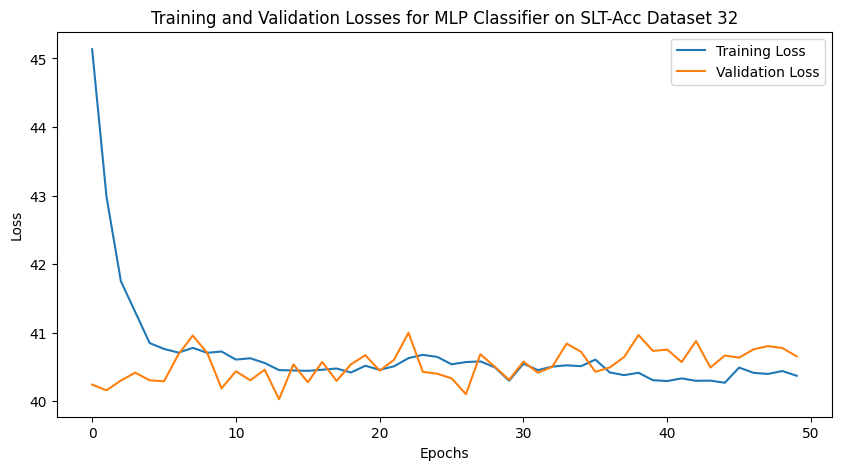

Test Loss: 36.7933, Test Accuracy: 0.6800, AUROC: 0.7598


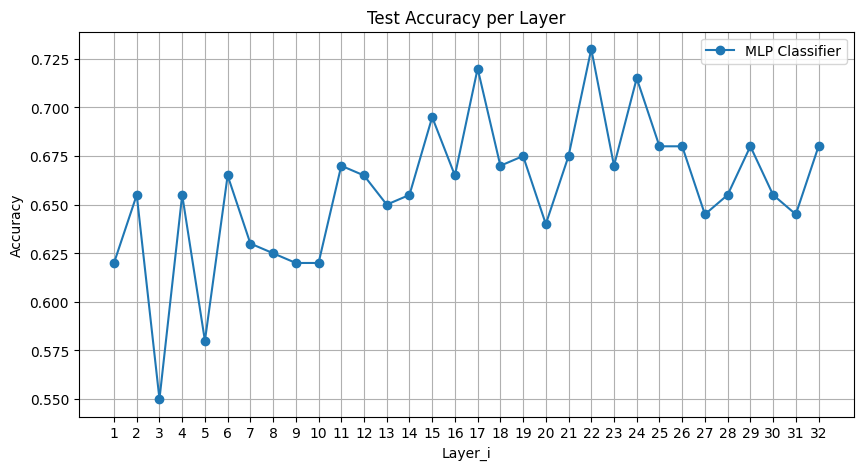

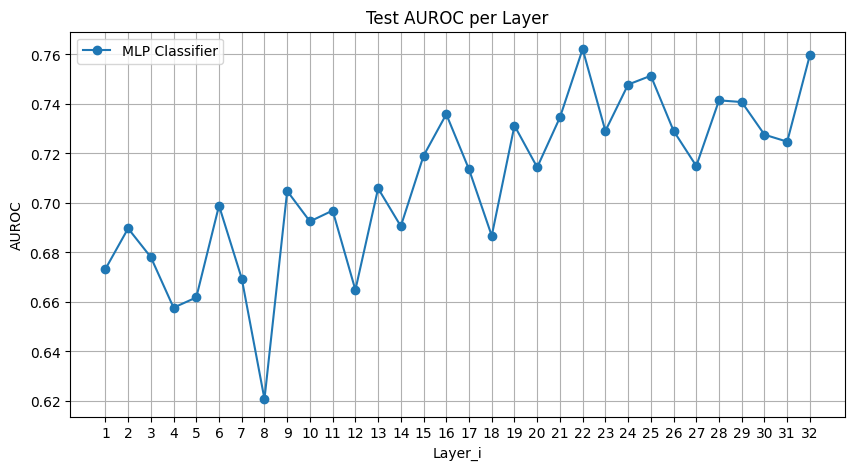

In [466]:
# Training with MLP.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50
samlp_test_accs = []
samlp_test_aucs = []

for i, (train_loader, valid_loader, test_loader) in enumerate(zip(slt_train_dataloaders, slt_valid_dataloaders, slt_test_dataloaders)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(slt_train_dataloaders)}")
    model = MLPClassifier(in_dim, hid_dims, dropout)
    train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on SLT-Acc Dataset {i+1}", silent=False)
    test_loss, test_acc, test_auc = evaluate_on_test(model, test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    samlp_test_accs.append(test_acc)
    samlp_test_aucs.append(test_auc)

plot_1d_metrics([samlp_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([samlp_test_aucs], ['MLP Classifier'], 'AUROC')

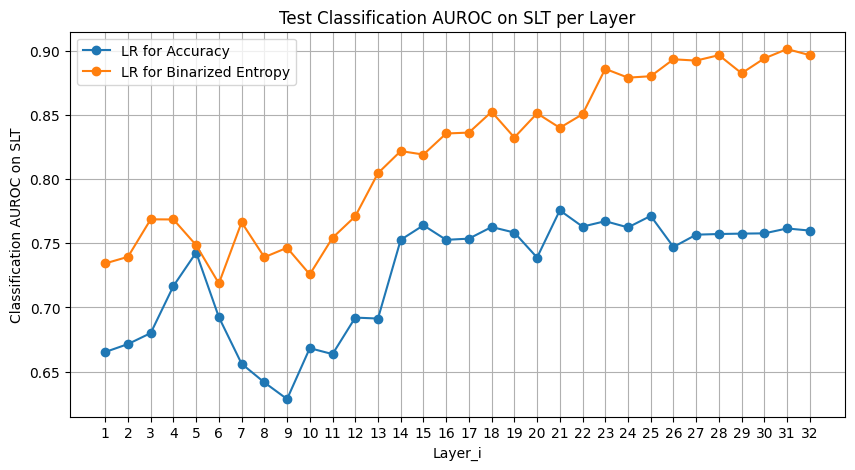

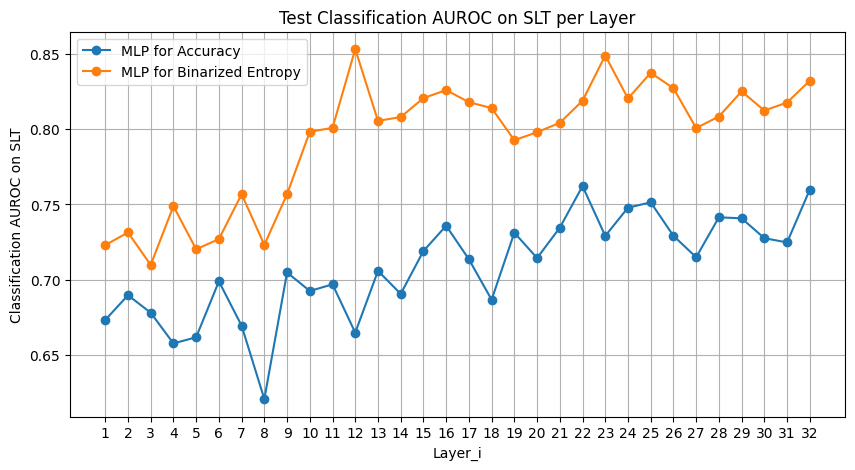

In [467]:
plot_1d_metrics([salr_test_aucs, sblr_test_aucs], ['LR for Accuracy','LR for Binarized Entropy'],
                'Classification AUROC on SLT',
                save_fig=True)

plot_1d_metrics([samlp_test_aucs, sbmlp_test_aucs], ['MLP for Accuracy','MLP for Binarized Entropy'],
                'Classification AUROC on SLT',
                save_fig=True)

Although We can see clear alignment of metric curves for the same model type on binary SE and accuracy scores, the curves have **consistent gap** across layers between performances for binary SE and accuracy scores, and usually those for binary SE's are better.

In [468]:
# Test correlation between binary SE and accuracy
from scipy.stats import pearsonr
correlation, p_value = pearsonr(bca_entropy.tolist(), accuracies.tolist())

print(f'Correlation: {correlation}')
print(f'p-value: {p_value}')

Correlation: -0.45456858843497516
p-value: 1.472429833930329e-102


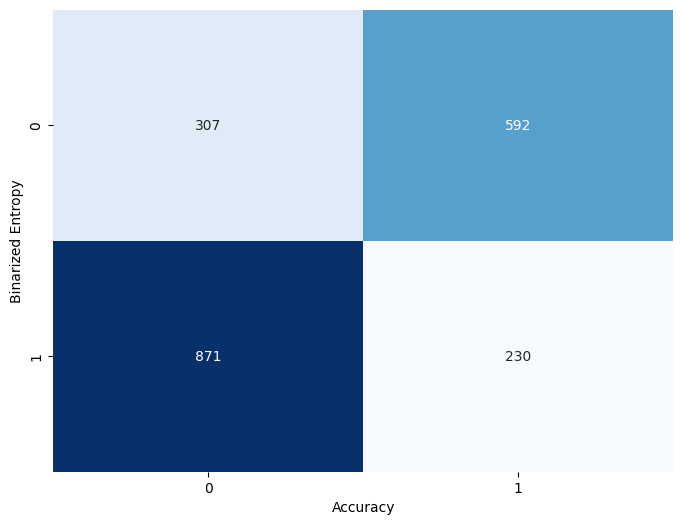

In [469]:
# Create a scatter plot of the binary SE against accuracies
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(bca_entropy.tolist(), accuracies.tolist())

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False)
# plt.title('Confusion Matrix')
plt.ylabel('Binarized Entropy')
plt.xlabel('Accuracy')
plt.show()

## Use Classifier for Binary SE for Predicting LLM Accuracy

We want to show that models trained on binary SE are more generalizable to new LLMs or new datasets when predicting their generation correctness.

We will first test this idea on TBG embeddings.

In [471]:
# Train LR with TBG embeddings for binary SE.
tbg_train_dataloaders, tbg_valid_dataloaders, _ = create_dataloaders(tok_bef_gen_layered_datasets, bca_entropy, total_size, batch_size, set_seed=True)
# Test with accuracy test set (with the same random seed to ensure no data leakage)
# We should reverse the accuracy due to negative R.
r_accuracies = 1 - accuracies
_, _, tbg_test_dataloaders = create_dataloaders(tok_bef_gen_layered_datasets, r_accuracies, total_size, batch_size, set_seed=True)

X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, r_accuracies, total_size)

Training on TBG Dataset 1/33
Validation Accuracy: 0.5778, AUROC: 0.6430
Training Loss: 0.4256, Validation Loss: 0.6639
Test Loss: 0.7192, Test Accuracy: 0.6150, AUROC: 0.6366
Training on TBG Dataset 2/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6472, AUROC: 0.6899
Training Loss: 0.2395, Validation Loss: 0.9775
Test Loss: 1.3096, Test Accuracy: 0.6150, AUROC: 0.6457
Training on TBG Dataset 3/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6194, AUROC: 0.6821
Training Loss: 0.2172, Validation Loss: 1.0246
Test Loss: 1.4315, Test Accuracy: 0.6250, AUROC: 0.6461
Training on TBG Dataset 4/33


...

Validation Accuracy: 0.7111, AUROC: 0.7879
Training Loss: 0.0053, Validation Loss: 1.4614
Test Loss: 2.3383, Test Accuracy: 0.6550, AUROC: 0.7011
Training on TBG Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7139, AUROC: 0.7748
Training Loss: 0.0053, Validation Loss: 1.5716
Test Loss: 2.4958, Test Accuracy: 0.6350, AUROC: 0.6912
Training on TBG Dataset 33/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7222, AUROC: 0.7727
Training Loss: 0.0132, Validation Loss: 1.3148
Test Loss: 2.1311, Test Accuracy: 0.6150, AUROC: 0.6728


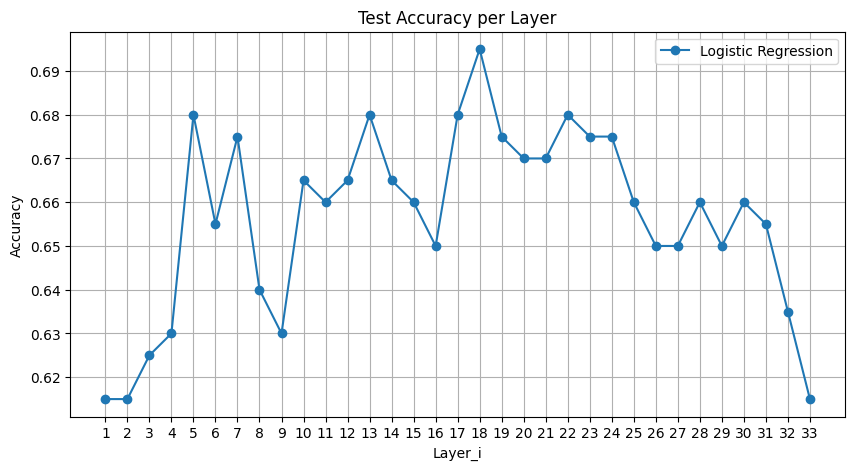

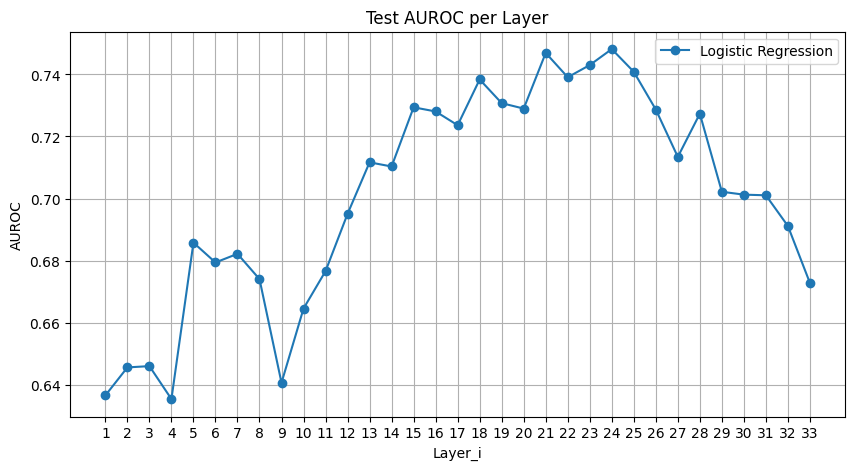

In [473]:
# Training Loops (LR)
tablr_test_accs = []
tablr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tablr_test_accs.append(test_acc)
    tablr_test_aucs.append(test_auc)

plot_1d_metrics([tablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tablr_test_aucs], ['Logistic Regression'], 'AUROC')

In [485]:
# Max AUROC achieved by 'transfer learning' compared to normal training
print(f"TBG: AUROC for LR trained on Binary SE, tested on Accuracy: {max(tablr_test_aucs):.4f}")
print(f"TBG: AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f}")
print(f"TBG: AUROC for LR trained on Binary SE, tested on Binary SE: {max(tblr_test_aucs):.4f}")

TBG: AUROC for LR trained on Binary SE, tested on Accuracy: 0.7481
TBG: AUROC for LR trained on Accuracy, tested on Accuracy: 0.7975
TBG: AUROC for LR trained on Binary SE, tested on Binary SE: 0.8729


Using device: cuda
Training on TBG Dataset 1/33
Epoch 1/50, Training Loss: 60.0402, Validation Loss: 55.0204, Training Accuracy: 0.5681
Epoch 10/50, Training Loss: 57.7237, Validation Loss: 54.9663, Training Accuracy: 0.7604
Epoch 20/50, Training Loss: 57.6136, Validation Loss: 55.3085, Training Accuracy: 0.7646
Epoch 30/50, Training Loss: 57.4438, Validation Loss: 55.4952, Training Accuracy: 0.7847
Epoch 40/50, Training Loss: 57.5499, Validation Loss: 55.3227, Training Accuracy: 0.7583
Epoch 50/50, Training Loss: 57.5039, Validation Loss: 55.1765, Training Accuracy: 0.7639
Test Loss: 54.4848, Test Accuracy: 0.6000, AUROC: 0.6008
Training on TBG Dataset 2/33
Epoch 1/50, Training Loss: 59.8117, Validation Loss: 54.8609, Training Accuracy: 0.6118
Epoch 10/50, Training Loss: 57.5220, Validation Loss: 55.2092, Training Accuracy: 0.7889
Epoch 20/50, Training Loss: 57.2119, Validation Loss: 55.1060, Training Accuracy: 0.8139
Epoch 30/50, Training Loss: 57.1043, Validation Loss: 54.9937, Trai

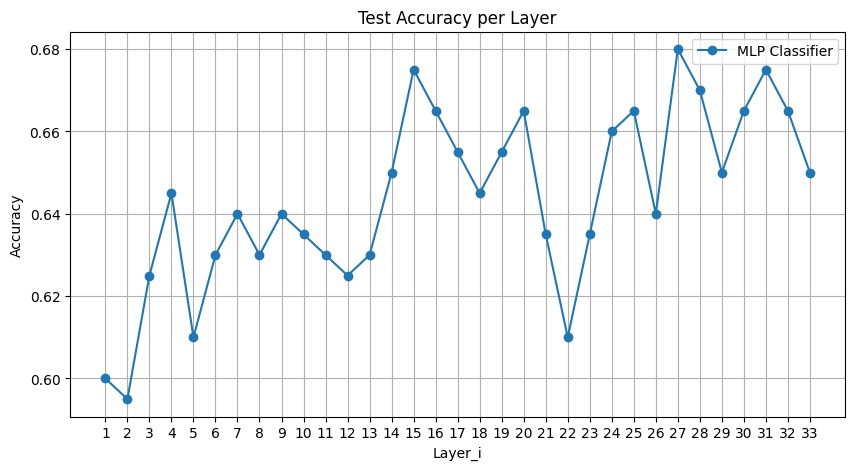

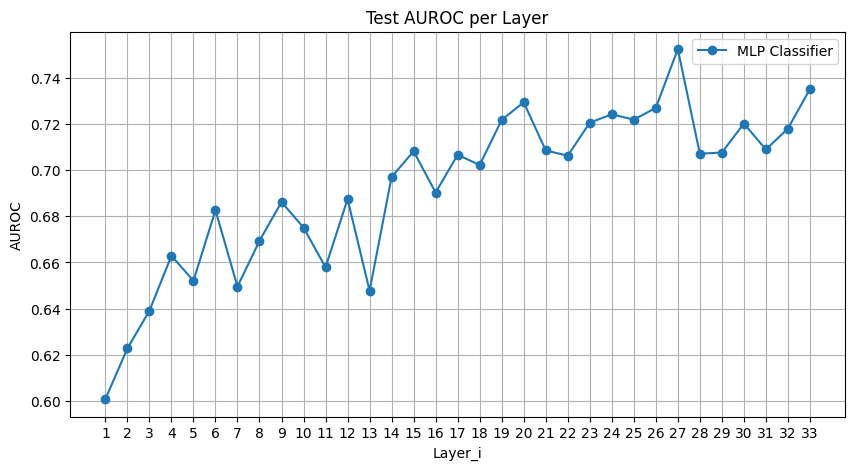

In [478]:
# Training Loops (MLP)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50
tabmlp_test_accs = []
tabmlp_test_aucs = []

for i, (train_loader, valid_loader, test_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders)):
    print(f"Training on TBG Dataset {i+1}/{len(tbg_train_dataloaders)}")
    tab_model = MLPClassifier(in_dim, hid_dims, dropout)
    train_and_evaluate(tab_model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on TBG Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(tab_model, test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tabmlp_test_accs.append(test_acc)
    tabmlp_test_aucs.append(test_auc)

plot_1d_metrics([tabmlp_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([tabmlp_test_aucs], ['MLP Classifier'], 'AUROC')

In [486]:
# Max AUROC achieved by 'transfer testing' compared to normal testing
print(f"TBG: AUROC for MLP trained on Binary SE, tested on Accuracy: {max(tabmlp_test_aucs):.4f}")
print(f"TBG: AUROC for MLP trained on Accuracy, tested on Accuracy: {max(tamlp_test_aucs):.4f}")
print(f"TBG: AUROC for MLP trained on Binary SE, tested on Binary SE: {max(tbmlp_test_aucs):.4f}")

TBG: AUROC for MLP trained on Binary SE, tested on Accuracy: 0.7524
TBG: AUROC for MLP trained on Accuracy, tested on Accuracy: 0.8069
TBG: AUROC for MLP trained on Binary SE, tested on Binary SE: 0.8282


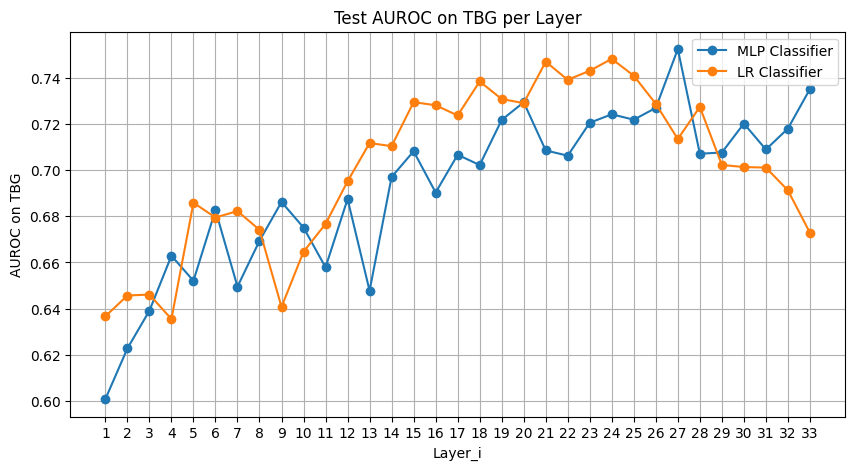

In [491]:
# plot_1d_metrics([tabmlp_test_accs, tablr_test_accs], ['MLP Classifier','LR Classifier'], 'Accuracy')
plot_1d_metrics([tabmlp_test_aucs, tablr_test_aucs], ['MLP Classifier','LR Classifier'], 'AUROC on TBG')

Now we test on SLT embeddings.

In [481]:
slt_train_dataloaders, slt_valid_dataloaders, _ = create_dataloaders(slt_layered_datasets, bca_entropy, total_size, batch_size, set_seed=True)
_, _, slt_test_dataloaders = create_dataloaders(slt_layered_datasets, r_accuracies, total_size, batch_size, set_seed=True)

X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(slt_layered_datasets, r_accuracies, total_size)

Training on SLT Dataset 1/32
Validation Accuracy: 0.6583, AUROC: 0.6963
Training Loss: 0.5433, Validation Loss: 0.6316
Test Loss: 0.6653, Test Accuracy: 0.6300, AUROC: 0.6355
Training on SLT Dataset 2/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6361, AUROC: 0.6910
Training Loss: 0.5057, Validation Loss: 0.6310
Test Loss: 0.6657, Test Accuracy: 0.6250, AUROC: 0.6388
Training on SLT Dataset 3/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6528, AUROC: 0.6751
Training Loss: 0.4349, Validation Loss: 0.6574
Test Loss: 0.6581, Test Accuracy: 0.6500, AUROC: 0.6628
Training on SLT Dataset 4/32


...

Validation Accuracy: 0.6972, AUROC: 0.7807
Training Loss: 0.0062, Validation Loss: 1.6030
Test Loss: 2.1261, Test Accuracy: 0.6700, AUROC: 0.7326
Training on SLT Dataset 31/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7194, AUROC: 0.7833
Training Loss: 0.0063, Validation Loss: 1.5212
Test Loss: 2.0681, Test Accuracy: 0.6750, AUROC: 0.7250
Training on SLT Dataset 32/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7139, AUROC: 0.7845
Training Loss: 0.0107, Validation Loss: 1.2852
Test Loss: 1.7496, Test Accuracy: 0.6700, AUROC: 0.7186


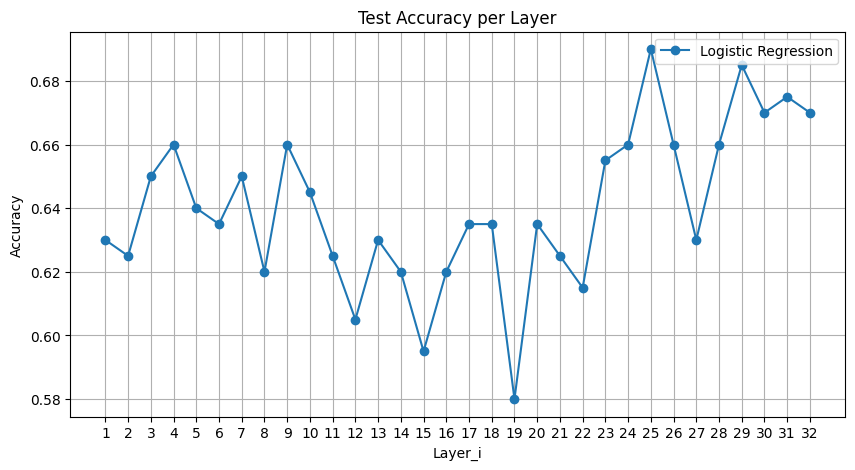

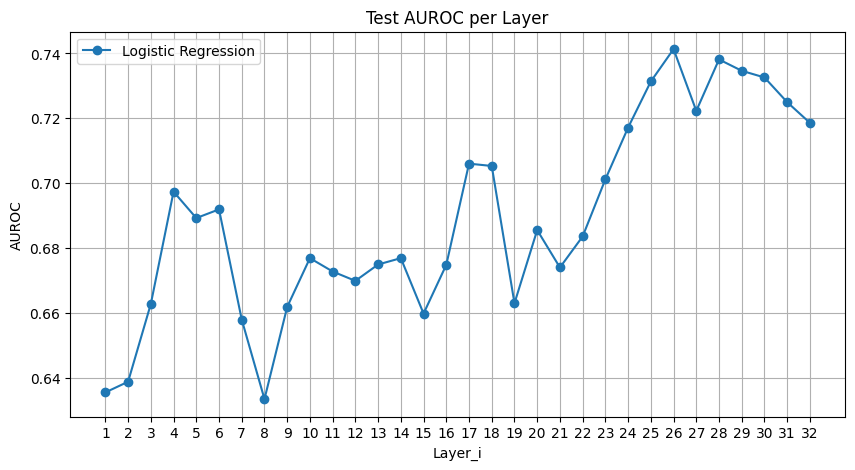

In [482]:
# Training Loops (LR)
sablr_test_accs = []
sablr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sablr_test_accs.append(test_acc)
    sablr_test_aucs.append(test_auc)

plot_1d_metrics([sablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([sablr_test_aucs], ['Logistic Regression'], 'AUROC')

In [484]:
# Max AUROC achieved by 'transfer learning' compared to normal training
print(f"SLT: AUROC for LR trained on Binary SE, tested on Accuracy: {max(sablr_test_aucs):.4f}")
print(f"SLT: AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f}")
print(f"SLT: AUROC for LR trained on Binary SE, tested on Binary SE: {max(sblr_test_aucs):.4f}")

SLT: AUROC for LR trained on Binary SE, tested on Accuracy: 0.7413
SLT: AUROC for LR trained on Accuracy, tested on Accuracy: 0.7756
SLT: AUROC for LR trained on Binary SE, tested on Binary SE: 0.9012


Using device: cuda
Training on SLT Dataset 1/32
Epoch 1/50, Training Loss: 59.9351, Validation Loss: 55.3883, Training Accuracy: 0.6035
Epoch 10/50, Training Loss: 57.6693, Validation Loss: 55.3133, Training Accuracy: 0.7854
Epoch 20/50, Training Loss: 56.7876, Validation Loss: 54.7746, Training Accuracy: 0.8438
Epoch 30/50, Training Loss: 56.3007, Validation Loss: 54.9040, Training Accuracy: 0.8812
Epoch 40/50, Training Loss: 56.1061, Validation Loss: 55.8607, Training Accuracy: 0.8944
Epoch 50/50, Training Loss: 56.0305, Validation Loss: 55.1903, Training Accuracy: 0.8986
Test Loss: 54.5215, Test Accuracy: 0.6150, AUROC: 0.6511
Training on SLT Dataset 2/32
Epoch 1/50, Training Loss: 60.1313, Validation Loss: 55.5286, Training Accuracy: 0.5687
Epoch 10/50, Training Loss: 57.6051, Validation Loss: 55.5940, Training Accuracy: 0.7958
Epoch 20/50, Training Loss: 56.8360, Validation Loss: 55.1413, Training Accuracy: 0.8368
Epoch 30/50, Training Loss: 56.2315, Validation Loss: 55.9985, Trai

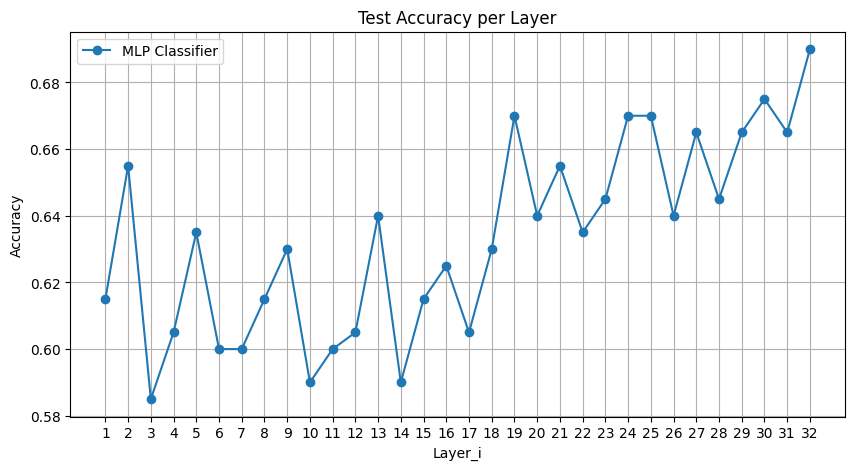

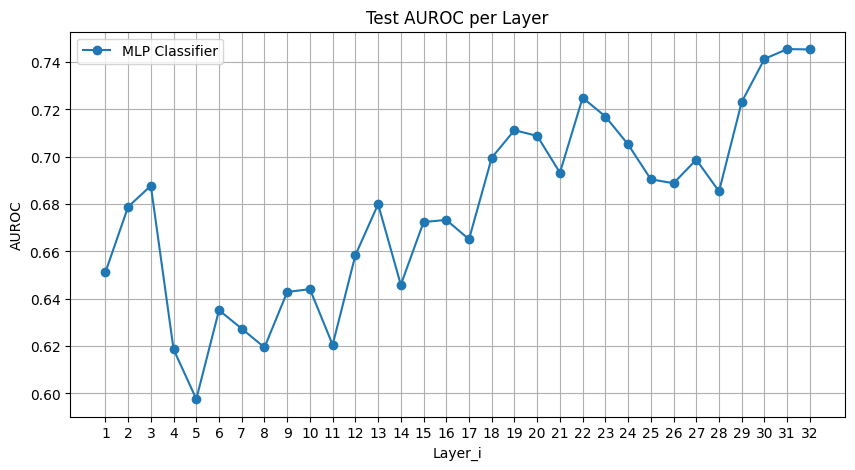

In [487]:
# Training Loops (MLP)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50
sabmlp_test_accs = []
sabmlp_test_aucs = []

for i, (train_loader, valid_loader, test_loader) in enumerate(zip(slt_train_dataloaders, slt_valid_dataloaders, slt_test_dataloaders)):
    print(f"Training on SLT Dataset {i+1}/{len(slt_train_dataloaders)}")
    tab_model = MLPClassifier(in_dim, hid_dims, dropout)
    train_and_evaluate(tab_model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on SLT Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(tab_model, test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    sabmlp_test_accs.append(test_acc)
    sabmlp_test_aucs.append(test_auc)

plot_1d_metrics([sabmlp_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([sabmlp_test_aucs], ['MLP Classifier'], 'AUROC')

In [488]:
# Max AUROC achieved by 'transfer learning' compared to normal training
print(f"SLT: AUROC for MLP trained on Binary SE, tested on Accuracy: {max(sabmlp_test_aucs):.4f}")
print(f"SLT: AUROC for MLP trained on Accuracy, tested on Accuracy: {max(samlp_test_aucs):.4f}")
print(f"SLT: AUROC for MLP trained on Binary SE, tested on Binary SE: {max(sbmlp_test_aucs):.4f}")

SLT: AUROC for MLP trained on Binary SE, tested on Accuracy: 0.7455
SLT: AUROC for MLP trained on Accuracy, tested on Accuracy: 0.7622
SLT: AUROC for MLP trained on Binary SE, tested on Binary SE: 0.8531


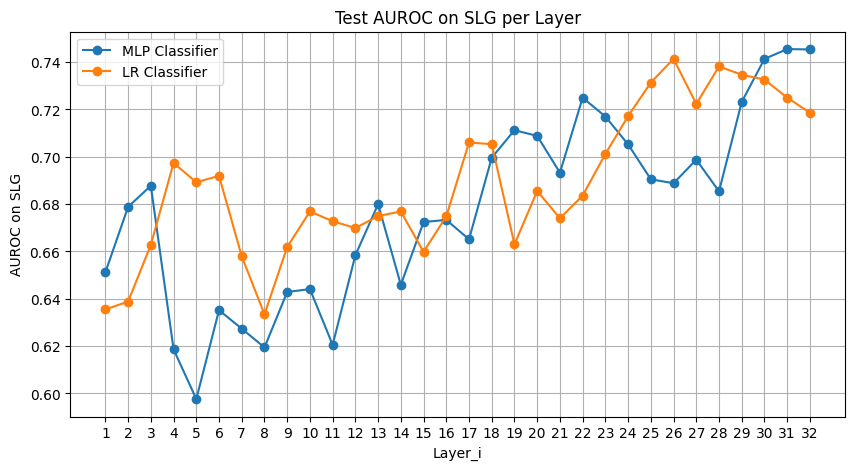

In [490]:
# plot_1d_metrics([sabmlp_test_accs, sablr_test_accs], ['MLP Classifier','LR Classifier'], 'Accuracy on SLG')
plot_1d_metrics([sabmlp_test_aucs, sablr_test_aucs], ['MLP Classifier','LR Classifier'], 'AUROC on SLG')